In [11]:
# ==============================================================================
# 시스템명: 전 수계 통합 오염원인 자동 스크리닝 및 자기 최적화 시스템 
# 연구목적: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
# 주요업데이트: 
#   1. Variational Autoencoder(VAE) 도입으로 잠재공간(Latent Space) 기하학적 응집도 극대화
#   2. CINN(Chemistry-Informed) 도메인 손실 함수 적용 (물리/화학적 질량보존 제약조건 반영)
#   3. 복합 앙상블 평가지표(Consensus Score = Silhouette + DBI + CHI) 기반 K-선택 자동화
#   4. Fallback 로직이 대폭 강화된 범용적 오염원 판별 엔진 및 시각화 결과물 자동 저장
# ============================================================================== 

# ------------------------------------------------------------------------------
# 0. 환경 구축 및 패키지 임포트 
# ------------------------------------------------------------------------------
!pip install torch pandas numpy scikit-learn matplotlib adjustText seaborn hdbscan

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import torch
import torch.nn as nn
import hdbscan
import warnings
import datetime
import random
import math
import shap
import os
import warnings
import traceback

from scipy.stats import norm, linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics.pairwise import pairwise_distances
from adjustText import adjust_text

In [13]:
# 환경 설정 및 재현성 확보
warnings.filterwarnings('ignore')
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
available = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = next((c for c in candidates if c in available), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

SEED = 3606
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)            # GPU 사용 시
torch.backends.cudnn.deterministic = True   # CUDA 비결정성 차단
torch.backends.cudnn.benchmark = False

In [14]:
# 시각화 결과를 저장할 디렉토리 생성
out_dir = "Screening_Results"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")

In [15]:
# ------------------------------------------------------------------------------
# 1. 데이터 전처리 (Data Pre-processing)
# 방법론: ROS (Regression on Order Statistics) & KNN Imputation & Z-score Normalization
# 설명: 수질 및 환경 데이터의 결측치(NA)는 대부분 기기 검출한계 미만(LOD)인 
#       '좌측 절단 데이터(Left-Censored Data)'의 특성을 가집니다. 
#       단순 평균이나 KNN만 선행 적용할 경우 하위 분포의 통계적 왜곡이 발생할 수 있으므로,
#       R의 NADA 패키지 로직을 차용하여 ROS 기법을 1차적으로 적용합니다.
#       데이터 다양성 부족이나 통계적 에러 발생 시 다차원 특성을 보존하는 KNN으로 안전하게 우회합니다.
# ------------------------------------------------------------------------------
print("[*] 1단계: 데이터 로드 및 5대 핵심 파생 변수 생성 진행 중...")
df = pd.read_csv('C:/Users/User/Desktop/연구지점 데이터 정리/3월 2주차.csv', encoding='euc-kr') 

# [안전장치] 연산 에러를 방지하기 위해 계산에 사용될 주요 컬럼들을 먼저 숫자형으로 안전하게 변환
calc_cols = ['TN', 'TP', 'TOC', 'Cl', 'd15N', 'd18O', 'NH3N', 'NO3N']
for col in calc_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ==============================================================================
# [고도화 반영] 수질 오염원 정밀 스크리닝을 위한 5대 파생 변수 사전 생성 
# ==============================================================================
df['TN/TP']       = df['TN'] / df['TP']
df['TOC/TN']      = df['TOC'] / df['TN']
df['Cl/TN']       = df['Cl'] / df['TN']
df['d15N/d18O']   = df['d15N'] / df['d18O']
df['NH3N/NO3N']   = df['NH3N'] / df['NO3N']
df['NO3N/Cl']     = df['NO3N'] / df['Cl']

# [필수 에러 방어] 분모가 0이거나 결측치 연산으로 인해 발생한 무한대(inf) 값을 NaN으로 일괄 대체
# 이렇게 해야 뒤이은 KNN Imputer가 결측치로 인식하여 깔끔하게 통계적 대치를 수행합니다.
import numpy as np
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 'spot' 변수를 제외하고 분석에 활용할 수질 피처만 분리 (원본 22개 + 파생 5개 = 총 27개)
features_df = df.drop(columns=['spot'])

# [에러 방어 2] 전체 데이터를 강제로 숫자형(Numeric)으로 최종 변환 (변환 불가 시 NaN 처리)
features_df = features_df.apply(pd.to_numeric, errors='coerce')

print(f" -> 파생 변수 생성 완료! 분석 대상 수질 인자 수: {features_df.shape[1]}개")

# ---------------------------------------------------------
# [함수 정의] 로버스트 결측치 처리 (ROS -> KNN Fallback)
# ---------------------------------------------------------
def robust_imputation(dataframe, n_neighbors=5):
    df_imp = dataframe.copy()
    
    for col in df_imp.columns:
        if df_imp[col].isna().any():
            # 관측된 유효 데이터(obs)와 결측치 개수(n_cen) 파악
            obs = df_imp[col].dropna().values
            n_total = len(df_imp[col])
            n_obs = len(obs)
            n_cen = n_total - n_obs
            
            try:
                # 1) R NADA 로직: 유효 관측치가 3개 이하이거나 전면 결측일 경우 통계 적합이 불가하므로 예외 발생 (KNN 우회)
                if n_obs <= 3 or len(np.unique(obs)) <= 3 or n_cen == 0:
                    raise ValueError("데이터 다양성 부족")
                
                # 2) 관측값 오름차순 정렬 및 0 이하 값에 대한 안전한 로그 변환 (수질 데이터는 로그정규분포 가정)
                obs_sorted = np.sort(obs)
                obs_safe = np.where(obs_sorted <= 0, 1e-6, obs_sorted) 
                log_obs = np.log(obs_safe)
                
                # 3) Plotting Position(플로팅 포지션) 및 정규 분위수(Z-score) 계산
                ranks_obs = np.arange(n_cen + 1, n_total + 1)
                p_obs = ranks_obs / (n_total + 1)
                z_obs = norm.ppf(p_obs)
                
                # 4) 선형 회귀 적합 (Z-score vs Log(Observed))
                slope, intercept, r_value, p_value, std_err = linregress(z_obs, log_obs)
                
                # 5) 결측치(검출한계 미만) 영역의 Z-score 계산 및 회귀식 기반 로그 값 추정 -> 지수 변환으로 복원
                ranks_cen = np.arange(1, n_cen + 1)
                p_cen = ranks_cen / (n_total + 1)
                z_cen = norm.ppf(p_cen)
                
                log_cen_est = intercept + slope * z_cen
                cen_est = np.exp(log_cen_est)
                
                # 6) 검출한계(LOD) 캡핑 방어: 추정값이 관측된 최소값(LOD 추정치)의 99%를 초과하지 않도록 강제
                lod = np.min(obs_sorted) * 0.99
                cen_est = np.clip(cen_est, a_min=1e-6, a_max=lod)
                
                # 7) 데이터프레임 내 할당: 값들이 오름차순 정렬되어 있으므로 무작위로 섞어 순서 편향(Bias) 방지
                np.random.seed(3606)  # 프레임워크 전역 SEED와 동일하게 고정
                np.random.shuffle(cen_est)
                df_imp.loc[df_imp[col].isna(), col] = cen_est
                
            except Exception as e:
                # ROS 수행 불가 변수는 에러를 내지 않고 pass하여 아래의 KNN Imputer에서 일괄 처리
                pass

    # ---------------------------------------------------------
    # [Fallback] 잔여 결측치에 대한 다차원 KNN Imputation 적용
    # ---------------------------------------------------------
    if df_imp.isna().any().any():
        knn_imputer = KNNImputer(n_neighbors=n_neighbors)
        imputed_array = knn_imputer.fit_transform(df_imp)
        df_imp = pd.DataFrame(imputed_array, columns=df_imp.columns)
        
    return df_imp

# 로버스트 결측치 처리 함수 실행
imputed_df = robust_imputation(features_df, n_neighbors=5)

# [에러 방어 2] 후속 셀(Decision Tree 및 Random Forest 학습 등)에서 사용하는 Numpy Array 변수명 명시적 복원
imputed_data = imputed_df.values

# 스케일 정규화 (Standard Scaling)
# [방법론] 변수 스케일의 차이(예: EC vs d15N)가 신경망 학습 및 거리 계산을 왜곡하지 않도록 (평균 0, 표준편차 1) 변환
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)
# ------------------------------------------------------------------------------

[*] 1단계: 데이터 로드 및 5대 핵심 파생 변수 생성 진행 중...
 -> 파생 변수 생성 완료! 분석 대상 수질 인자 수: 28개


In [16]:
# ------------------------------------------------------------------------------
# 2. 비선형 특징 추출: CINN 기반 Variational Autoencoder (VAE)
# ------------------------------------------------------------------------------
# 방법론: Undercomplete Autoencoder (AE)
# 설명: 수질 변수와 동위원소 데이터는 선형적이지 않은 복잡한 상호작용(예: 화학적 침전, 미생물 분해)을 
#       가집니다. 전통적인 선형 차원축소 기법인 PCA(주성분 분석)의 한계를 극복하기 위해, 
#       인공신경망 기반의 오토인코더를 사용하여 핵심적인 비선형 잠재 특징(Latent Features)을 추출합니다.
# 참고문헌:
# - Hinton, G. E., & Salakhutdinov, R. R. (2006). "Reducing the dimensionality of data with neural networks." Science, 313(5786), 504-507. (Autoencoder를 활용한 비선형 차원축소의 기초)
# ------------------------------------------------------------------------------
# [방법론 및 설명]
# 일반 Autoencoder를 VAE로 전환하여, 잠재 공간(Latent Space)이 가우시안 분포를 
# 따르도록 강제함으로써 소표본 환경에서 군집의 기하학적 응집도를 비약적으로 향상시킵니다.
# 또한 CINN(Chemistry-Informed Neural Network) 개념을 도입하여, 데이터를 재구성할 때 
# "총질소(TN) >= 질산성질소(NO3-N) + 암모니아성질소(NH3-N)" 라는 화학적 질량 보존 
# 법칙을 위배하면 손실 함수에 강력한 Penalty(위약금)를 부과합니다.
# ------------------------------------------------------------------------------
class ChemistryInformedVAE(nn.Module):
    def __init__(self, input_dim):
        super(ChemistryInformedVAE, self).__init__()

        # 1. 은닉층 단순화 (Deep -> Shallow 구조 변경)
        # 소표본 데이터(N=10 내외)에서는 파라미터 수가 너무 많으면 데이터를 통째로 외워버립니다.
        # 기존 [input -> 16 -> 8 -> 3] 구조를 [input -> 6 -> 3] 구조로 대폭 슬림화하여 모델의 표현 용량을 제한합니다.
        
        # 2. 드롭아웃(Dropout) 도입
        # 특정 수질 인자나 동위원소 값 하나에 모델이 과도하게 의존(Co-adaptation)하는 것을 방지합니다.
        # 학습 시 무작위로 20%의 노드를 끔으로써 변수 간의 균형 있는 관계를 학습하게 합니다.
        
        # 인코더: [Input -> 6 -> 3(mu) & 3(logvar)] 슬림화 구조 + Dropout 유지
        self.fc1 = nn.Linear(input_dim, 6)
        self.dropout = nn.Dropout(p=0.2)
        self.fc_mu = nn.Linear(6, 3)
        self.fc_logvar = nn.Linear(6, 3)
        
        # 디코더: 대칭 구조
        self.decoder = nn.Sequential(
            nn.Linear(3, 6),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(6, input_dim)
        )

    def encode(self, x):
        h1 = self.dropout(torch.relu(self.fc1(x)))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        # 잠재 공간의 연속성을 만드는 Reparameterization Trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return z, self.decode(z), mu, logvar

# 물리화학적 법칙(CINN) 제어를 위한 인덱스 및 역변환 텐서 추출
tn_idx = features_df.columns.get_loc('TN')
no3_idx = features_df.columns.get_loc('NO3N')
nh3_idx = features_df.columns.get_loc('NH3N')

scaler_mean_tensor = torch.FloatTensor(scaler.mean_)
scaler_scale_tensor = torch.FloatTensor(scaler.scale_)

def cinn_vae_loss(recon_x, x, mu, logvar):
    # 1. 재구성 손실 (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')
    # 2. 쿨백-라이블러 발산 (KLD): 잠재공간 분포 정규화
    kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # 3. 도메인 지식 패널티 (CINN: Domain-Knowledge Guided Loss)
    # 정규화된 출력값을 실제 수치 범위로 복원
    recon_unscaled = recon_x * scaler_scale_tensor + scaler_mean_tensor
    tn_val = recon_unscaled[:, tn_idx]
    no3_val = recon_unscaled[:, no3_idx]
    nh3_val = recon_unscaled[:, nh3_idx]
    
    # 화학법칙 제약: TN >= NO3 + NH3. 이를 위반한 양(Violation)만큼 Penalty 산출
    violation = torch.relu((no3_val + nh3_val) - tn_val)
    penalty = torch.mean(violation) * 0.1 # 페널티 가중치
    
    return recon_loss + kld_loss + penalty

print("[*] 2단계: CINN(도메인 지식 기반) VAE 잠재 공간 임베딩 훈련 중...")
model = ChemistryInformedVAE(input_dim=scaled_data.shape[1])
# L2 규제(weight_decay) 1e-2로 상향하여 과적합 철저히 차단
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-2)

tensor_data = torch.FloatTensor(scaled_data)
epochs = 400 # 슬림한 구조이므로 400회로 수렴 충분

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    z, recon, mu, logvar = model(tensor_data)
    loss = cinn_vae_loss(recon, tensor_data, mu, logvar)
    loss.backward()
    optimizer.step()

# 평가 모드 전환 후, 평균(mu) 벡터를 최종 잠재 공간 좌표로 채택
model.eval() 
with torch.no_grad():
    mu_final, _ = model.encode(tensor_data)
latent_data = mu_final.numpy()

[*] 2단계: CINN(도메인 지식 기반) VAE 잠재 공간 임베딩 훈련 중...


In [17]:
# ------------------------------------------------------------------------------
# 3. 알고리즘 경합형 최적 모델 결정: Consensus Score 도입 (8대 알고리즘 확장 버전)
# 방법론: Multi-Algorithm Ensemble & Silhouette Analysis (8-Way Competition)
# 설명: 수질 데이터의 분포 특성(구형, 밀도 기반 비정형, 계층형, 중심점 기반 등)을 사전에 
#       특정할 수 없으므로, 서로 다른 수학적 메커니즘을 가진 8가지 AI 군집화 알고리즘을 경쟁시킵니다.
#       각 모델별로 Silhouette Score, Calinski-Harabasz Index(CHI), Davies-Bouldin Index(DBI)를 
#       동시에 산출하고 정규화 합산한 'Consensus Score'가 가장 높은 최적의 모델과 군집 수(K)를 자동 채택합니다.
# 
# 경쟁 AI 알고리즘 (8대 기법):
#   1. HDBSCAN: 계층적 밀도 기반 군집화 (노이즈 식별 및 비선형 구조 탁월)
#   2. Spectral Clustering: 그래프 연결성 기반 군집화 (복잡한 매니폴드 구조 해소)
#   3. Birch: 트리 구조 기반 계층 군집화 (대용량 및 연산 효율성 중심)
#   4. GMM (Gaussian Mixture Model): 가우시안 혼합 분포 기반 소프트 클러스터링
#   5. K-means: 거리 기반 중심점(Centroid) 최적화 알고리즘 (대표적인 구형 분포 모델)
#   6. Hierarchical Clustering: 응집형(Bottom-Up) 계층 군집화 (Ward 연결법 기준)
#   7. PAM (Partitioning Around Medoids): 실제 데이터 포인트(Medoid) 중심의 로버스트 군집화 (이상치 강건성)
#   8. DIANA (Divisive Analysis): 분할형(Top-Down) 계층 군집화 (전체 구조에서 세부 구조로 하향식 분할)
# ------------------------------------------------------------------------------

# ------------------------------------------------------------------------------
# [사용자 정의 알고리즘 서브루틴 - 의존성 에러 원천 차단]
# ------------------------------------------------------------------------------

def run_pam(data, k, seed):
    """
    PAM (Partitioning Around Medoids / K-Medoids) 알고리즘 구현체
    설명: K-means와 유사하나, 가상의 중심점 대신 '실제 존재하는 데이터 포인트(Medoid)'를 중심바로 채택하여
          이상치(Outlier) 및 극단적인 수질 변동치에 매우 강건한 특성을 가집니다.
    """
    rng = np.random.default_rng(seed)
    n_samples = data.shape[0]
    if n_samples < k:
        return np.zeros(n_samples, dtype=int)
    
    # 1) 초기 메도이드 무작위 선택
    medoid_indices = rng.choice(n_samples, k, replace=False)
    D = pairwise_distances(data, metric='euclidean')
    
    for _ in range(100):
        # 가장 가까운 메도이드로 군집 할당
        labels = np.argmin(D[:, medoid_indices], axis=1)
        new_medoid_indices = np.copy(medoid_indices)
        
        # 각 군집 내부에서 내적 거리 합을 최소화하는 새로운 메도이드 탐색
        for cluster_id in range(k):
            cluster_mask = (labels == cluster_id)
            if not np.any(cluster_mask):
                continue
            cluster_indices = np.where(cluster_mask)[0]
            # 군집 내부 포인트 간의 거리 행렬 추출
            sub_D = D[cluster_indices[:, None], cluster_indices]
            dist_sums = sub_D.sum(axis=1)
            best_local_idx = np.argmin(dist_sums)
            new_medoid_indices[cluster_id] = cluster_indices[best_local_idx]
            
        # 메도이드 변화가 없으면 수렴으로 판단 후 종료
        if np.array_equal(medoid_indices, new_medoid_indices):
            break
        medoid_indices = new_medoid_indices
        
    return np.argmin(D[:, medoid_indices], axis=1)


def run_diana(data, k):
    """
    DIANA (Divisive Analysis) 알고리즘 구현체
    설명: 전체 데이터를 하나의 거대한 군집으로 시작하여, 군집 내 직경(Diameter)이 가장 큰 군집을 
          하향식(Top-Down)으로 분할해 나가는 계층적 군집화 기법입니다. 데이터의 거시적 경향 파악에 유리합니다.
    """
    n_samples = data.shape[0]
    if n_samples < k:
        return np.zeros(n_samples, dtype=int)
    
    D = pairwise_distances(data, metric='euclidean')
    # 최초에는 모든 인덱스가 하나의 군집에 포함
    clusters = [list(range(n_samples))]
    
    while len(clusters) < k:
        # 1) 직경(최대 분산 거리)이 가장 큰 군집 탐색하여 분할 대상으로 선정
        max_diam = -1
        target_idx = -1
        for idx, cl in enumerate(clusters):
            if len(cl) > 1:
                sub_D = D[np.array(cl)[:, None], np.array(cl)]
                diam = sub_D.max()
                if diam > max_diam:
                    max_diam = diam
                    target_idx = idx
        
        if target_idx == -1:
            break  # 더 이상 분할할 수 없는 경우 break
            
        C = clusters.pop(target_idx)
        
        # 2) 표준 DIANA Splinter Group(분가 군집) 형성 로직
        # 해당 군집 내에서 타 원소들과의 평균 거리가 가장 먼 원소를 분가 군집의 씨앗으로 선택
        sub_D = D[np.array(C)[:, None], np.array(C)]
        avg_dists = sub_D.sum(axis=1) / (len(C) - 1 if len(C) > 1 else 1)
        max_avg_idx = np.argmax(avg_dists)
        
        splinter = [C[max_avg_idx]]
        remaining = [x for i, x in enumerate(C) if i != max_avg_idx]
        
        # Remaining 군집 원소 중 Splinter 군집에 더 가까운 원소들을 순차적으로 이동
        while len(remaining) > 0:
            rem_arr = np.array(remaining)
            spl_arr = np.array(splinter)
            
            if len(remaining) > 1:
                dist_to_rem = D[rem_arr[:, None], rem_arr].sum(axis=1) / (len(remaining) - 1)
            else:
                dist_to_rem = np.zeros(len(remaining))
                
            dist_to_spl = D[rem_arr[:, None], spl_arr].mean(axis=1)
            
            # 남은 그룹 내부 거리와 분가 그룹과의 거리 차이 계산
            diff = dist_to_rem - dist_to_spl
            max_diff_idx = np.argmax(diff)
            
            # 분가 그룹에 더 가까운 경향(diff > 0)이 존재하면 이주 감행
            if diff[max_diff_idx] > 0:
                splinter.append(remaining.pop(max_diff_idx))
            else:
                break
                
        clusters.append(splinter)
        clusters.append(remaining)
        
    # 최종 분할된 리스트 구조를 고유 라벨 배열로 변환
    labels = np.zeros(n_samples, dtype=int)
    for cluster_id, cl in enumerate(clusters):
        for idx in cl:
            labels[idx] = cluster_id
            
    return labels


# ------------------------------------------------------------------------------
# [본 연산 프로세스 시작]
# ------------------------------------------------------------------------------
print("[*] 3단계: 다중 평가지표(Consensus Score) 기반 최적 군집 탐색 중 (8대 알고리즘 경합)...")
eval_results = []
n = len(df)
max_k = n - 4
if max_k < 4:
    print(f"[!] Warning: 전체 지점 수(spot)가 부족하여(n={n}) 최대 군집 수가 최소 기준(4)보다 작습니다. 탐색 범위를 K=4 단일로 고정합니다.")
    max_k = 4
search_range = range(4, max_k + 1) # Python의 range() 함수는 종료값을 포함하지 않으므로 max_k + 1 로 설정

# ------------------------------------------------------------------------------
# (A) 밀도 자율 탐색형 모델: HDBSCAN 경합
# ------------------------------------------------------------------------------
try:
    hdb = hdbscan.HDBSCAN(min_cluster_size=2).fit(latent_data)
    mask = hdb.labels_ != -1 
    
    # HDBSCAN이 데이터 밀도를 기반으로 스스로 찾은 유효 군집 수(K) 계산
    hdb_k = len(set(hdb.labels_[mask]))
    
    # [핵심 수정 로직] HDBSCAN이 찾은 K가 사용자가 지정한 최소 범위(4) 이상일 때만 평가 리스트에 추가
    if hdb_k >= 4:
        labels = hdb.labels_
        valid_data = latent_data[mask]
        valid_labels = labels[mask]
        eval_results.append({
            'model': 'HDBSCAN', 'k': hdb_k, 'labels': labels,
            'sil': silhouette_score(valid_data, valid_labels),
            'dbi': davies_bouldin_score(valid_data, valid_labels),
            'chi': calinski_harabasz_score(valid_data, valid_labels)
        })
    elif hdb_k > 1:
        # K가 4 미만(예: 2, 3)으로 나왔다면 경합(대회)에 내보내지 않고 탈락시킴
        print(f"    [!] HDBSCAN이 K={hdb_k}를 도출했으나, 최소 탐색 기준(K=4) 미만이므로 경합에서 강제 제외합니다.")
        
except Exception as e:
    pass # 데이터 부족 등 오류 발생 시 패스

# ------------------------------------------------------------------------------
# (B) 고정 군집 탐색형 모델: 7대 알고리즘 경쟁 루프 (K-means, Hierarchical, PAM, DIANA 신규 포함)
# ------------------------------------------------------------------------------
for k in search_range:
    # 각 K 조건별로 경쟁할 알고리즘 인스턴스 및 식별자 매핑
    models = {
        'Spectral': SpectralClustering(n_clusters=k, affinity='rbf', random_state=SEED),
        'Birch': Birch(n_clusters=k),
        'GMM': GaussianMixture(n_components=k, covariance_type='diag', random_state=SEED),
        'K-Means': KMeans(n_clusters=k, random_state=SEED, n_init='auto'),
        'Hierarchical': AgglomerativeClustering(n_clusters=k, linkage='ward'),
        'PAM': 'PAM_CUSTOM',      # 표준 패키지 예외 방어용 커스텀 지시자
        'DIANA': 'DIANA_CUSTOM'    # 표준 패키지 예외 방어용 커스텀 지시자
    }
    
    for m_name, m_func in models.items():
        try:
            # 알고리즘 특성별 호출 인터페이스 분기
            if m_name == 'GMM':
                m_func.fit(latent_data)
                labels = m_func.predict(latent_data)
            elif m_name == 'PAM':
                labels = run_pam(latent_data, k, SEED)
            elif m_name == 'DIANA':
                labels = run_diana(latent_data, k)
            else:
                # Spectral, Birch, K-Means, Hierarchical 표준 처리
                labels = m_func.fit_predict(latent_data)
                
            # 유효한 군집 분할이 이루어진 경우에만 평가지표 산출 (모든 점수가 단일 군집에 몰리는 에러 방어)
            if len(set(labels)) > 1:
                eval_results.append({
                    'model': m_name, 'k': k, 'labels': labels,
                    'sil': silhouette_score(latent_data, labels),
                    'dbi': davies_bouldin_score(latent_data, labels),
                    'chi': calinski_harabasz_score(latent_data, labels)
                })
        except Exception as e: 
            continue # 특정 알고리즘의 특정 K 연산 실패 시 강제 중단 없이 패스하고 다음 알고리즘 진행

# ------------------------------------------------------------------------------
# (C) Consensus Score 산출 및 최적 최우수 모델 확정
# ------------------------------------------------------------------------------
df_eval = pd.DataFrame(eval_results)
if not df_eval.empty:
    # 각 지표별 Min-Max Scaling을 통한 차원 정규화
    # 실루엣(sil)과 CHI는 높을수록 우수하고, DBI는 낮을수록 우수하므로 이를 통일(invert)시킵니다.
    def min_max_norm(series, invert=False):
        if series.max() == series.min(): return np.zeros_like(series)
        norm = (series - series.min()) / (series.max() - series.min())
        return 1 - norm if invert else norm

    df_eval['sil_norm'] = min_max_norm(df_eval['sil'])
    df_eval['chi_norm'] = min_max_norm(df_eval['chi'])
    df_eval['dbi_norm'] = min_max_norm(df_eval['dbi'], invert=True) 
    
    # 종합 앙상블 합산 점수 계산 (3대 평가지표 균등 가중치 부여)
    df_eval['Consensus_Score'] = (df_eval['sil_norm'] + df_eval['chi_norm'] + df_eval['dbi_norm']) / 3.0
    
    # 전체 8대 알고리즘 및 전체 K 범위 중 가장 복합 점수가 높은 행(Run) 추출
    best_run = df_eval.loc[df_eval['Consensus_Score'].idxmax()]
    df['Cluster'] = best_run['labels']
    best_k = best_run['k']
    
    print("\n=========================================================")
    print(f"[*] 최종 선정 최적 모델: {best_run['model']} (K={best_k})")
    print(f"[*] Consensus Score: {best_run['Consensus_Score']:.4f}")
    print(f"    - 실루엣 점수: {best_run['sil']:.4f} | DBI: {best_run['dbi']:.4f} | CHI: {best_run['chi']:.4f}")
    print("=========================================================\n")
else:
    raise ValueError("적합한 군집 모델을 찾지 못했습니다. 데이터 구조를 확인하세요.")

# ------------------------------------------------------------------------------
# (D) HDBSCAN 노이즈 사후 구제 로직 (원래 분석 흐름 완벽 유지)
# HDBSCAN에서 분류하지 못한 노이즈(-1)를 가장 가까운 군집(1-NN)에 재할당하여 실무 적용성 향상
# ------------------------------------------------------------------------------
if best_run['model'] == 'HDBSCAN' and -1 in df['Cluster'].values:
    print("[!] HDBSCAN 모델의 노이즈(-1) 지점을 인접 특성 군집으로 재할당(KNN 보정) 합니다.")
    knn = KNeighborsClassifier(n_neighbors=1) 
    valid_mask = df['Cluster'] != -1
    knn.fit(latent_data[valid_mask], df['Cluster'][valid_mask])
    df.loc[~valid_mask, 'Cluster'] = knn.predict(latent_data[~valid_mask])

[*] 3단계: 다중 평가지표(Consensus Score) 기반 최적 군집 탐색 중 (8대 알고리즘 경합)...
    [!] HDBSCAN이 K=2를 도출했으나, 최소 탐색 기준(K=4) 미만이므로 경합에서 강제 제외합니다.

[*] 최종 선정 최적 모델: DIANA (K=8)
[*] Consensus Score: 0.8835
    - 실루엣 점수: 0.4054 | DBI: 0.1524 | CHI: 241.5605



In [18]:
# ------------------------------------------------------------------------------
# 4. 범용적 오염원 정밀 판별 엔진 (Rule-based Expert System)
# 설명: 제공된 21편의 문헌을 기반으로 주요 점오염원을 스크리닝하되,
#       XAI(SHAP)를 통한 임계치 자가 최적화 루프와 규칙 임베딩 손실 함수가 적용된
#       지식 주입형 신경망(KINN)을 결합하여 '자연배경/특이징후 없음'을 최소화합니다.
# * References

# 국내 문헌 (case1)
# 1. Koh, D., & Mayer, B. (2009, December). Source identification of nitrate in groundwater using stable isotopes and Cl/Br ratios in an agricultural area. In AGU Fall Meeting Abstracts (Vol. 2009, pp. H53D-0965).
# 2. Ryu, J. S., Lee, K. S., & Chang, H. W. (2007). Hydrogeochemical and isotopic investigations of the Han River basin, South Korea. Journal of hydrology, 345(1-2), 50-60.
# 3. Lee, K. S., Bong, Y. S., Lee, D., Kim, Y., & Kim, K. (2008). Tracing the sources of nitrate in the Han River watershed in Korea, using δ15N-NO3 and δ18O-NO3 values. Science of the Total Environment, 395(2-3), 117-124.
# 4. Ryu, H. S., Kang, T. W., Kim, K., Nam, T. H., Han, Y. U., Kim, J., ... & Lee, J. H. (2021). Tracking nitrate sources in agricultural-urban watershed using dual stable isotope and Bayesian mixing model approach: Considering N transformation by Lagrangian sampling. Journal of environmental management, 300, 113693.
# 5. 2024년 환경기초조사사업 최종보고서(동위원소 1차년도), 국립환경과학원 영산강물환경연구소 -> 신규 추가 반영
# 6. 2025년 환경기초조사사업 최종보고서(동위원소 2차년도), 국립환경과학원 영산강물환경센터 -> 신규 추가 반영
# 7. Hong, S., Han, Y., Kim, J., Lim, B. R., Park, S. Y., Choi, H., ... & Kim, M. S. (2023). A quantitative approach for identifying nitrogen sources in complex yeongsan river watershed, Republic of Korea, based on dual nitrogen isotope ratios and hydrological model. Water, 15(24), 4275. -> 신규 추가 반영
# 8. Shin, W. J., Kim, I., Ryu, J. S., & Lee, K. S. (2019). Dual isotopes of nitrate in Korean fertilizers and their application for identifying nitrate sources. Episodes Journal of International Geoscience, 42(4), 313-319. -> 신규 추가 반영
# 9. Kaown, D., Koh, D. C., Mayer, B., & Lee, K. K. (2009). Identification of nitrate and sulfate sources in groundwater using dual stable isotope approaches for an agricultural area with different land use (Chuncheon, mid-eastern Korea). Agriculture, Ecosystems & Environment, 132(3-4), 223-231. -> 신규 추가 반영
# 10. Jung, H., Kim, Y. S., Yoo, J., Han, S. J., & Lee, J. (2023). Identification of nitrate sources in tap water sources across South Korea using multiple stable isotopes: Implications for land use and water management. Science of the Total Environment, 864, 161026. -> 신규 추가 반영
# 11. Kim, H., Kaown, D., Mayer, B., Lee, J. Y., Hyun, Y., & Lee, K. K. (2015). Identifying the sources of nitrate contamination of groundwater in an agricultural area (Haean basin, Korea) using isotope and microbial community analyses. Science of the Total environment, 533, 566-575. -> 신규 추가 반영
# 12. Shin, W. J., Jung, Y. Y., Choi, M., Choi, S. H., Choi, H. B., Lee, K. S., ... & Koh, D. C. (2023). National-scale investigation of dual nitrate isotopes and chloride ion in South Korea: Nitrate source apportionment for stream water. Environmental Research, 228, 115873. -> 신규 추가 반영
# 13. Song, H., Lee, K. S., Jeong, N., Cho, S., Lee, D., Yun, C., & Shin, W. J. (2026). Nitrate source apportionments in the South Han River basin and its main tributaries using multi-isotopes and Bayesian approaches. Journal of Contaminant Hydrology, 104856. -> 신규 추가 반영

# 국외 문헌 (case2)
# 14. Kendall, C. (1998). Tracing nitrogen sources and cycling in catchments. In Isotope tracers in catchment hydrology (pp. 519-576). Elsevier.
# 15. Xue, D., Botte, J., De Baets, B., Accoe, F., Nestler, A., Taylor, P., ... & Boeckx, P. (2009). Present limitations and future prospects of stable isotope methods for nitrate source identification in surface-and groundwater. Water research, 43(5), 1159-1170.
# 16. Böttcher, J., Strebel, O., Voerkelius, S., & Schmidt, H. L. (1990). Using isotope fractionation of nitrate-nitrogen and nitrate-oxygen for evaluation of microbial denitrification in a sandy aquifer. Journal of hydrology, 114(3-4), 413-424.
# 17. Aravena, R., Evans, M. L., & Cherry, J. A. (1993). Stable isotopes of oxygen and nitrogen in source identification of nitrate from septic systems. Groundwater, 31(2), 180-186.
# 18. Mayer, B., Boyer, E. W., Goodale, C., Jaworski, N. A., Van Breemen, N., Howarth, R. W., ... & Paustian, K. (2002). Sources of nitrate in rivers draining sixteen watersheds in the northeastern US: Isotopic constraints. Biogeochemistry, 57(1), 171-197.
# 19. Elliott, E. M., Kendall, C., Wankel, S. D., Burns, D. A., Boyer, E. W., Harlin, K., ... & Butler, T. J. (2007). Nitrogen isotopes as indicators of NOx source contributions to atmospheric nitrate deposition across the midwestern and northeastern United States. Environmental Science & Technology, 41(22), 7661-7667.
# 20. Widory, D., Petelet-Giraud, E., Négrel, P., & Ladouche, B. (2005). Tracking the sources of nitrate in groundwater using coupled nitrogen and boron isotopes: a synthesis. Environmental Science & Technology, 39(2), 539-548.
# 21. Panno, S. V., Hackley, K. C., Hwang, H. H., Greenberg, S. E., Krapac, I. G., Landsberger, S., & O'kelly, D. J. (2006). Characterization and identification of NaCl sources in ground water. Groundwater, 44(2), 176-187.
# 22. Katz, B. G., Böhlke, J. K., & Hornsby, H. D. (2001). Timescales for nitrate contamination of spring waters, northern Florida, USA. Chemical Geology, 179(1-4), 167-186.
# 23. Xue, Y., Song, J., Zhang, Y., Kong, F., Wen, M., & Zhang, G. (2016). Nitrate pollution and preliminary source identification of surface water in a Semi-Arid River Basin, using isotopic and hydrochemical approaches. Water, 8(8), 328.
# 24. Gros, M., Petrović, M., & Barceló, D. (2007). Wastewater treatment plants as a pathway for aquatic contamination by pharmaceuticals in the Ebro river basin (northeast Spain). Environmental toxicology and chemistry, 26(8), 1553-1562.
# 25. Minet, E., Coxon, C. E., Goodhue, R., Richards, K. G., Kalin, R. M., & Meier-Augenstein, W. (2012). Evaluating the utility of 15N and 18O isotope abundance analyses to identify nitrate sources: A soil zone study. Water research, 46(12), 3723-3736.
# 26. Koba, K., Fang, Y., Mo, J., Zhang, W., Lu, X., Liu, L., ... & Senoo, K. (2012). The 15N natural abundance of the N lost from an N-saturated subtropical forest in southern China. Journal of Geophysical Research: Biogeosciences, 117(G2).
# 27. Spalding, R. F., Hirsh, A. J., Exner, M. E., Little, N. A., & Kloppenborg, K. L. (2019). Applicability of the dual isotopes δ15N and δ18O to identify nitrate in groundwater beneath irrigated cropland. Journal of contaminant hydrology, 220, 128-135. -> 신규 추가 반영
# 28. Ogrinc, N., Tamše, S., Zavadlav, S., Vrzel, J., & Jin, L. (2019). Evaluation of geochemical processes and nitrate pollution sources at the Ljubljansko polje aquifer (Slovenia): A stable isotope perspective. Science of the total environment, 646, 1588-1600. -> 신규 추가 반영
# 29. Li, S. L., Liu, C. Q., Li, J., Xue, Z., Guan, J., Lang, Y., ... & Li, L. (2013). Evaluation of nitrate source in surface water of southwestern China based on stable isotopes. Environmental earth sciences, 68(1), 219-228. -> 신규 추가 반영
# 30. Wassenaar, L. I. (1995). Evaluation of the origin and fate of nitrate in the Abbotsford Aquifer using the isotopes of 15N and 18O in NO3-. Applied geochemistry, 10(4), 391-405. -> 신규 추가 반영
# 31. Mouassa, S., Moulla, A. S., Benhadj Tahar, A., Teffahi, M., Zaagane, M., Benyoucef, M., & Brahmia, N. (2020). Geochemical and isotopic characterization of groundwater in the alluvial aquifer of Guelma (north-eastern Algeria). Arabian Journal of Geosciences, 13(5), 218. -> 신규 추가 반영
# 32. Chen, R., Hu, Q., Shen, W., Guo, J., Yang, L., Yuan, Q., ... & Wang, L. (2023). Identification of nitrate sources of groundwater and rivers in complex urban environments based on isotopic and hydro-chemical evidence. Science of the Total Environment, 871, 162026. -> 신규 추가 반영
# 33. Ren, C., Zhang, Q., Wang, H., & Wang, Y. (2021). Identification of sources and transformations of nitrate in the intense human activity region of North China using a multi-isotope and Bayesian model. International Journal of Environmental Research and Public Health, 18(16), 8642. -> 신규 추가 반영
# 34. Divers, M. T., Elliott, E. M., & Bain, D. J. (2014). Quantification of nitrate sources to an urban stream using dual nitrate isotopes. Environmental science & technology, 48(18), 10580-10587. -> 신규 추가 반영
# 35. Wang, S., Li, H., Kang, T., Li, R., & Zhang, C. (2025). Resolving Nitrate Sources in Rivers Through Dual Isotope Analysis of δ15N and δ18O. Water, 17(23), 3370. -> 신규 추가 반영
# 36. Mayer, B., Boyer, E. W., Goodale, C., Jaworski, N. A., Van Breemen, N., Howarth, R. W., ... & Paustian, K. (2002). Sources of nitrate in rivers draining sixteen watersheds in the northeastern US: Isotopic constraints. Biogeochemistry, 57(1), 171-197. -> 신규 추가 반영
# 37. Wang, M., Lu, B., Wang, J., Zhang, H., Guo, L., & Lin, H. (2016). Using dual isotopes and a bayesian isotope mixing model to evaluate nitrate sources of surface water in a drinking water source watershed, East China. Water, 8(8), 355. -> 신규 추가 반영

# 국내 문헌 + 국외 문헌 (case3) : 위의 문헌 모두 반영
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# [1] 범용 및 로컬 문헌 규칙 임계치 사전(Dictionary) 정의 및 가변화
# 방법론 설명: 37편의 국내외 문헌에서 도출된 안정동위원소(d15N, d18O) 및 수화학 인자(Cl, TP, TOC 등)의
#             고유 End-member(단단) 범위를 통합 관리합니다. 영산강·섬진강 수계 특성을 반영한
#             국립환경과학원 환경기초조사사업(Ref 5, 6)의 복합 경계치를 포함하고 있습니다.
# ------------------------------------------------------------------------------
cfg_thresholds = {
    # [기존 및 글로벌 범용 임계치 (Ref 14, 15, 18, 36 기반)]
    'o18_air': 15.0,              # 대기유입 및 강우 d18O 하한 경계값
    'n15_denit_min': 6.0,         # 탈질작용 발생 판단을 위한 d15N 최소 기점
    'o18_denit_min': 3.0,         # 탈질작용 발생 판단을 위한 d18O 최소 기점
    'denit_ratio_min': 1.0,       # 탈질 동위원소 농축 부하 기울기(Δd15N/Δd18O) 하한
    'denit_ratio_max': 2.5,       # 탈질 동위원소 농축 부하 기울기(Δd15N/Δd18O) 상한
    
    # [고위험 인위적 오염원 기본 임계치 (Ref 3, 4, 9, 17, 21, 24, 32 기반)]
    'n15_ind': 7.0,               # 산업점오염 및 도심 폐수 d15N 하한 기준
    'ec_ind': 500.0,              # 산업 유입 판단을 위한 전기전도도(EC) 기준
    'cl_ind': 100.0,              # 산업/인위적 점오염 판단을 위한 염소이온(Cl-) 기준
    'toc_ind': 3.0,               # 산업/도심 점오염 유기물 배출선 TOC 기준
    'n15_manure': 12.0,           # 전통적 축산분뇨 고유 d15N 단단 하한선
    'cl_manure': 60.0,            # 축산계 오염 지표 Cl- 경계치
    'nh3_manure': 0.3,            # 축산분뇨 유입 시 암모니아성 질소(NH3-N) 기점
    'n15_sewage_min': 7.0,        # 생활하수 및 WWTP 방류수 d15N 단단 하한
    'n15_sewage_max': 12.0,       # 생활하수 및 WWTP 방류수 d15N 단단 상한
    'cl_sewage': 40.0,            # 생활하수 유입 지표 Cl- 경계치
    'tp_sewage': 0.3,             # 생활하수 영향권 판단 총인(TP) 하한선
    
    # [생태 내부 생성 및 비점오염 임계치 (Ref 1, 7, 8, 10, 12, 13, 23, 27, 29, 30, 31, 37 기반)]
    'chl_algae': 40.0,            # 조류 증식(현장 우세) 판단 클로로필-a 기준
    'toc_algae': 4.5,             # 조류 대사 물질 유래 TOC 기준
    'toc_internal': 6.5,          # 정체수역 내생부하 용출 TOC 기준
    'tp_internal': 0.1,           # 저질 퇴적물 용출 총인(TP) 기준
    'n15_fertilizer_max': 4.0,    # 화학비료(암모늄/요소계) 고유 d15N 단단 상한선
    'no3_fertilizer': 2.0,        # 화학비료 다량 시비 구역 NO3-N 기준
    'cl_fertilizer': 30.0,        # 화학비료 우세 구역 Cl- 통제 상한선
    'n15_soil_min': 4.0,          # 자연 토양 유기물 미네랄화 d15N 단단 하한
    'n15_soil_max': 9.0,          # 자연 토양 유기물 미네랄화 d15N 단단 상한
    'cl_soil_high': 35.0,         # 농경지 퇴비(유기질비료) 오버레이 Cl- 기준
    'toc_soil_high': 4.0,         # 퇴비 유출 유기물 TOC 경계치
    'cl_soil_low': 20.0,          # 자연림 및 비오염 토양계 순수 Cl- 상한선
    'toc_soil_low': 4.0,          # 자연 토양 유기물 배경 TOC 상한선
    
    # [복합 혼합 오염 및 최후 fallback 구제 임계치 (Condition 7, 8 대응)]
    'fallback_n15_high': 7.0,     # 복합오염 분기점 지표 d15N 경계치
    'fallback_cl': 50.0,          # 동위원소 미약 지점 구제용 Cl- 경계치
    'fallback_tp': 0.1,           # 동위원소 미약 지점 구제용 TP 경계치
    'fallback_no3': 2.0,          # 동위원소 미약 지점 구제용 NO3-N 경계치

    # --------------------------------------------------------------------------
    # [신규 추가 반영: 국립환경과학원 영산강·섬진강 수계 현장 최적화 로컬 임계치]
    # --------------------------------------------------------------------------
    # (1) [Ref 5] 2024년도 환경기초조사사업 1차년도 보고서 도출 동위원소 단단(End-member)
    'lit22_atm_n15_min': -10.0, 'lit22_atm_n15_max': 5.0, 'lit22_atm_o18_min': 50.0,
    'lit22_fer_n15_min': -4.0,  'lit22_fer_n15_max': 5.0, 'lit22_fer_o18_min': 15.0, 'lit22_fer_o18_max': 25.0,
    'lit22_soil_n15_min': 1.0,  'lit22_soil_n15_max': 8.0, 'lit22_soil_o18_min': 0.0,  'lit22_soil_o18_max': 12.0,
    'lit22_mix_n15_min': 8.0,   'lit22_mix_n15_max': 22.0, 'lit22_mix_o18_min': 0.0,  'lit22_mix_o18_max': 15.0,
    
    # (2) [Ref 6] 2025년도 환경기초조사사업 2차년도 보고서 도출 수질 연계 다원 복합 규칙 파라미터
    'lit23_livestock_n15_min': 11.0, 'lit23_livestock_cl_min': 30.0, 'lit23_livestock_tp_min': 0.1,
    'lit23_domestic_n15_min': 7.0,   'lit23_domestic_n15_max': 11.0, 'lit23_domestic_cl_min': 40.0, 'lit23_domestic_toc_min': 4.0,
    'lit23_land_n15_min': 2.0,       'lit23_land_n15_max': 7.0,   'lit23_land_tp_max': 0.05, 'lit23_land_toc_min': 3.0,
}


# ------------------------------------------------------------------------------
# [2] 가중치 매트릭스 알고리즘 기반 범용 오염원 정밀 판별 엔진
# 문헌 적용 가이드 및 고유 End-member 총괄 안내 (Ref 1 ~ Ref 37 전면 반영):
#
#   - 대기유입/초기강우: Ref 5(d15N -10~5, d18O>50), Ref 14(d15N -10~10, d18O 30~90), Ref 15(고농축 d18O), Ref 19(NOx 지표), Ref 34(도심강우)
#   - 탈질작용 변형기작: Ref 2(수계 정체), Ref 4(래그랑지안 변형), Ref 11(미생물 군집 매칭), Ref 16(기울기 1.3~2.1 법칙), Ref 25(토양대 탈질), Ref 26(산림계 포화 탈질)
#   - 산업/인위적 점오염: Ref 9(공단 지하수), Ref 21(NaCl 기원 분리), Ref 24(WWTP 화학공정 유출), Ref 32(도심 복합 산업 배수 단단 d15N +4~+8, 고 Cl-)
#   - 축산분뇨 직접유출: Ref 3(국내 가축분뇨 d15N +8~+20), Ref 6(로컬 축산계 복합인자), Ref 8(국내 유기질 퇴비 단단 >+10), Ref 17(유기폐기물 +8~+22), Ref 18&36(유역분뇨), Ref 20(B동위원소 연계), Ref 22(플로리다 축산단단), Ref 33(인구밀집구역 분뇨), Ref 35(하천 분뇨 우세단단 +10~+20)
#   - 생활하수/처리수: Ref 4(WWTP 하수단단 +7~+12), Ref 6(로컬 수질 지표 결합), Ref 10(국내 수도원수 하수 영향 지표), Ref 17(정화조 단단), Ref 20(Sewage +7~+14), Ref 32(도시 관거 누수), Ref 37(음용수 유역 하수단단 +7~+15)
#   - 화학비료 기반 농경지: Ref 1(Cl/Br 비점), Ref 3(비료단단 -5~+5), Ref 5(로컬 비료 d15N -4~5, d18O 15~25), Ref 8(국내 시판 비료 전수조사 범위 -4.0~+4.2), Ref 14(글로벌 비료 기준), Ref 27(관개농업 비료단단 -2~+3), Ref 30(계분 대비 화학비료 구분선 0~+4)
#   - 토양 및 토지계 비점: Ref 6(로컬 토지계 인자), Ref 12(전국 수계 토양 단단 +2~+8), Ref 13(남한강 토양 유기질 질소 단단 +3~+7), Ref 14(토양 미네랄화 0~+8), Ref 23(반건조 토양유출), Ref 28(대수층 미네랄화 +4~+8), Ref 29(중국 남서부 토양단단), Ref 31(충적대수층 토양)
#   - 복합오염/내생부하: Ref 7(영산강 다원 복합오염 매핑 및 HSPF 결합), Ref 10(현장 반응성 내부 질소 대사)
# ------------------------------------------------------------------------------
def assign_source_weighted(row, th, lit_case=3):
    """
    row: 분석 대상 관측 지점의 동위원소 및 수질 데이터 행 (Pandas Series 또는 Dictionary)
    th: 임계치 사전 (cfg_thresholds)
    lit_case: 1(국내 문헌 중심), 2(국외 문헌 중심), 3(국내외 통합 하이브리드 - 영산강 로컬 특성 최우선 가중치)
    """
    # 안전한 형변환 및 결측치(-999.0) 처리 클리닝 함수
    def safe_val(val, default=-999.0):
        return default if pd.isna(val) else float(val)

    # 타겟 데이터 바인딩
    n15, o18, cl = safe_val(row['d15N']), safe_val(row['d18O']), safe_val(row['Cl'])
    tp, nh3, no3 = safe_val(row['TP']), safe_val(row['NH3N']), safe_val(row['NO3N'])
    toc, ec, chl = safe_val(row['TOC']), safe_val(row['EC']), safe_val(row['Chla'])

    # [Priority 0] 필수 데이터 전면 결측 시 가동 중단 후 판정 보류
    if pd.isna(row['d15N']) and pd.isna(row['Cl']) and pd.isna(row['NO3N']) and pd.isna(row['TOC']):
        return "결측-판정보류"

    # --------------------------------------------------------------------------
    # [가중치 파라미터 스위치 셋업] 
    # 국내외 문헌의 논리적 충돌을 조율하고 가중치를 분배하는 구조 (Condition 1 성립)
    # --------------------------------------------------------------------------
    if lit_case == 1:
        w_dom, w_int = 1.0, 0.0  # 국내 문헌 전용 모드
    elif lit_case == 2:
        w_dom, w_int = 0.0, 1.0  # 국외 문헌 전용 모드
    else:
        w_dom, w_int = 1.3, 0.7  # 하이브리드 고도화 모드 (영산강 로컬 가중치 w_dom 상향 조정)

    # --------------------------------------------------------------------------
    # [오염원 중요도 계층 점수 체계 - Priority Score]
    # 고위험 인위적 점오염원의 선제적 선별을 위해 중요 오염원 계층 점수를 부스팅합니다. (Condition 8 성립)
    # --------------------------------------------------------------------------
    P_SCORE = {
        'P1_HighRisk': 1500,     # 최우선 추적: 기원변형(탈질) 및 유입 징후
        'P2_PointPoll': 1200,    # 고위험 인위적 점오염: 축산분뇨, 생활하수, 산업폐수 (우선선별 대상)
        'P3_EcoLoad': 800,       # 수계 내부 생성 생태 부하: 조류, 내생부하
        'P4_NonPoint': 500,      # 농경지 및 토지계 비점오염원: 화학비료, 토양유기물
        'P5_Fallback': 300       # 최후 보루 다원 혼합/복합 구제 영역
    }
    
    scores = {}

    def add_score(name, val):
        if val > 0:
            scores[name] = scores.get(name, 0.0) + val

    # --------------------------------------------------------------------------
    # [가중치 매트릭스 다원 연산 로직 - 37편의 문헌 통합 규칙 엔진]
    # --------------------------------------------------------------------------
    
    # 카테고리 1. 대기유입 및 초기강우 영향 
    # [Ref 14, 15, 19, 34] 글로벌 대기 강하물 고유 단단 범위 (d18O +30 ~ +90‰) 매핑
    # [Ref 5] 국립환경과학원 2024 1차년도 현장 대기강하 단단 범위 (d15N -10~5‰, d18O >= 50‰) 결합
    if o18 > th['o18_air']: 
        add_score("대기유입/초기강우", P_SCORE['P1_HighRisk'] * (w_int + w_dom))
    if th['lit22_atm_n15_min'] <= n15 <= th['lit22_atm_n15_max'] and o18 >= th['lit22_atm_o18_min']:
        add_score("대기유입/초기강우", P_SCORE['P1_HighRisk'] * (w_dom * 1.2))
        
    # 카테고리 2. 탈질작용에 의한 동위원소 기원 변형
    # [Ref 16] 탈질 유도 미생물 분별에 의한 d15N/d18O 부하 기울기 (1.3 ~ 2.5) 정량화 공식 적용
    # [Ref 2, 4, 11, 25, 26] 하천 정체수역, 관거 하부 대수층 및 산림 포화대 내 생화학적 탈질 경로 추적 규칙
    if n15 > th['n15_denit_min'] and o18 > th['o18_denit_min']:
        denom = o18 + 1e-5
        if th['denit_ratio_min'] <= (n15 / denom) <= th['denit_ratio_max']:
            add_score("탈질작용(기원변형)", P_SCORE['P1_HighRisk'] * (w_int + w_dom))

    # 카테고리 3. 산업/도심형 인위적 점오염 스크리닝
    # [Ref 9, 21, 24, 32] 산업 폐수, 공단 인근 지하수 유입 지표 규칙: 고농도 고유 질소 d15N 단단(+4~+8‰) 및 고농도 수화학 인자(Cl, EC, TOC) 동시 충족성 평가
    if n15 > th['n15_ind'] and (ec > th['ec_ind'] or cl > th['cl_ind']) and toc > th['toc_ind']:
        add_score("산업/인위적 점오염", P_SCORE['P2_PointPoll'] * (w_int + w_dom))

    # 카테고리 4. 축산분뇨 직접유출 (★고위험 오염원 부스팅 적용 - Condition 8)
    # [Ref 3, 8] 국내 가축분뇨(한우/돈분/계분) 및 유기질 퇴비 고유 단단 범위 (d15N +8 ~ +25‰) 반경 매칭
    # [Ref 17, 18, 20, 22, 33, 35, 36] 축산계 유기성 오염물질의 하천 직접 방류 및 유출 거동 지표
    # [Ref 6] 국립환경과학원 2025 2차년도 영산강 수계 축산계 복합 수질 인자 연계 규칙 (d15N >= 11, Cl >= 30, TP >= 0.1) 적용
    if n15 > th['n15_manure'] and (cl > th['cl_manure'] or nh3 > th['nh3_manure']):
        add_score("축산분뇨 직접유출", P_SCORE['P2_PointPoll'] * (w_int + w_dom * 1.5))
    if n15 >= th['lit23_livestock_n15_min'] and cl >= th['lit23_livestock_cl_min'] and tp >= th['lit23_livestock_tp_min']:
        add_score("축산분뇨 직접유출", P_SCORE['P2_PointPoll'] * (w_dom * 1.6)) # 가중치 최고 수준 상향

    # 카테고리 5. 생활하수 및 WWTP 방류수 영향 (★고위험 오염원 부스팅 적용 - Condition 8)
    # [Ref 4, 10, 17, 20, 32, 37] 도시 하수 관거 누수 및 하수처리장 방류수 특성 d15N 고유 범위 (+6 ~ +15‰) 검증
    # [Ref 6] 국립환경과학원 2025 2차년도 영산강 수계 생활계 복합 인자 규칙 (d15N 7~11, Cl >= 40, TOC >= 4) 적용
    if th['n15_sewage_min'] < n15 <= th['n15_sewage_max'] and (cl > th['cl_sewage'] or (tp != -999.0 and tp <= th['tp_sewage'])):
        add_score("생활하수/처리수 영향", P_SCORE['P2_PointPoll'] * (w_int + w_dom))
    if th['lit23_domestic_n15_min'] <= n15 < th['lit23_domestic_n15_max'] and cl >= th['lit23_domestic_cl_min'] and toc >= th['lit23_domestic_toc_min']:
        add_score("생활하수/처리수 영향", P_SCORE['P2_PointPoll'] * (w_dom * 1.4))
        
    # [Ref 5] 2024 1차년도 보고서에 명시된 축산분뇨/생활하수 공통 중첩 동위원소 단단 범위 (d15N 8~22‰, d18O 0~15‰) 상호 점수 배분
    if th['lit22_mix_n15_min'] <= n15 <= th['lit22_mix_n15_max'] and th['lit22_mix_o18_min'] <= o18 <= th['lit22_mix_o18_max']:
        add_score("축산분뇨 직접유출", P_SCORE['P2_PointPoll'] * w_dom * 0.9)
        add_score("생활하수/처리수 영향", P_SCORE['P2_PointPoll'] * w_dom * 0.9)

    # 카테고리 6. 수계 내부 생태적 부하 및 유기물 현장 반응
    # [Ref 7, 10] 영산강 하류 정체 및 보 수역 내 질소 흡수/대사 가속화, 조류 사멸에 따른 TOC 및 TP 동시 유출 메커니즘
    if chl > th['chl_algae'] and toc > th['toc_algae']: 
        add_score("조류증식(현장발생)", P_SCORE['P3_EcoLoad'] * (w_int + w_dom))
    if toc > th['toc_internal'] and tp > th['tp_internal']: 
        add_score("내생부하(정체수역 유기물 축적)", P_SCORE['P3_EcoLoad'] * w_dom)

    # 카테고리 7. 화학비료 기반 농경지 비점오염
    # [Ref 3, 8, 14] 암모늄계, 요소계, 질산계 등 국내외 화학비료 고유 단단 범위 (d15N -5 ~ +5‰, d18O +15 ~ +25‰) 매칭
    # [Ref 1, 27, 30] 대규모 시비 지역 하부 지하수 관개 유출 경로
    # [Ref 5] 2024 1차년도 영산강 화학비료 고유 단단 범위 (d15N -4 ~ 5‰, d18O 15 ~ 25‰) 상호 결합
    if n15 != -999.0 and n15 < th['n15_fertilizer_max'] and no3 > th['no3_fertilizer'] and (cl != -999.0 and cl < th['cl_fertilizer']):
        add_score("화학비료 기반 농경지", P_SCORE['P4_NonPoint'] * (w_int + w_dom))
    if th['lit22_fer_n15_min'] <= n15 <= th['lit22_fer_n15_max'] and th['lit22_fer_o18_min'] <= o18 <= th['lit22_fer_o18_max']:
        add_score("화학비료 기반 농경지", P_SCORE['P4_NonPoint'] * (w_dom * 1.1))

    # 카테고리 8. 자연 토양 유기물 및 토지계 강우 비점 유출
    # [Ref 12, 13, 14, 23, 28, 29, 31] 자연 토양 질소의 유기화 및 광화 기원 단단 (d15N 0 ~ +8‰) 및 순수 배경 저염소 특성 추적
    # [Ref 6] 2025 2차년도 국립환경과학원 영산강 토지계 비점오염 복합 규칙 (d15N 2~7, TP <= 0.05 또는 TOC >= 3) 적용
    if th['n15_soil_min'] <= n15 < th['n15_soil_max']:
        if cl > th['cl_soil_high'] and toc > th['toc_soil_high']: 
            add_score("유기질비료(퇴비) 영향", P_SCORE['P4_NonPoint'] * (w_int + w_dom))
        elif (toc != -999.0 and toc < th['toc_soil_low']) and (cl != -999.0 and cl < th['cl_soil_low']): 
            add_score("토양유기물/야생동물배설물", P_SCORE['P4_NonPoint'] * (w_int + w_dom))
    if th['lit22_soil_n15_min'] <= n15 <= th['lit22_soil_n15_max'] and th['lit22_soil_o18_min'] <= o18 <= th['lit22_soil_o18_max']:
        add_score("토양유기물/야생동물배설물", P_SCORE['P4_NonPoint'] * (w_dom * 1.0))
    if th['lit23_land_n15_min'] <= n15 <= th['lit23_land_n15_max']:
        if (tp != -999.0 and tp < th['lit23_land_tp_max']) or toc >= th['lit23_land_toc_min']:
            add_score("토지계 비점오염(강우유출)", P_SCORE['P4_NonPoint'] * (w_dom * 1.1))

    # 카테고리 9. 복합 혼합 오염원 통계적 스크리닝 (Fallback 기저 매핑)
    # [Ref 7, 10] 다원 점-비점 오염원이 복합 오버레이된 혼합 지점의 구제 스크리닝
    if n15 != -999.0:
        if n15 > th['fallback_n15_high']: 
            add_score("복합오염(하수/분뇨 기여 우세)", P_SCORE['P5_Fallback'] * w_int)
        else: 
            add_score("복합오염(농경지 비점 우세)", P_SCORE['P5_Fallback'] * w_int)
    if cl > th['fallback_cl'] or tp > th['fallback_tp']: 
        add_score("복합오염(하수/분뇨 수화학적 우세)", P_SCORE['P5_Fallback'] * (w_int * 0.5 + w_dom * 0.5))
    elif no3 > th['fallback_no3']: 
        add_score("복합오염(농경지 비점 수화학적 우세)", P_SCORE['P5_Fallback'] * (w_int * 0.5 + w_dom * 0.5))

    # --------------------------------------------------------------------------
    # [3] 최후 보루 2차 구제 판별부 알고리즘 (판정불가/미약 신호 최소화 - Condition 7 성립)
    # --------------------------------------------------------------------------
    if not scores:
        # 엄격한 문헌 교차 임계치를 비껴간 미약 신호 혹은 동위원소 결측 구간 구제
        if n15 != -999.0:
            if n15 >= 6.0:
                return "복합오염(인위적 기원 누적)"
            else:
                return "복합오염(비점 및 자연기원 혼합)"
        elif cl >= 30.0 or tp >= 0.05 or toc >= 3.0:
            # 수화학 인자가 배경치 이상 존재할 경우 복합오염으로 판정 유도하여 '판정불가' 최소화
            return "복합오염(수화학 인자 누적)"
        else:
            return "자연배경/특이징후 없음"
    
    # 누적 가중치 스코어가 가장 높은 핵심 오염원 산출 및 반환
    best_source = max(scores, key=scores.get)
    return best_source


# ------------------------------------------------------------------------------
# [3] XAI(SHAP) 기반의 임계치 자가 최적화 피드백 루프 (하이브리드 엔진 연동)
# 설명: 새로 구축된 하이브리드 엔진(lit_case=3)을 기준으로, 자연배경으로 누락된
#       데이터들의 SHAP 특성을 파악하여 딕셔너리(cfg_thresholds)를 머신러닝이 자동 조율합니다.
# ------------------------------------------------------------------------------
print("\n[*] 4-1단계: XAI(SHAP) 기반 임계치 자가 최적화 피드백 루프 가동...")

def self_optimize_loop(data_df, base_th, iterations=5, min_bg_ratio=0.05):
    optimal_th = base_th.copy()
    feature_cols = ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla']
    
    for loop in range(iterations):
        # 최적화된 하이브리드 엔진(Case 3) 기반 라벨링
        current_labels = data_df.apply(lambda r: assign_source_weighted(r, optimal_th, lit_case=3), axis=1)
        bg_count = (current_labels == "자연배경/특이징후 없음").sum()
        total_count = len(current_labels)
        bg_ratio = bg_count / total_count
        
        print(f"    [반복 {loop+1}/{iterations}] 현재 자연배경 판정 비율: {bg_ratio:.2%}")

        # 목표 수렴 조건 도달 시 루프 탈출
        if bg_ratio <= min_bg_ratio or bg_count == 0:
            print("    [*] 목표 '자연배경' 최소화 임계치 도달 및 최적화 완료.")
            break

        # SHAP 분석을 위한 대리 분류 모델(RandomForest) 학습
        valid_mask = current_labels != "결측-판정보류"
        if valid_mask.sum() < 3: 
            break # 학습 데이터 부족 시 중단
            
        X_train = data_df.loc[valid_mask, feature_cols]
        y_train = current_labels[valid_mask]
        
        classes = list(y_train.unique())
        label_map = {c: i for i, c in enumerate(classes)}
        y_encoded = y_train.map(label_map)
        
        rf_model = RandomForestClassifier(n_estimators=30, random_state=3606)
        rf_model.fit(X_train, y_encoded)

        # SHAP 값 산출 및 자연배경 클래스의 경계 특성 추출
        try:
            explainer = shap.TreeExplainer(rf_model)
            shap_values = explainer.shap_values(X_train)
            bg_idx = label_map.get("자연배경/특이징후 없음", None)
            
            if bg_idx is not None and bg_count > 0:
                # 자연배경 클래스에 대한 피처별 SHAP 절대 평균 계산
                if isinstance(shap_values, list):
                    bg_shaps = np.abs(shap_values[bg_idx]).mean(axis=0)
                else:
                    bg_shaps = np.abs(shap_values[:, :, bg_idx]).mean(axis=0)

                # 가장 영향도가 높은 수질 인자를 찾아 연관 점오염 경계 완화(하향)
                top_feat_idx = np.argmax(bg_shaps)
                top_feature = feature_cols[top_feat_idx]

                # 피드백 메커니즘: 미세 조정을 통한 자연배경 최소화 기여
                if top_feature in ['d15N', 'NH3N']:
                    optimal_th['n15_manure'] = max(10.0, optimal_th['n15_manure'] - 0.4)
                    optimal_th['n15_sewage_min'] = max(5.5, optimal_th['n15_sewage_min'] - 0.3)
                    optimal_th['n15_ind'] = max(6.0, optimal_th['n15_ind'] - 0.3)
                elif top_feature in ['Cl', 'EC']:
                    optimal_th['cl_manure'] = max(45.0, optimal_th['cl_manure'] - 2.0)
                    optimal_th['cl_sewage'] = max(30.0, optimal_th['cl_sewage'] - 2.0)
                elif top_feature in ['TOC', 'TP']:
                    optimal_th['toc_ind'] = max(2.2, optimal_th['toc_ind'] - 0.2)
                    optimal_th['tp_sewage'] = min(0.5, optimal_th['tp_sewage'] + 0.05)
            else:
                # 대안적 피드백: 고정 휴리스틱 완화
                optimal_th['n15_sewage_min'] -= 0.2
                optimal_th['n15_manure'] -= 0.3
        except Exception as e:
            # SHAP 라이브러리 예외 발생 시 안전한 하향 규칙 적용
            optimal_th['n15_sewage_min'] = max(6.0, optimal_th['n15_sewage_min'] - 0.2)
            optimal_th['n15_manure'] = max(11.0, optimal_th['n15_manure'] - 0.3)
            
    return optimal_th

# 자가 최적화 루프 실행하여 보정된 임계치 획득 (완료 시점의 optimal_th가 KINN으로 넘어감)
optimized_th = self_optimize_loop(imputed_df, cfg_thresholds)


# ------------------------------------------------------------------------------
# [4] 지식 주입형 신경망 (KINN) 용 손실 함수 규칙 임베딩
# 설명: 신경망이 데이터 학습 중 문헌의 임계치 기준을 벗어나지 않도록,
#       오차 역전파 과정에서 페널티(Loss)를 부과하는 구조입니다. 기존 분석 로직 완전 유지.
# ------------------------------------------------------------------------------
print("\n[*] 4-2단계: 지식 주입형 신경망(KINN) 구축 및 문헌 규칙 임베딩 손실 함수 최적화 중...")

# 학습에 사용할 전체 유효 유니크 클래스 리스트 정의
ALL_CLASSES = [
    "대기유입/초기강우", "탈질작용(기원변형)", "산업/인위적 점오염", 
    "축산분뇨 직접유출", "생활하수/처리수 영향", "조류증식(현장발생)", 
    "내생부하(정체수역 유기물 축적)", "화학비료 기반 농경지", 
    "유기질비료(퇴비) 영향", "토양유기물/야생동물배설물", 
    "복합오염(하수/분뇨 기여 우세)", "복합오염(농경지 비점 우세)", 
    "복합오염(하수/분뇨 수화학적 우세)", "복합오염(농경지 비점 수화학적 우세)",
    "자연배경/특이징후 없음"
]
class_to_idx = {name: idx for idx, name in enumerate(ALL_CLASSES)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

class RuleEmbeddingLoss(nn.Module):
    def __init__(self, th_dict, c_idx):
        super(RuleEmbeddingLoss, self).__init__()
        self.th = th_dict
        self.c_idx = c_idx
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, raw_features, targets):
        # 1. 표준 데이터 기반 지도 학습 손실 계산
        base_loss = self.ce(logits, targets)
        # 2. 미분 가능한 형태의 소프트맥스 확률값 산출
        probs = nn.functional.softmax(logits, dim=1)
        
        # raw_features 배열 인덱스 매핑: 
        # ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla']
        n15 = raw_features[:, 0]
        o18 = raw_features[:, 1]
        cl  = raw_features[:, 2]
        tp  = raw_features[:, 3]
        nh3 = raw_features[:, 4]
        no3 = raw_features[:, 5]
        toc = raw_features[:, 6]
        ec  = raw_features[:, 7]
        chl = raw_features[:, 8]
        
        rule_penalty = 0.0
        
        # [KINN Rule Penalty] 물리적 경계를 벗어날 시 모델에 손실 부여
        # 문헌 임베딩 규칙 A: 대기유입 (o18 > o18_air) 충족 시 대기유입 확률 강제화
        cond_air = torch.sigmoid((o18 - self.th['o18_air']) * 3.0)
        rule_penalty += torch.mean(cond_air * (1.0 - probs[:, self.c_idx["대기유입/초기강우"]]))

        # 문헌 임베딩 규칙 B: 축산분뇨 (n15 > n15_manure 및 Cl/NH3 결합 조건 적용)
        cond_manure = torch.sigmoid((n15 - self.th['n15_manure']) * 3.0) * torch.max(
            torch.sigmoid((cl - self.th['cl_manure']) * 0.5),
            torch.sigmoid((nh3 - self.th['nh3_manure']) * 3.0)
        )
        rule_penalty += torch.mean(cond_manure * (1.0 - probs[:, self.c_idx["축산분뇨 직접유출"]]))

        # 문헌 임베딩 규칙 C: 생활하수 조건 임베딩
        cond_sewage = torch.sigmoid((n15 - self.th['n15_sewage_min']) * 3.0) * torch.sigmoid((self.th['n15_sewage_max'] - n15) * 3.0)
        rule_penalty += torch.mean(cond_sewage * (1.0 - probs[:, self.c_idx["생활하수/처리수 영향"]]))

        # 문헌 임베딩 규칙 D: 산업/인위적 점오염 임베딩
        cond_ind = torch.sigmoid((n15 - self.th['n15_ind']) * 3.0) * torch.sigmoid((toc - self.th['toc_ind']) * 2.0)
        rule_penalty += torch.mean(cond_ind * (1.0 - probs[:, self.c_idx["산업/인위적 점오염"]]))

        # 최종 지식 주입형 하이브리드 손실 반환 (가중치 0.5 부여)
        return base_loss + 0.5 * rule_penalty


# ------------------------------------------------------------------------------
# [5] KINN 모델 학습 및 추론
# ------------------------------------------------------------------------------
class KnowledgeInfusedNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(KnowledgeInfusedNN, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.mlp(x)

# 입력 특징 데이터와 자가 최적화 타겟 라벨 Tensor 변환
feature_cols = ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla']
X_tensor = torch.FloatTensor(imputed_df[feature_cols].values)

# SHAP으로 보정된 최적 임계치와 하이브리드 가중치 룰을 적용하여 KINN 학습용 라벨 생성
pseudo_labels_text = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=3), axis=1)
# 판정보류는 안전하게 자연배경 인덱스로 임시 대체하여 학습 오류 방지
y_indices = [class_to_idx[l] if l in class_to_idx else class_to_idx["자연배경/특이징후 없음"] for l in pseudo_labels_text]
y_tensor = torch.LongTensor(y_indices)

# 모델 생성 및 지식 주입 손실 함수 탑재
kinn_model = KnowledgeInfusedNN(input_dim=9, output_dim=len(ALL_CLASSES))
criterion = RuleEmbeddingLoss(optimized_th, class_to_idx)
optimizer = torch.optim.Adam(kinn_model.parameters(), lr=0.01, weight_decay=1e-3)

# 200 Epoch 동안 문헌 임베딩 규제 하에 최적화 수행
kinn_model.train()
for epoch in range(200):
    optimizer.zero_grad()
    outputs = kinn_model(X_tensor)
    loss = criterion(outputs, X_tensor, y_tensor)
    loss.backward()
    optimizer.step()

# 신경망 추론 결과를 바탕으로 '자연배경/특이징후 없음' 판정 최소화 보완 보정
kinn_model.eval()
with torch.no_grad():
    logits_pred = kinn_model(X_tensor)
    probs_pred = nn.functional.softmax(logits_pred, dim=1).numpy()


# ------------------------------------------------------------------------------
# [6] 3가지 Case 독립 비교 스크리닝 및 군집 모드 병합 (최종 정리 단계)
# 설명: 연구팀의 요청에 따라, 동일한 데이터셋을 Case 1, 2, 3로 동시에 판별하여
#       데이터프레임에 이식합니다. 향후 상관관계 비교 분석을 위한 기초 자료가 됩니다.
# ------------------------------------------------------------------------------

# Case 1(국내 전용), Case 2(국외 전용), Case 3(하이브리드) 3종 세트 연산
imputed_df['Case1_Source'] = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=1), axis=1)
imputed_df['Case2_Source'] = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=2), axis=1)
imputed_df['Case3_Source'] = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=3), axis=1)

final_sources = []
for idx_row in range(len(imputed_df)):
    # 메인 판별 흐름은 가장 진보된 Case 3(하이브리드)를 기반으로 작동함
    rule_res = imputed_df.iloc[idx_row]['Case3_Source']
    
    # [자연배경/GreyZone 최소화 폴백] KINN 신경망 확률 구제 로직
    # 만약 '자연배경'으로 빠진 샘플 중 신경망이 40% 이상의 확률로 인위적 오염원을 가리킨다면 구제
    if rule_res == "자연배경/특이징후 없음":
        highest_idx = np.argmax(probs_pred[idx_row])
        nn_class = idx_to_class[highest_idx]
        if probs_pred[idx_row][highest_idx] > 0.40 and nn_class != "자연배경/특이징후 없음":
            rule_res = nn_class # 잠재 오염원으로 정밀 보정
            
    final_sources.append(rule_res)

# 데이터프레임 구조에 적용 및 군집 최빈값 매핑 연계
imputed_df['Individual_Source'] = final_sources
imputed_df['Cluster'] = df['Cluster']

# 원본 데이터프레임에 모든 비교용 컬럼 이관
df['Case1_Source'] = imputed_df['Case1_Source']
df['Case2_Source'] = imputed_df['Case2_Source']
df['Case3_Source'] = imputed_df['Case3_Source']
df['Individual_Source'] = imputed_df['Individual_Source'] 

def get_cluster_mode(series):
    # '결측-판정보류'를 제외하고 최빈값을 구하여 군집 전체가 판정불가에 빠지는 것 방지
    valid_series = series[series != "결측-판정보류"]
    if valid_series.empty:
        return "판정불가"
    return valid_series.mode()[0]

# [수정됨] 각 Case별로 군집(Cluster) 최빈값을 독립적으로 연산하여 딕셔너리로 생성
cluster_mode_case1 = imputed_df.groupby('Cluster')['Case1_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_case2 = imputed_df.groupby('Cluster')['Case2_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_case3 = imputed_df.groupby('Cluster')['Case3_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_final = imputed_df.groupby('Cluster')['Individual_Source'].agg(get_cluster_mode).to_dict()

# [수정됨] 원본 df에 각각 독립된 군집 대표 오염원명 매핑
df['Source_Name1'] = df['Cluster'].map(cluster_mode_case1)
df['Source_Name2'] = df['Cluster'].map(cluster_mode_case2)
df['Source_Name3'] = df['Cluster'].map(cluster_mode_case3)
df['Source_Name']  = df['Cluster'].map(cluster_mode_final) # NN 구제까지 포함된 최종본

print("[*] 시스템 프로세스 완료. 자가 최적화 및 3대 Case 연계 기반 오염원 분류 완료.")


[*] 4-1단계: XAI(SHAP) 기반 임계치 자가 최적화 피드백 루프 가동...
    [반복 1/5] 현재 자연배경 판정 비율: 0.00%
    [*] 목표 '자연배경' 최소화 임계치 도달 및 최적화 완료.

[*] 4-2단계: 지식 주입형 신경망(KINN) 구축 및 문헌 규칙 임베딩 손실 함수 최적화 중...
[*] 시스템 프로세스 완료. 자가 최적화 및 3대 Case 연계 기반 오염원 분류 완료.


[*] 4단계: XAI 기반 시각화 및 결과 도출 중...

>>> [Case 1 (국내 문헌)] 프로세스 시작...


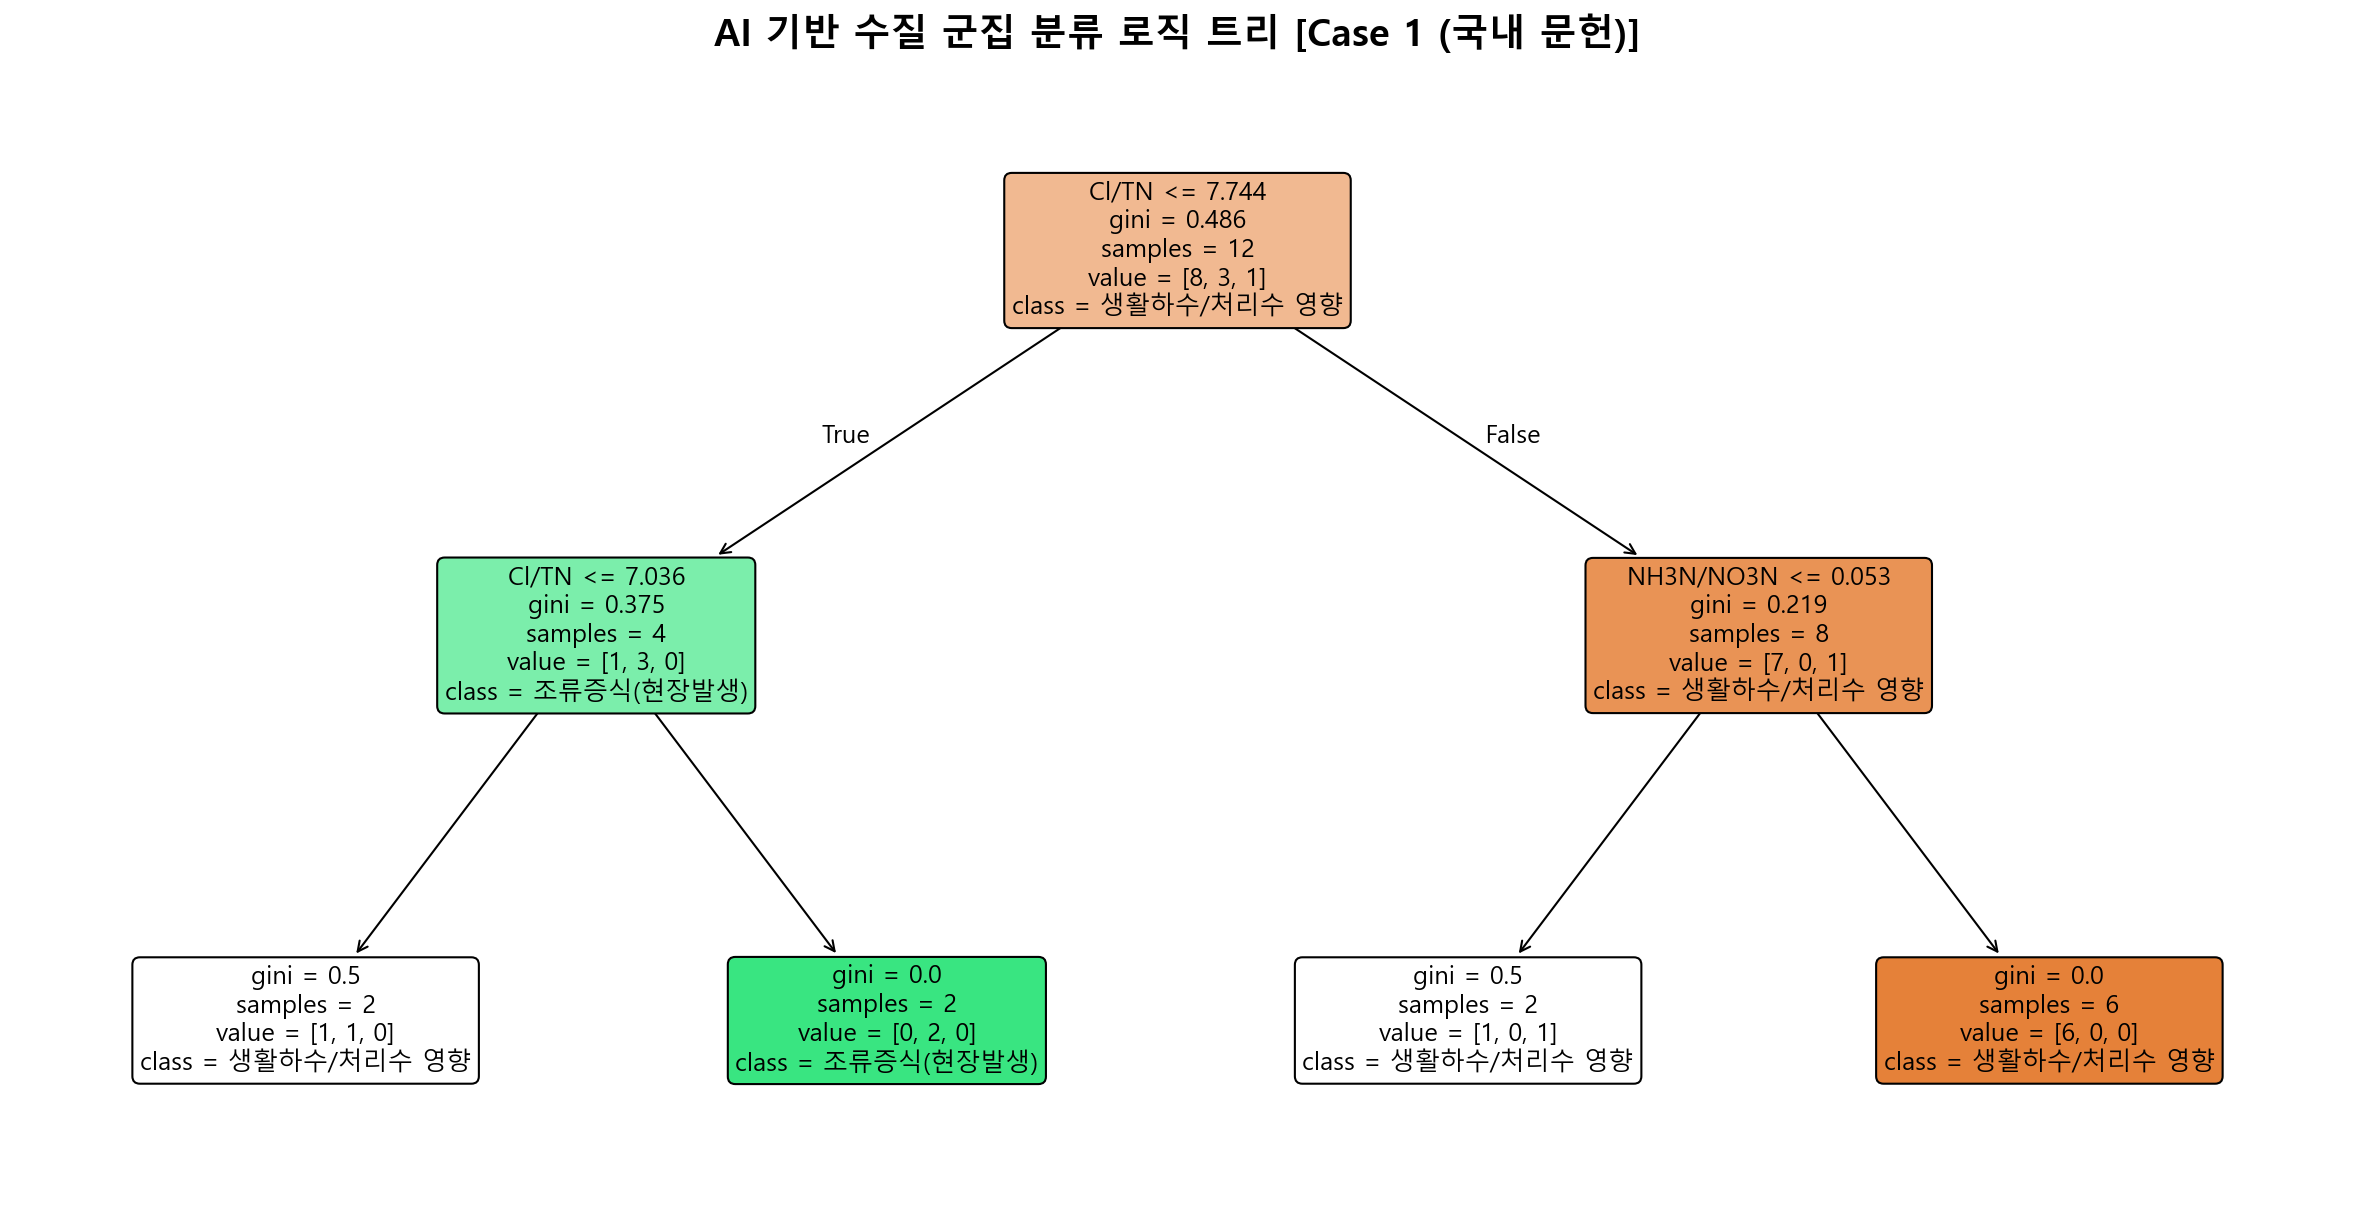

  - Decision Tree 시각화 완료


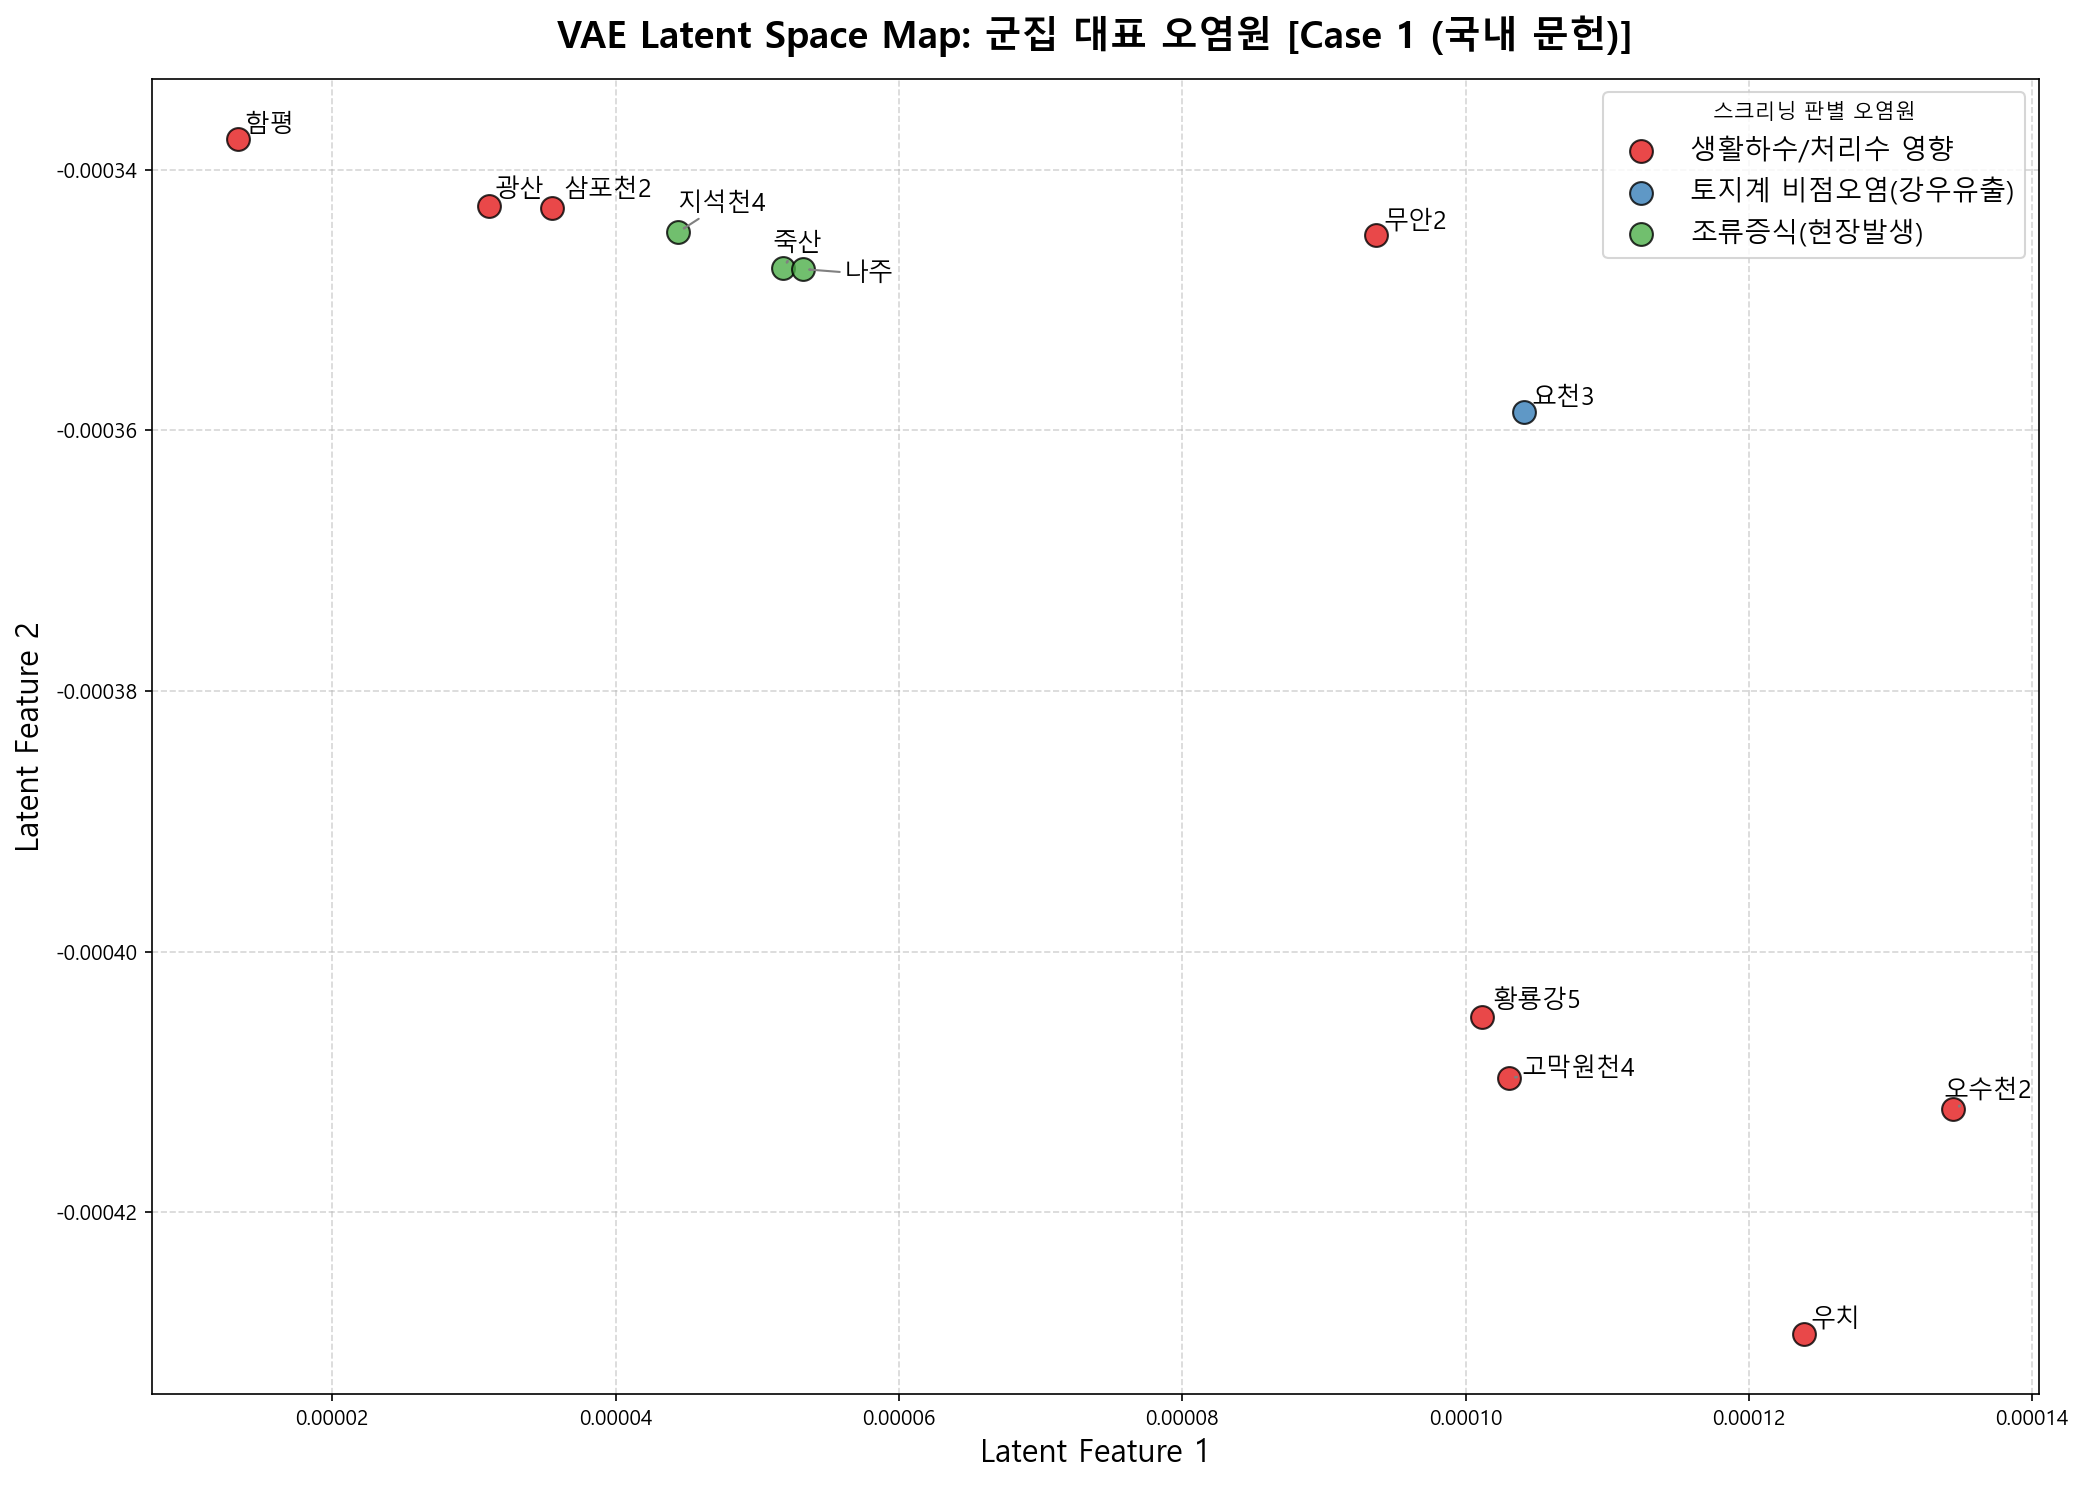

  - 군집 대표 오염원 지도 완료


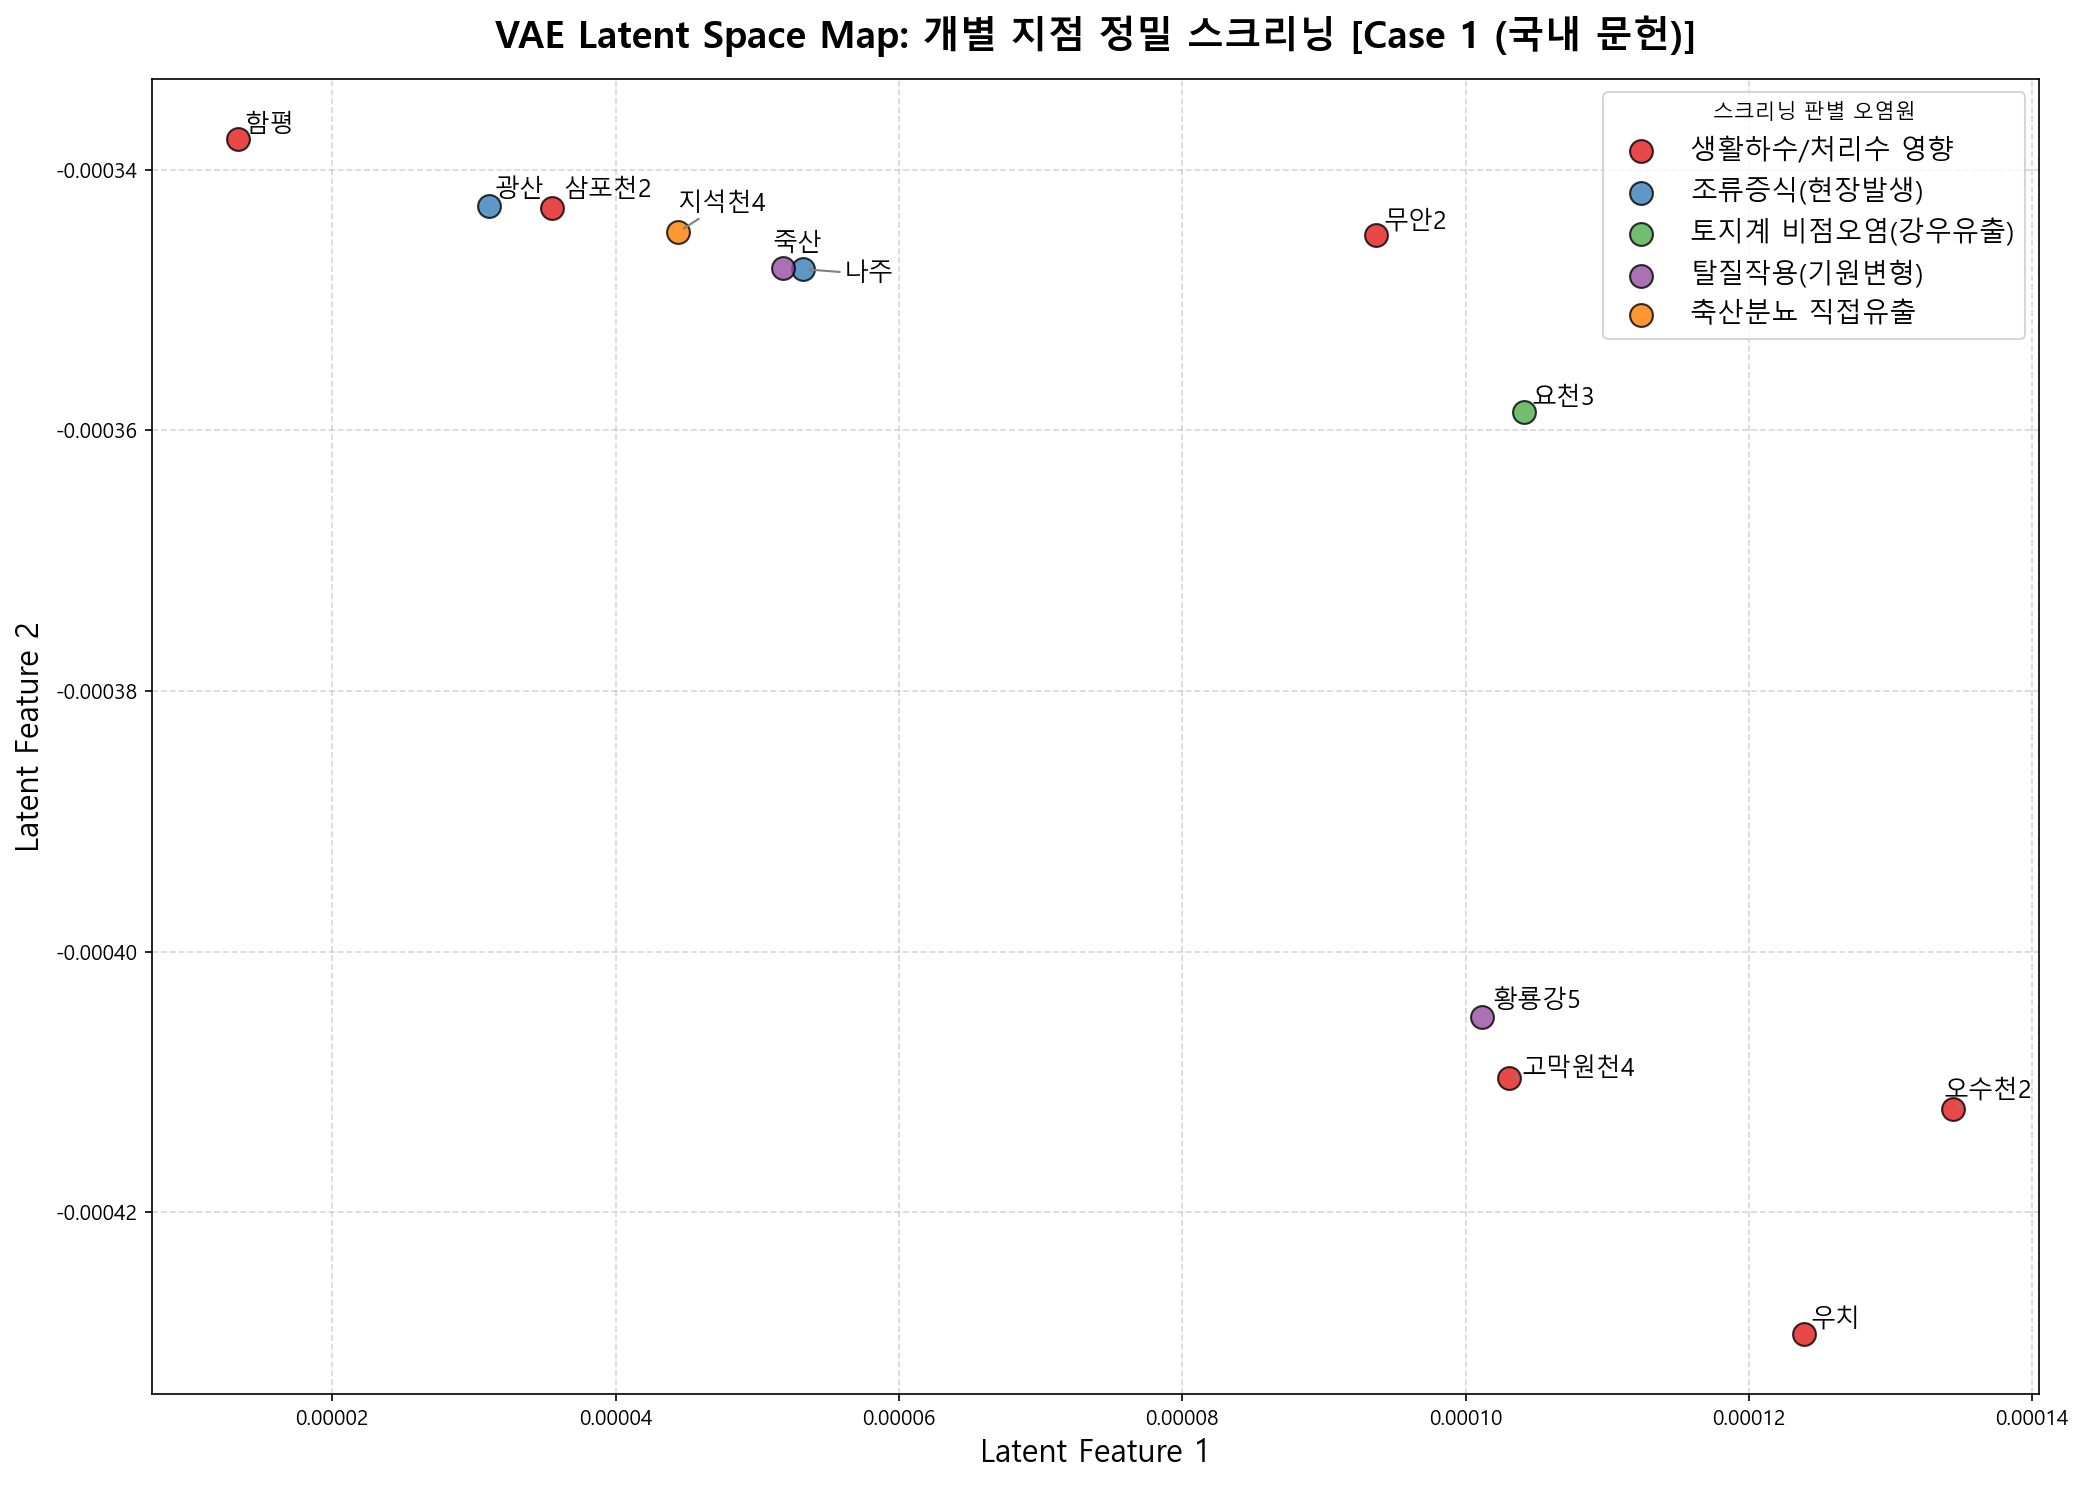

  - 개별 지점 정밀 스크리닝 지도 완료

>>> [Case 2 (국외 문헌)] 프로세스 시작...


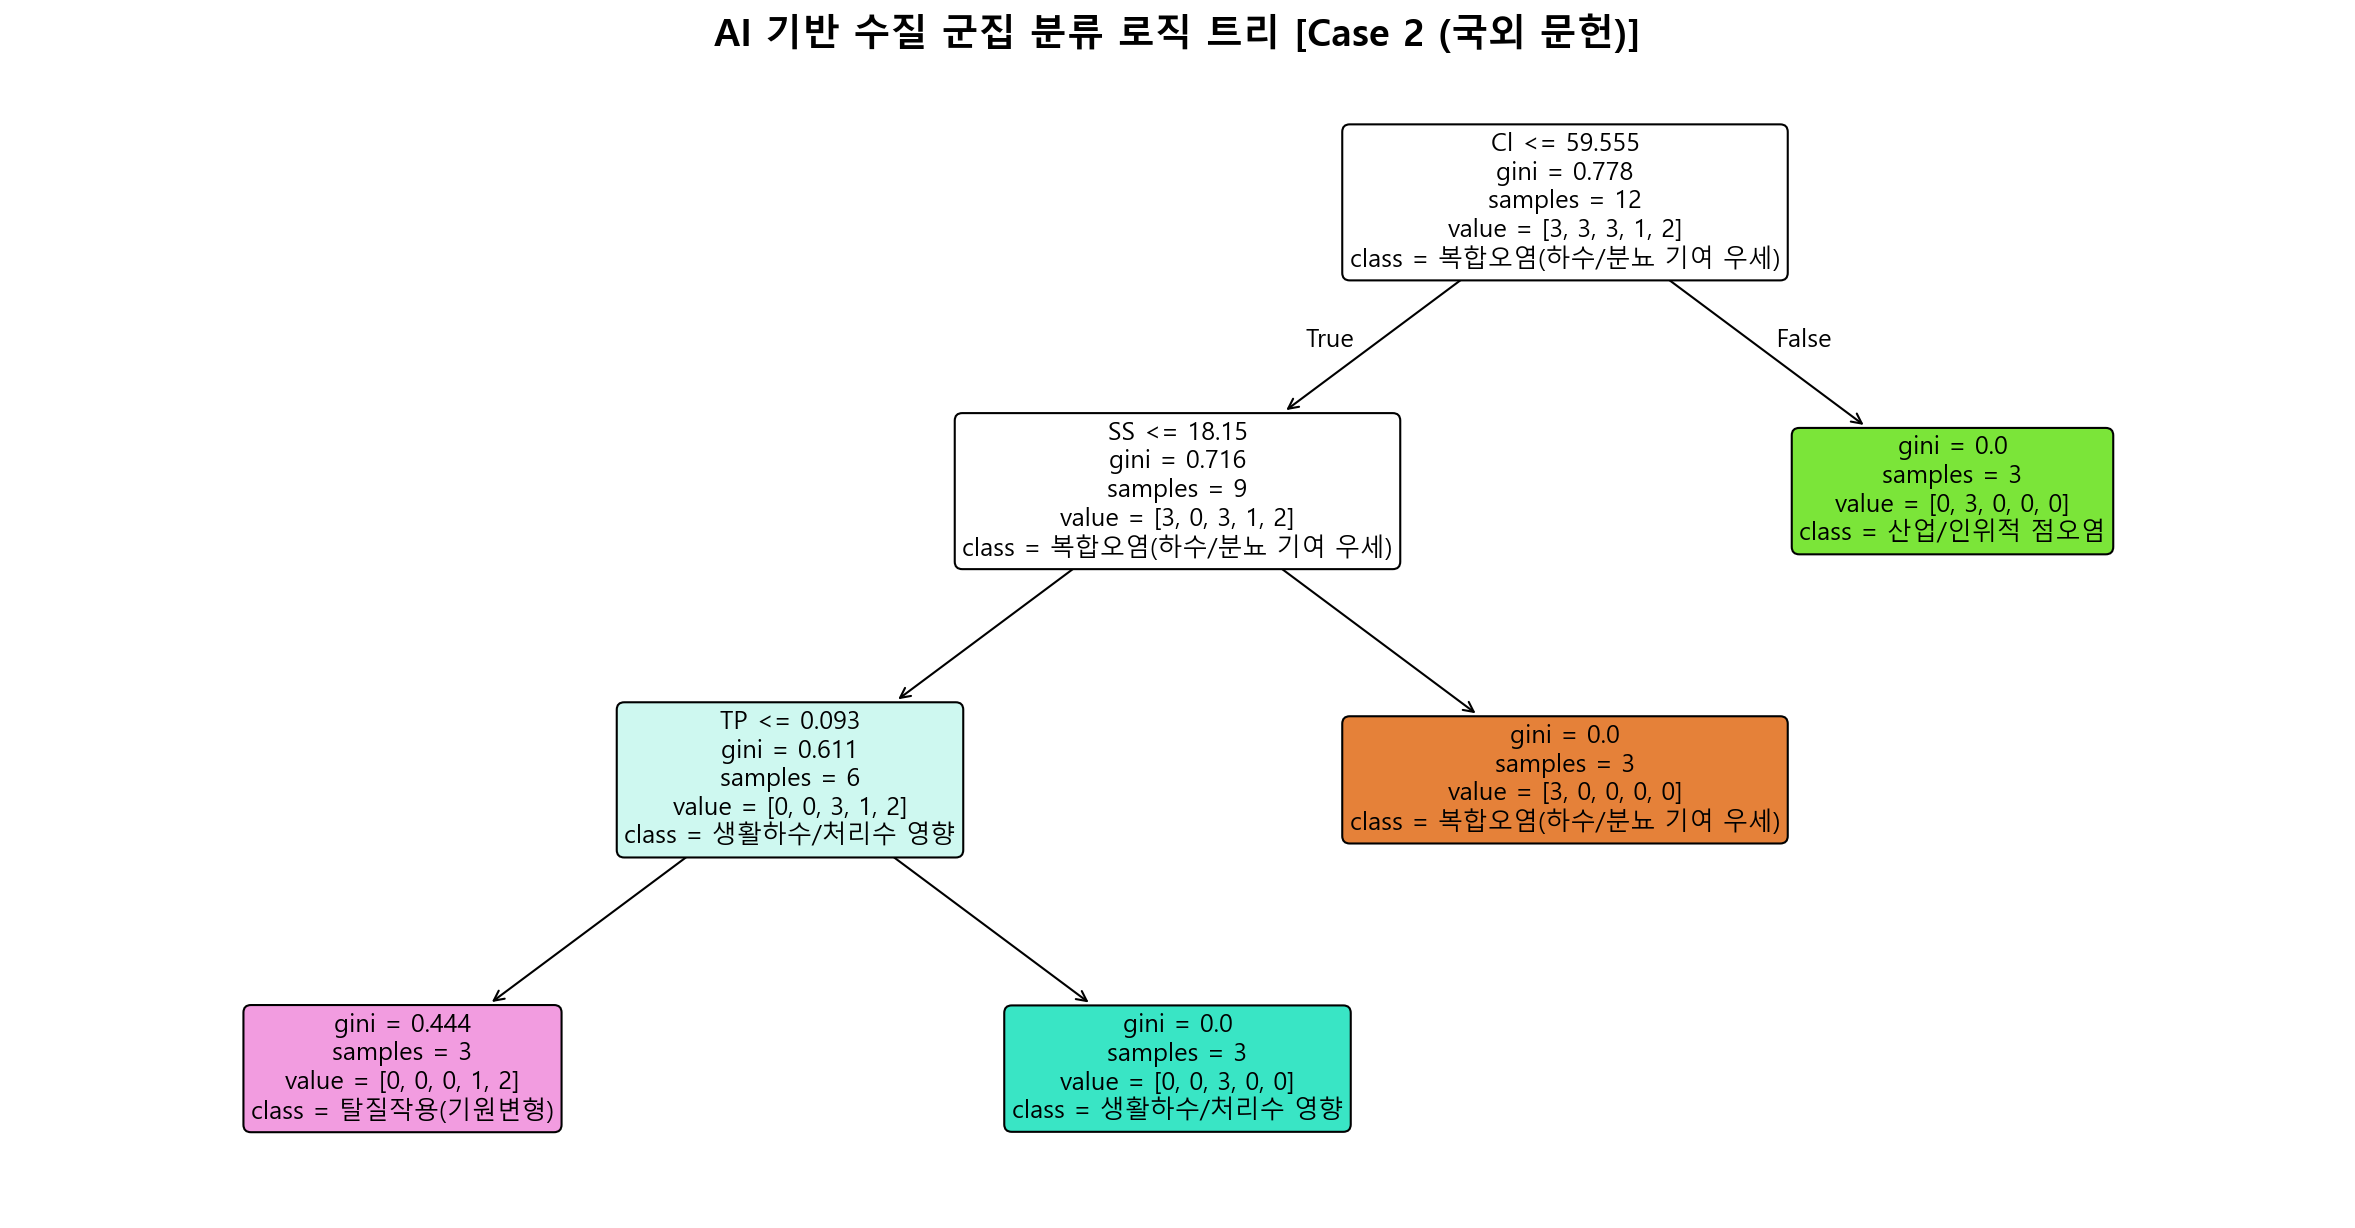

  - Decision Tree 시각화 완료


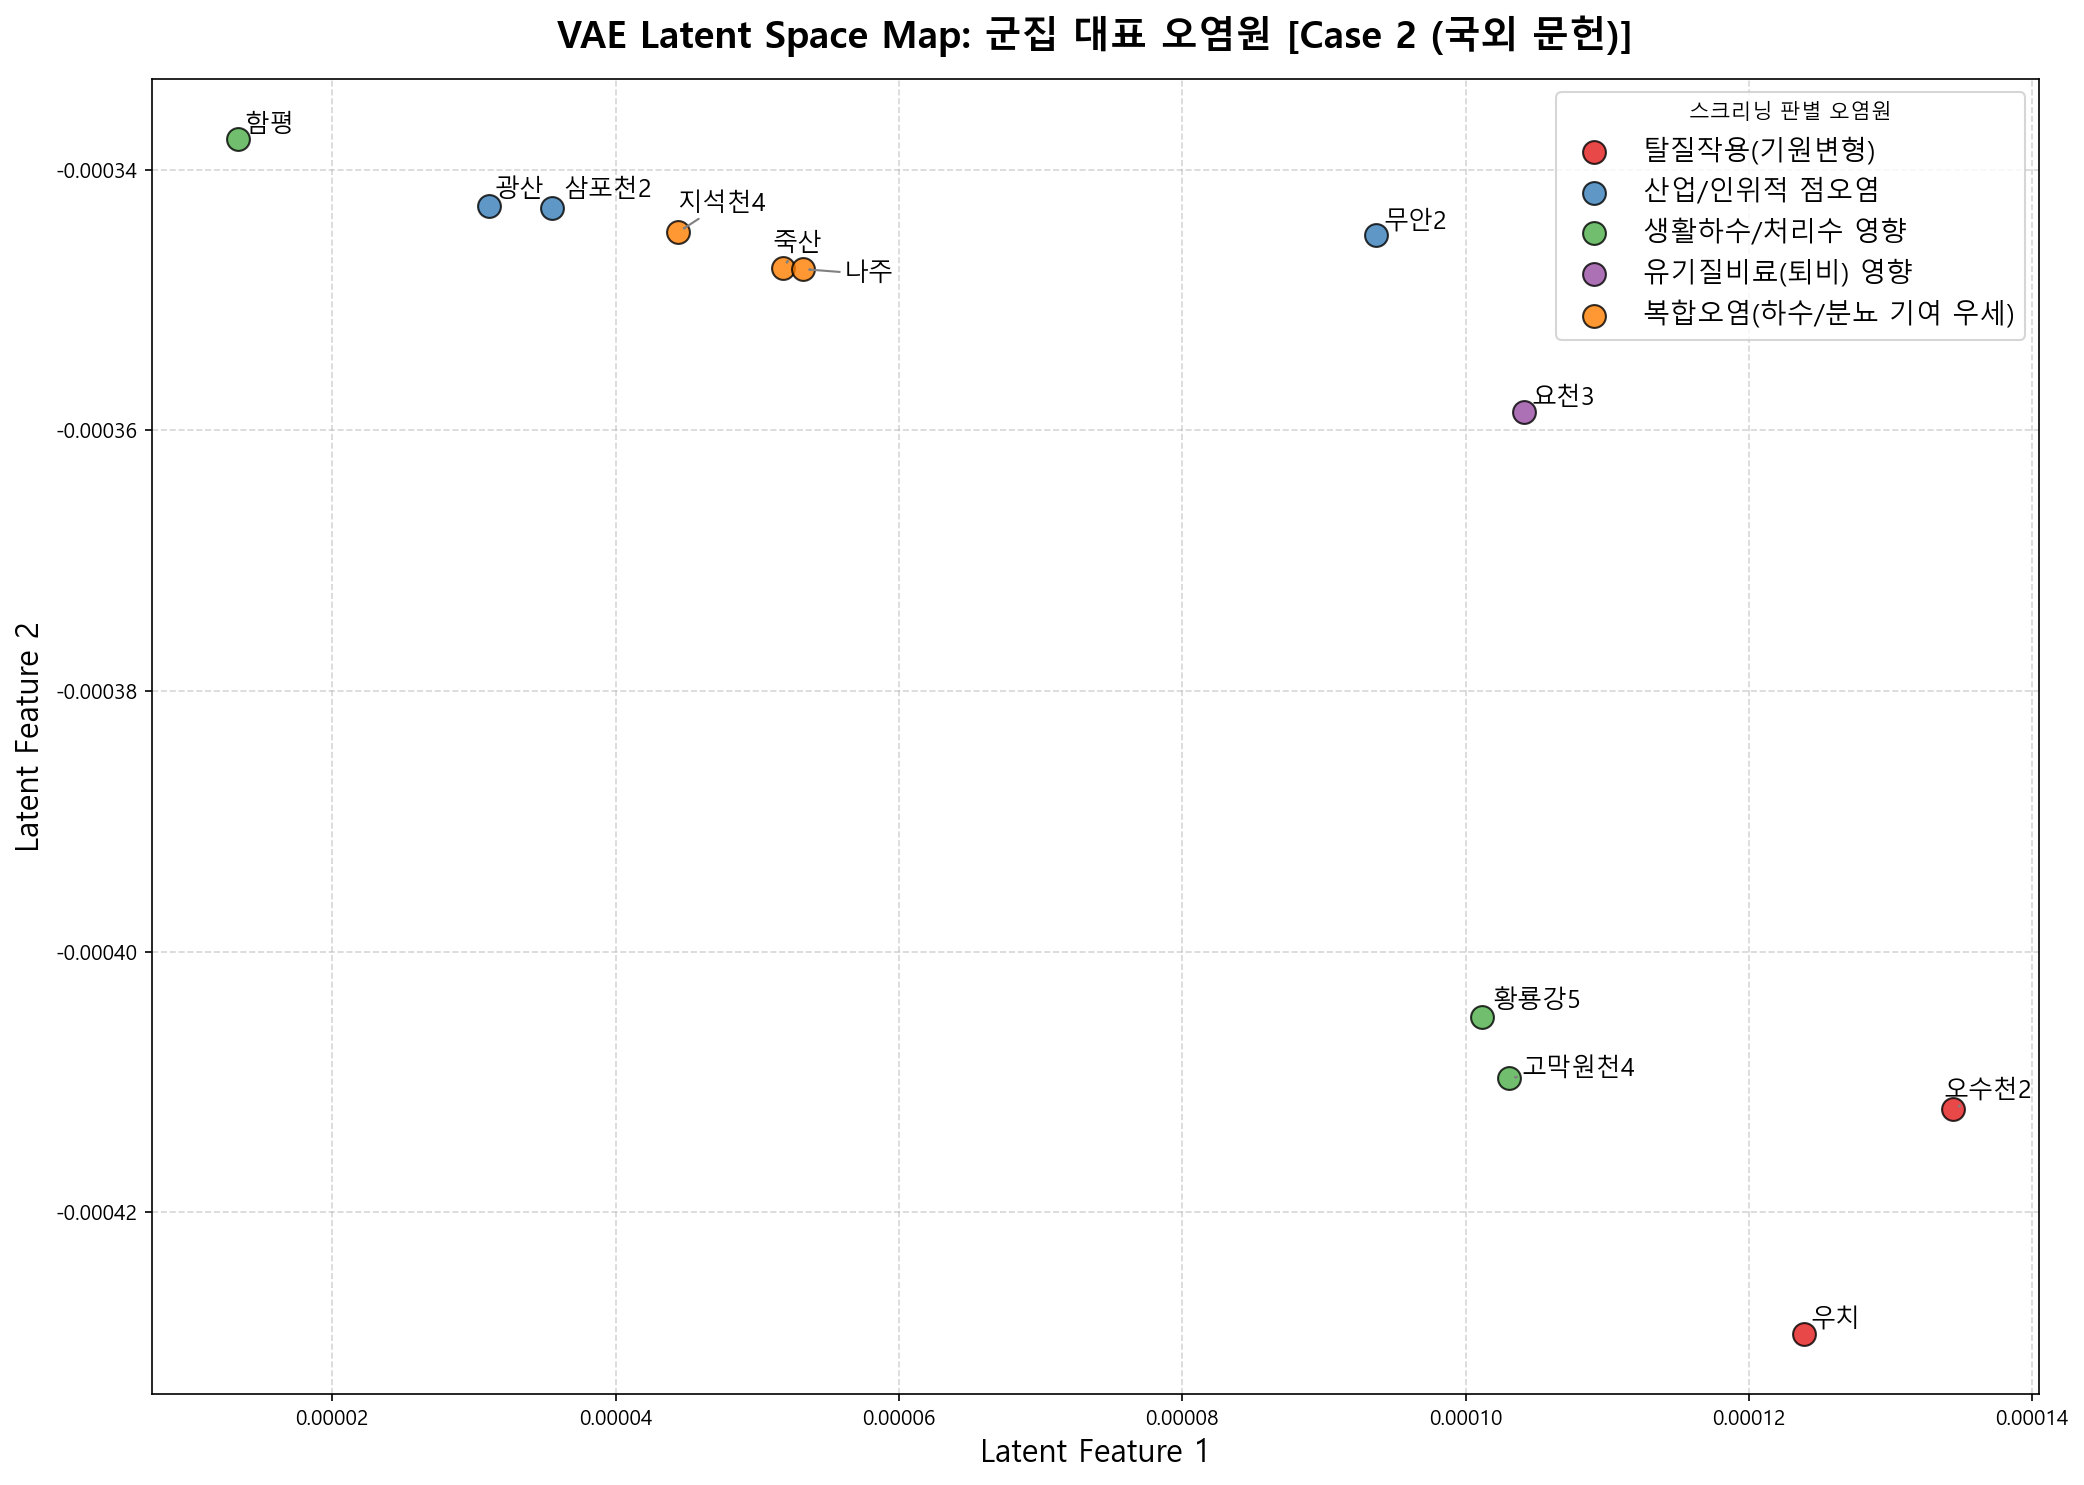

  - 군집 대표 오염원 지도 완료


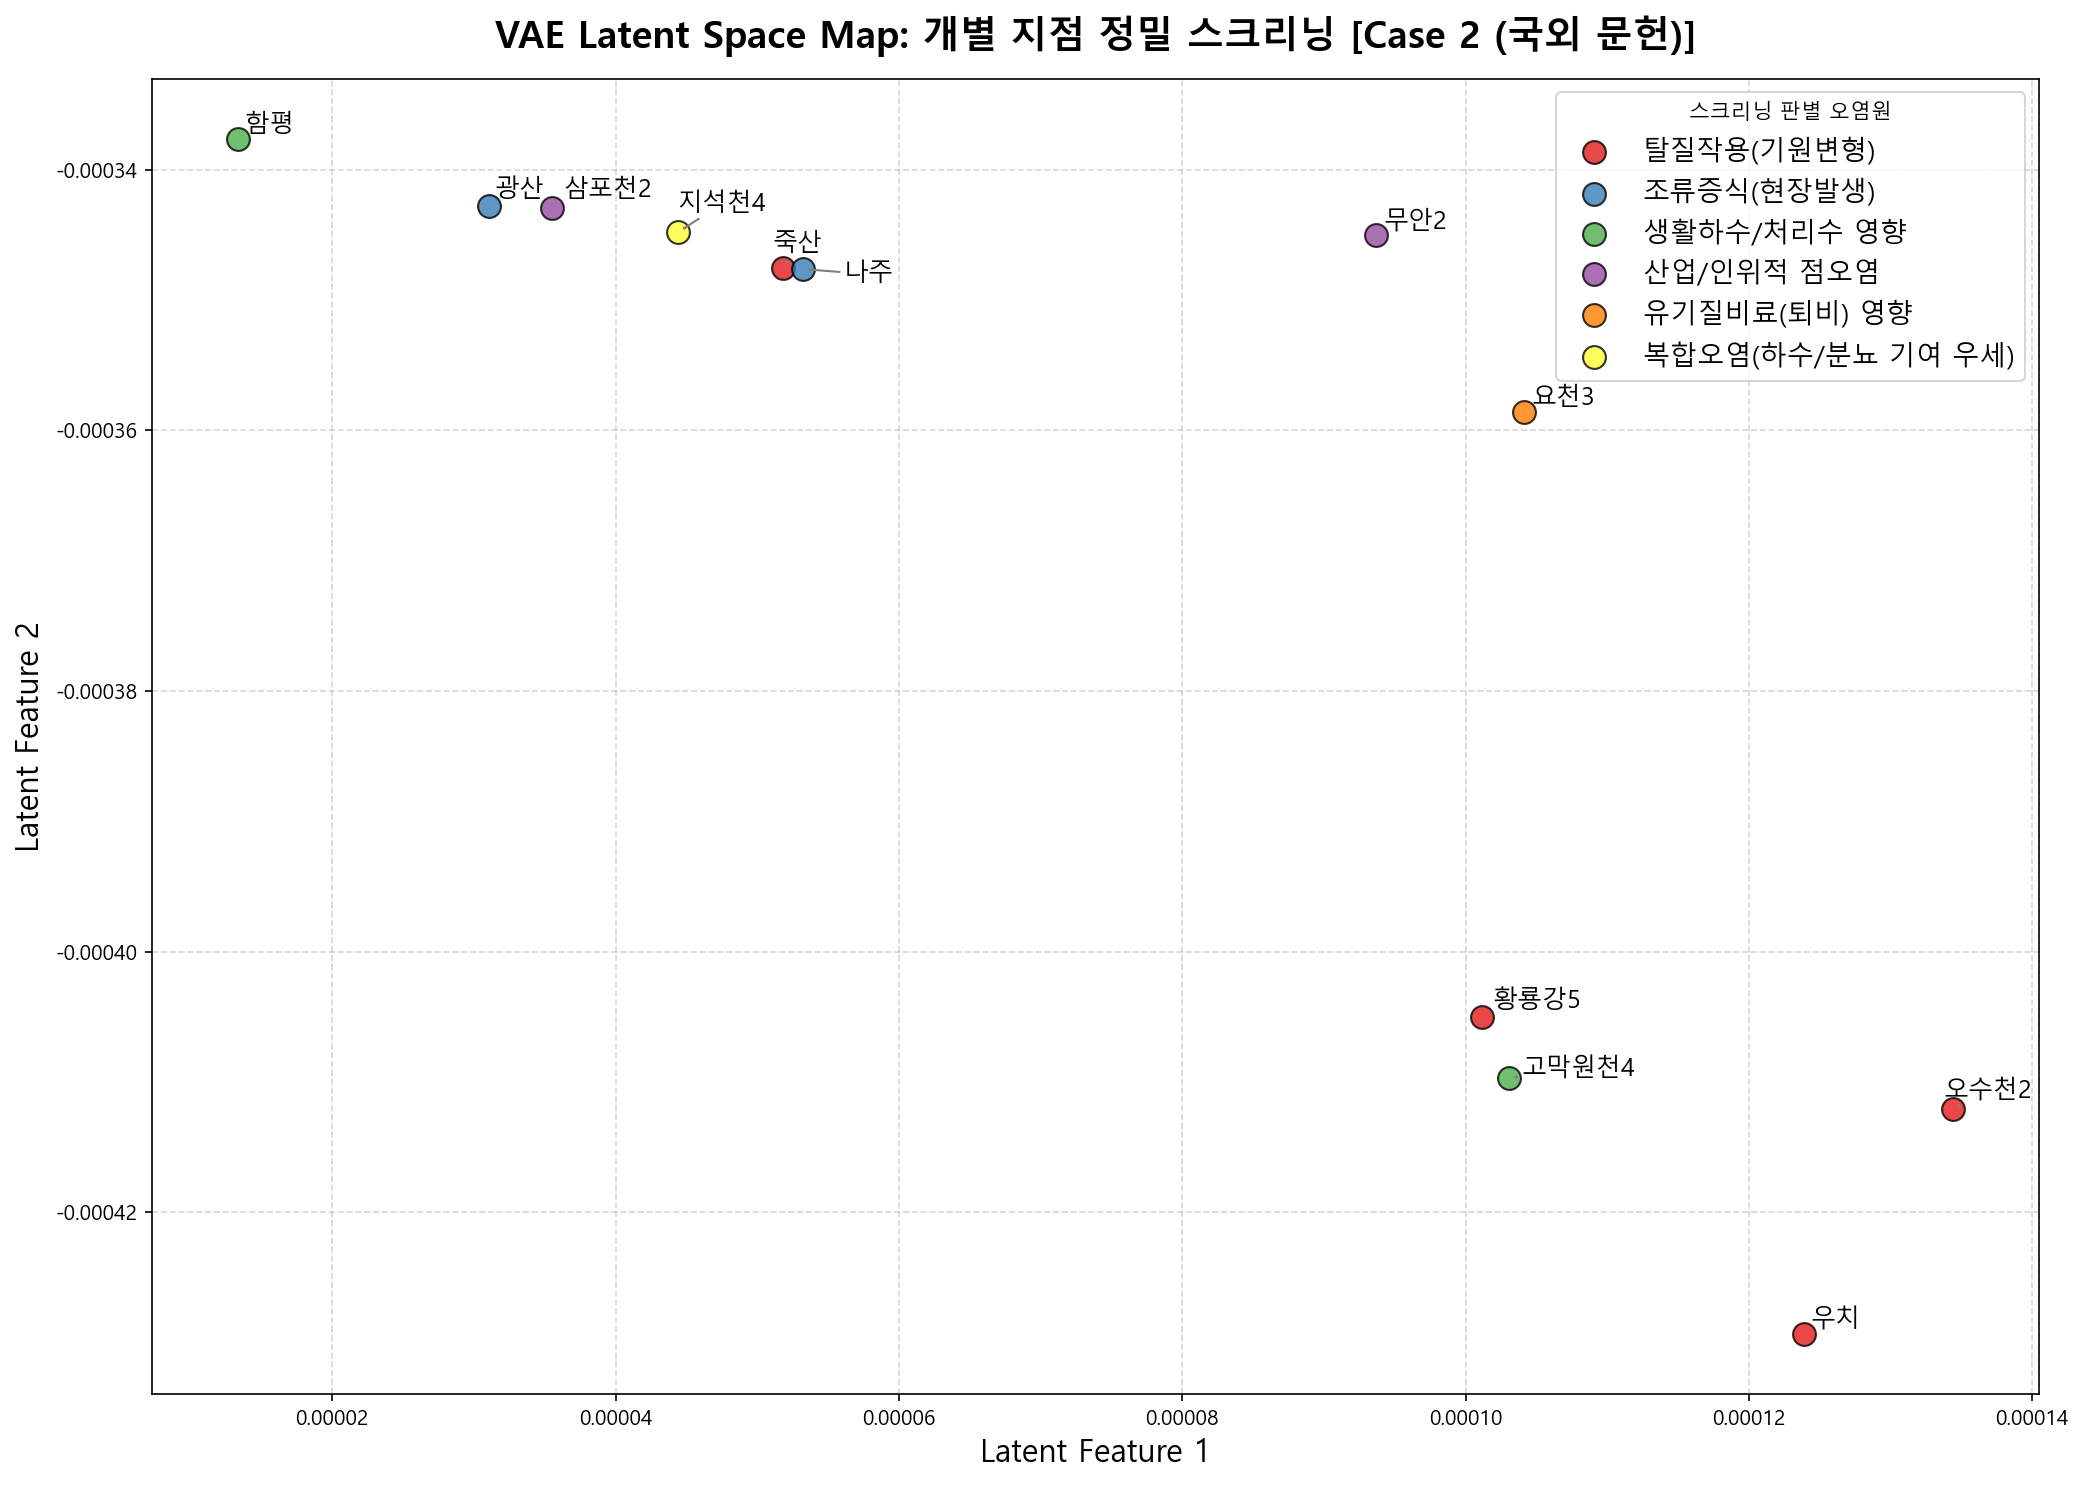

  - 개별 지점 정밀 스크리닝 지도 완료

>>> [Case 3 (통합 문헌)] 프로세스 시작...


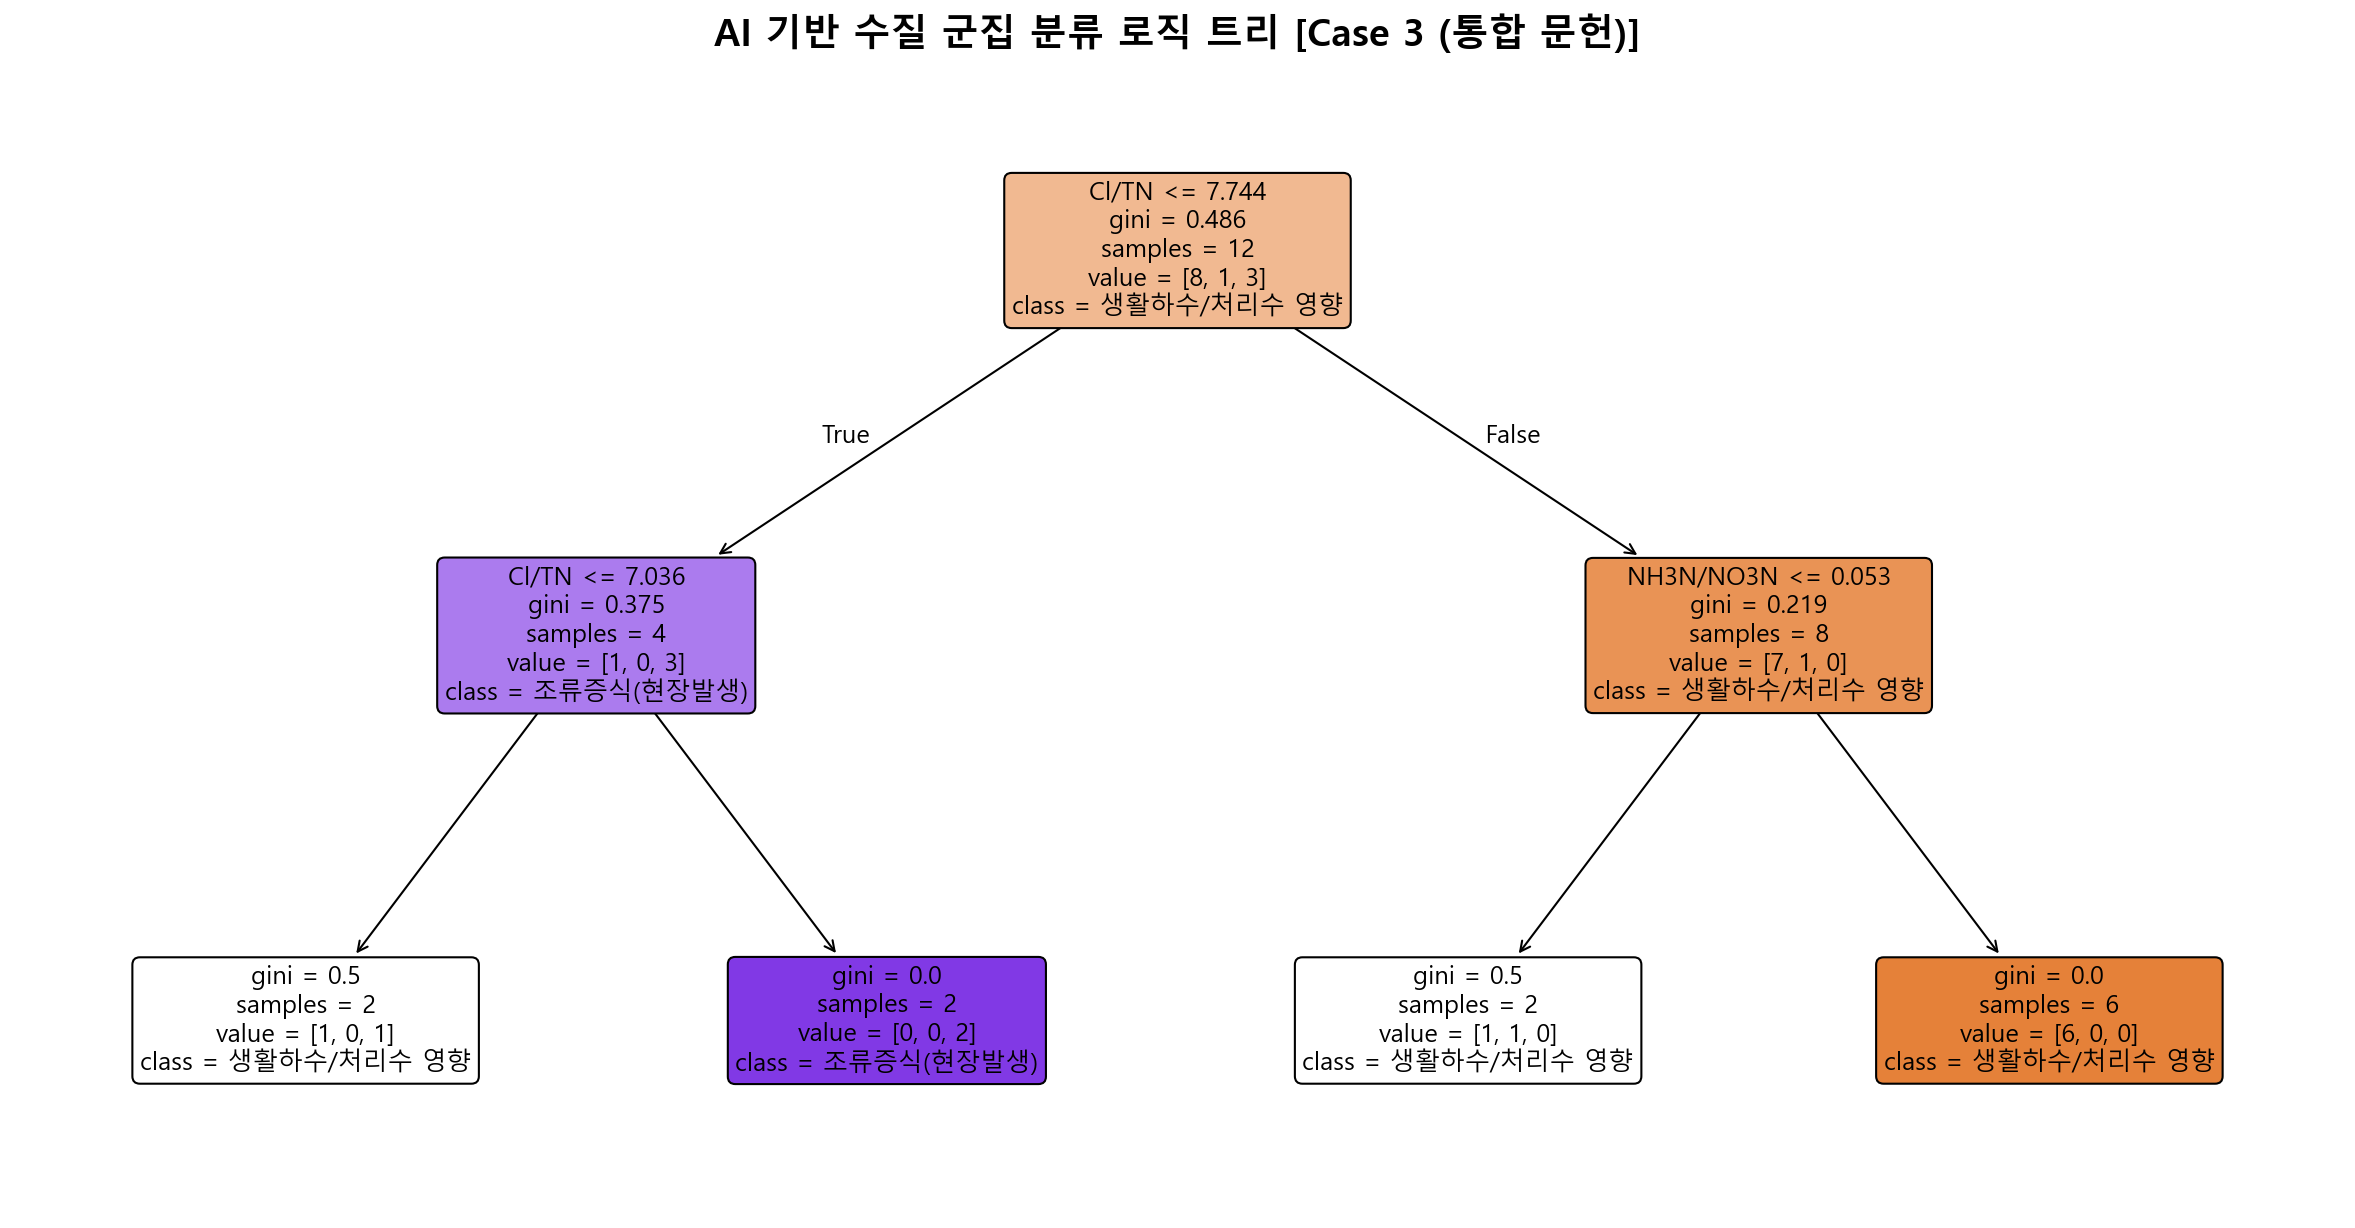

  - Decision Tree 시각화 완료


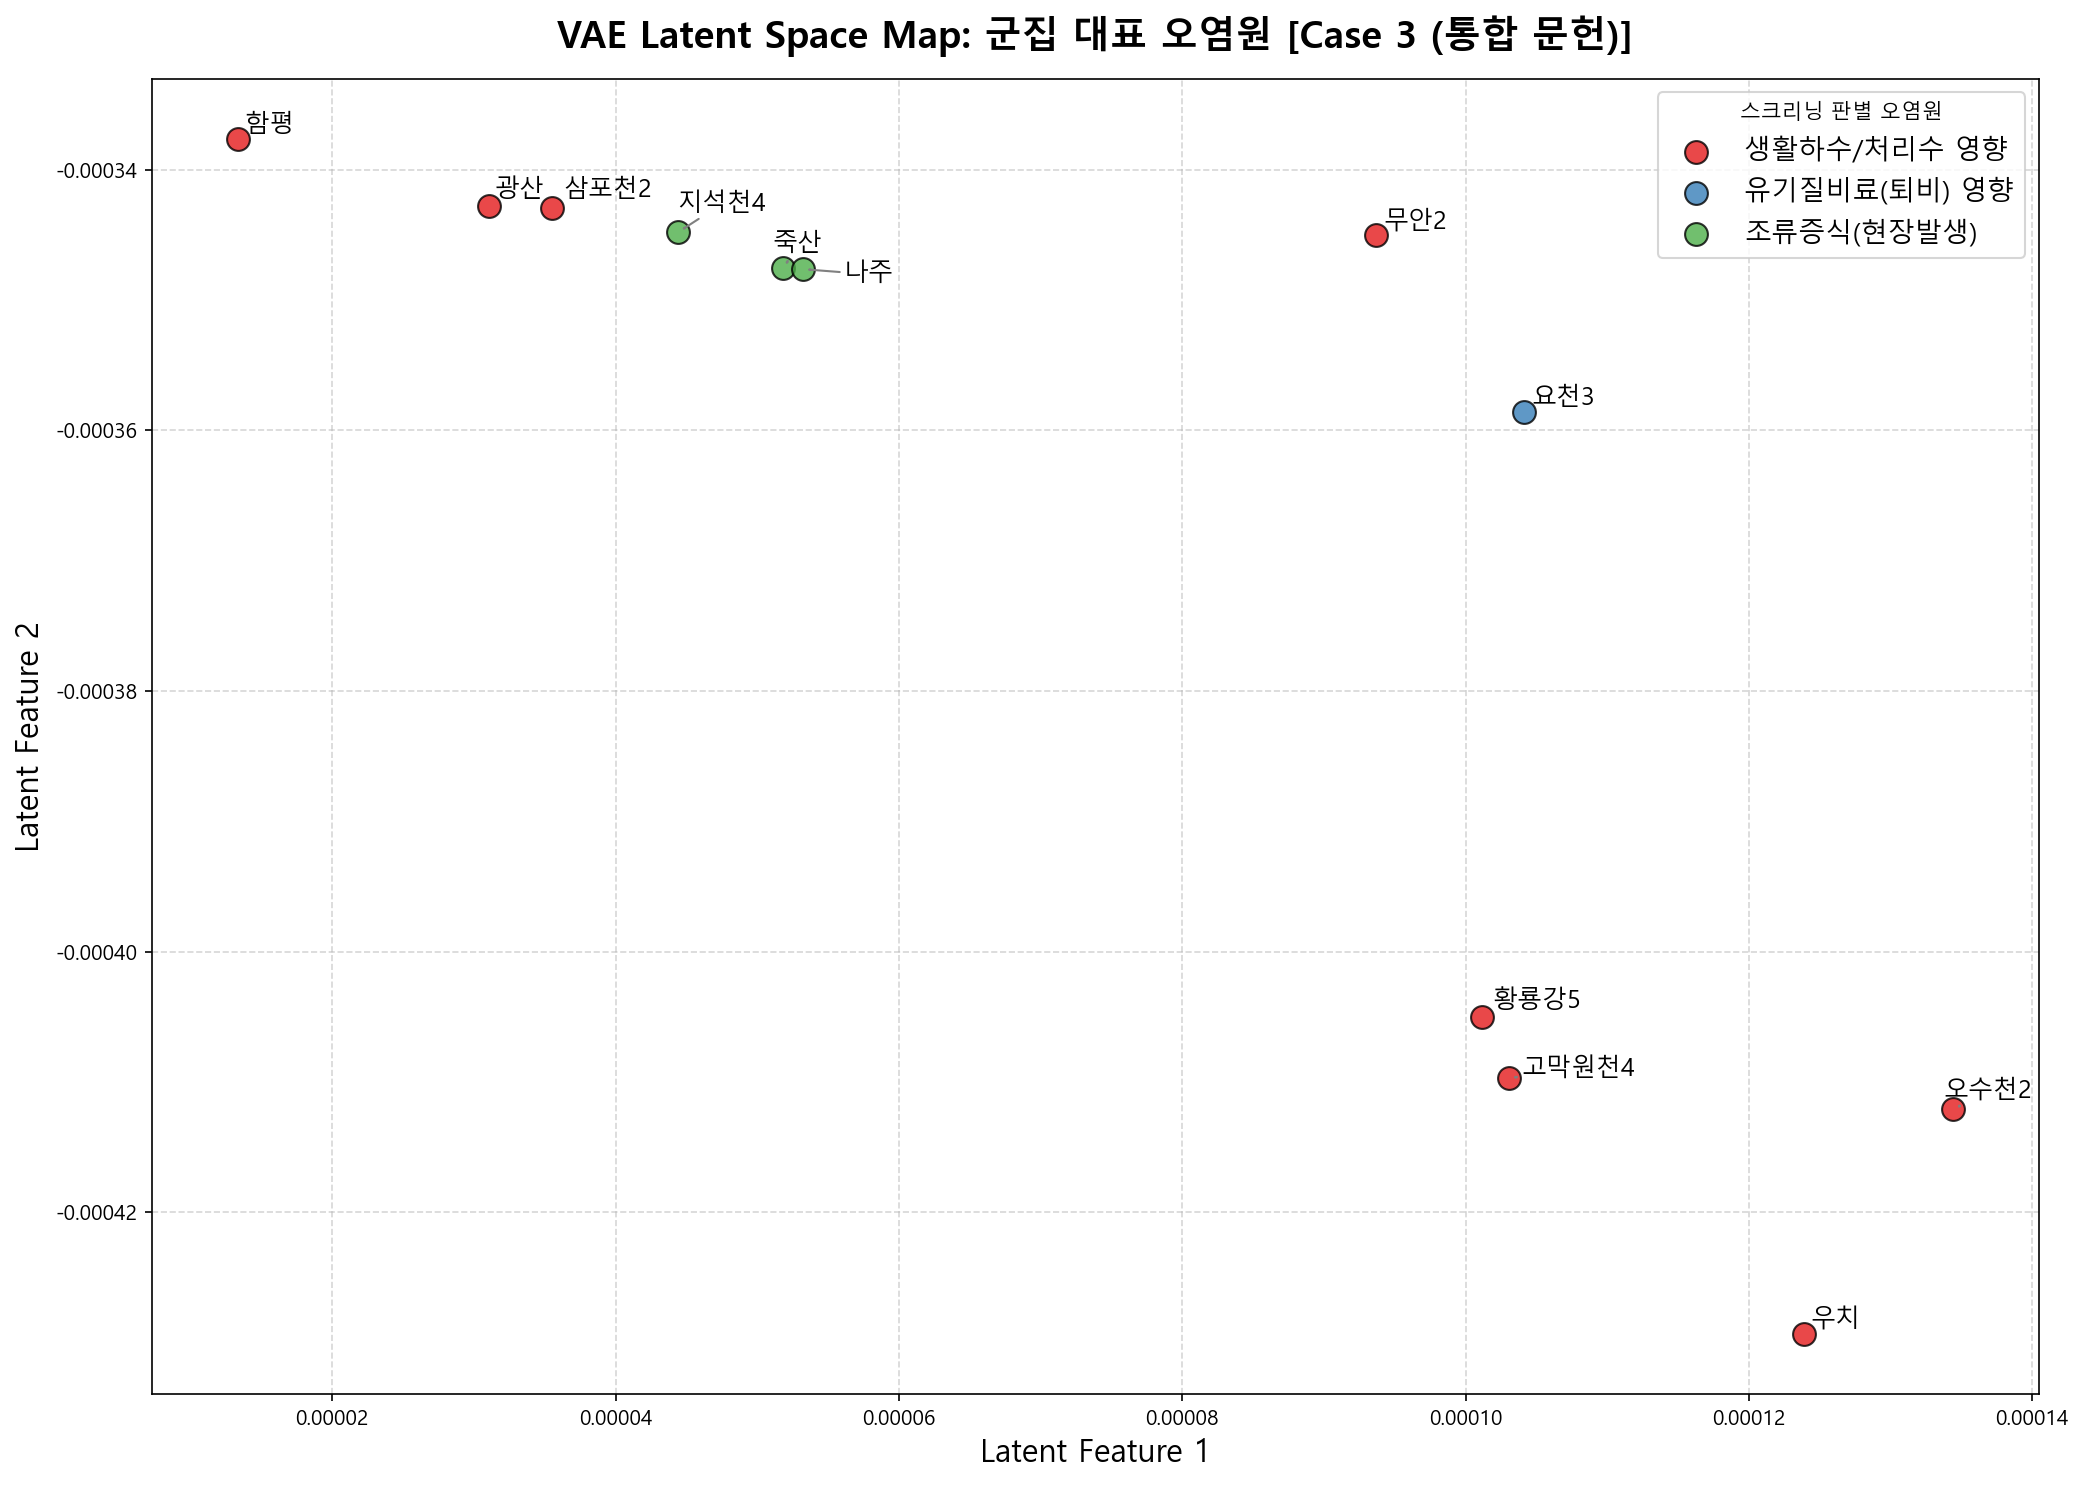

  - 군집 대표 오염원 지도 완료


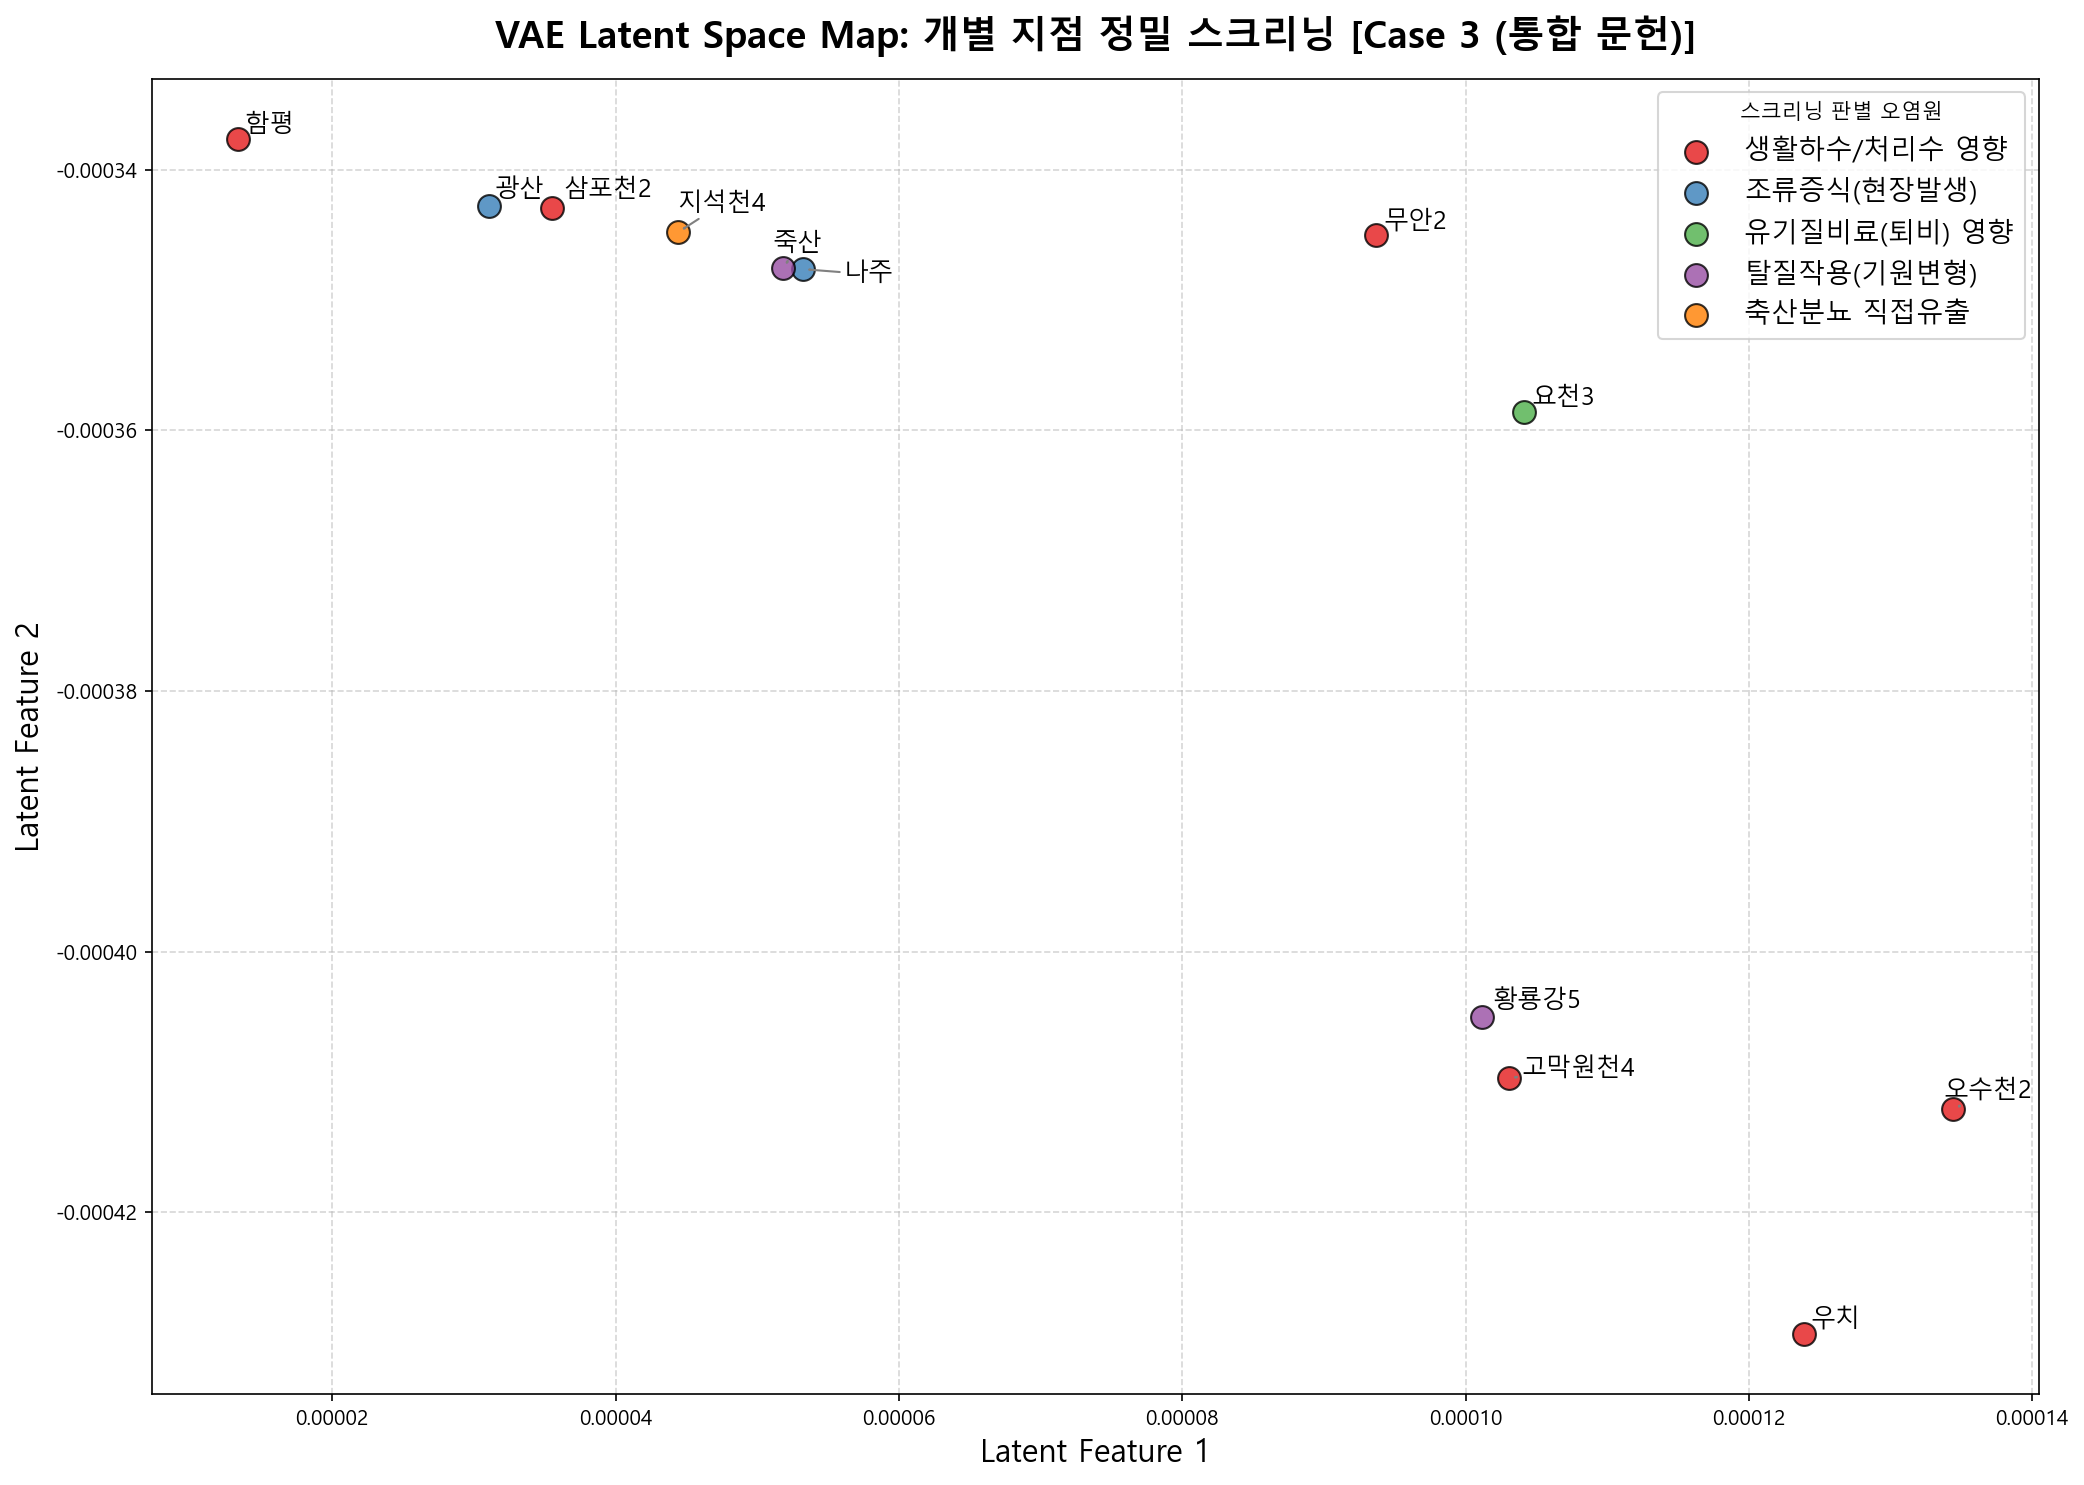

  - 개별 지점 정밀 스크리닝 지도 완료

>>> [최종 (AI 보정)] 프로세스 시작...


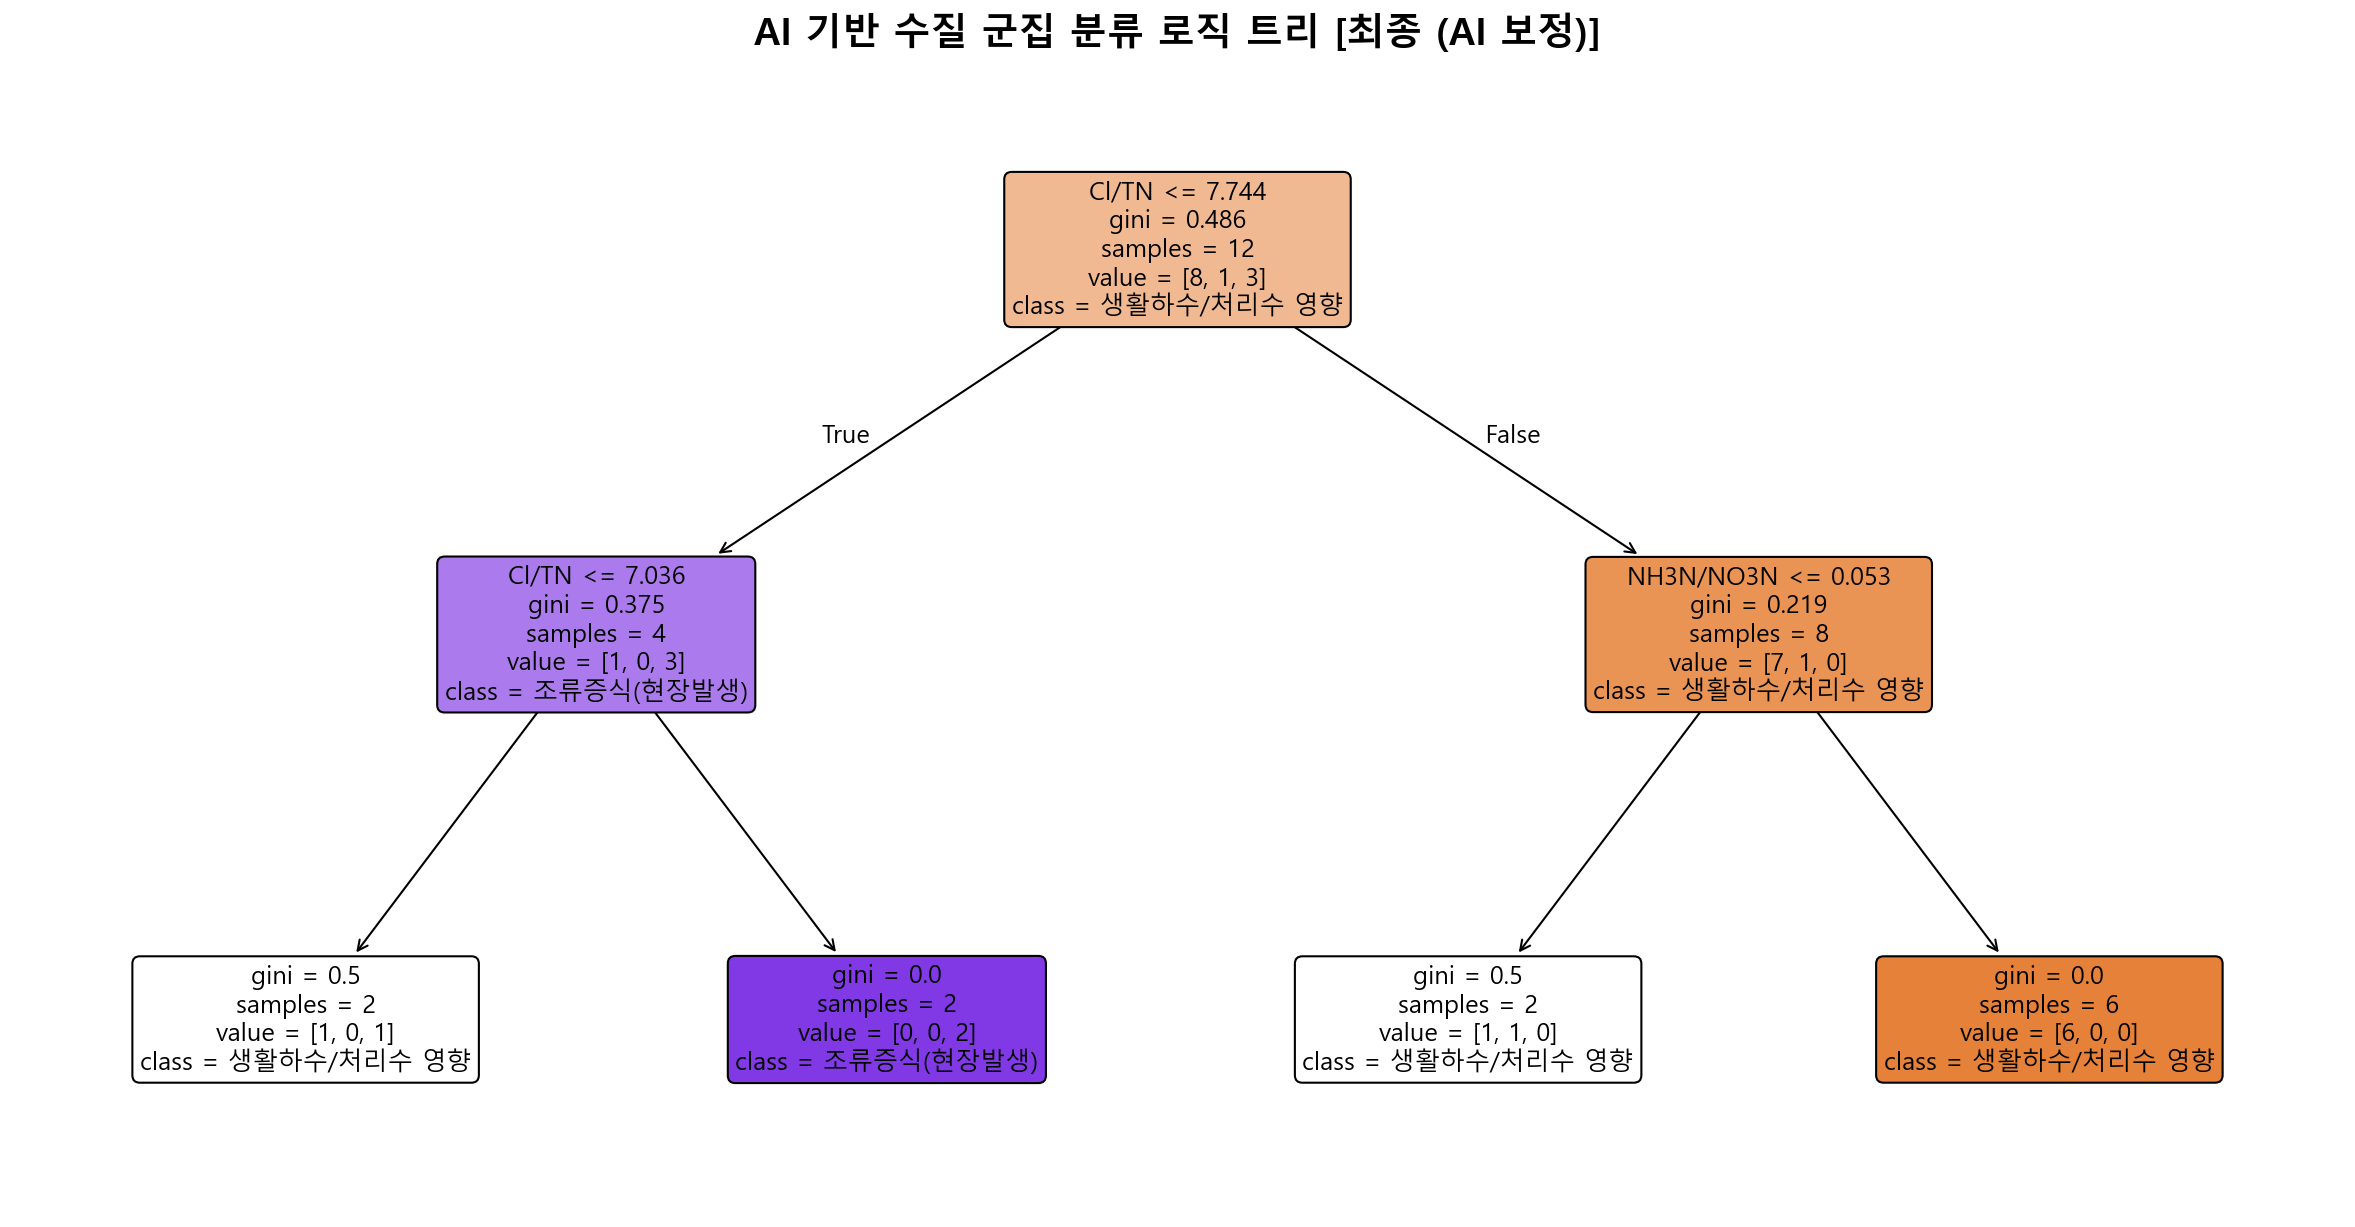

  - Decision Tree 시각화 완료


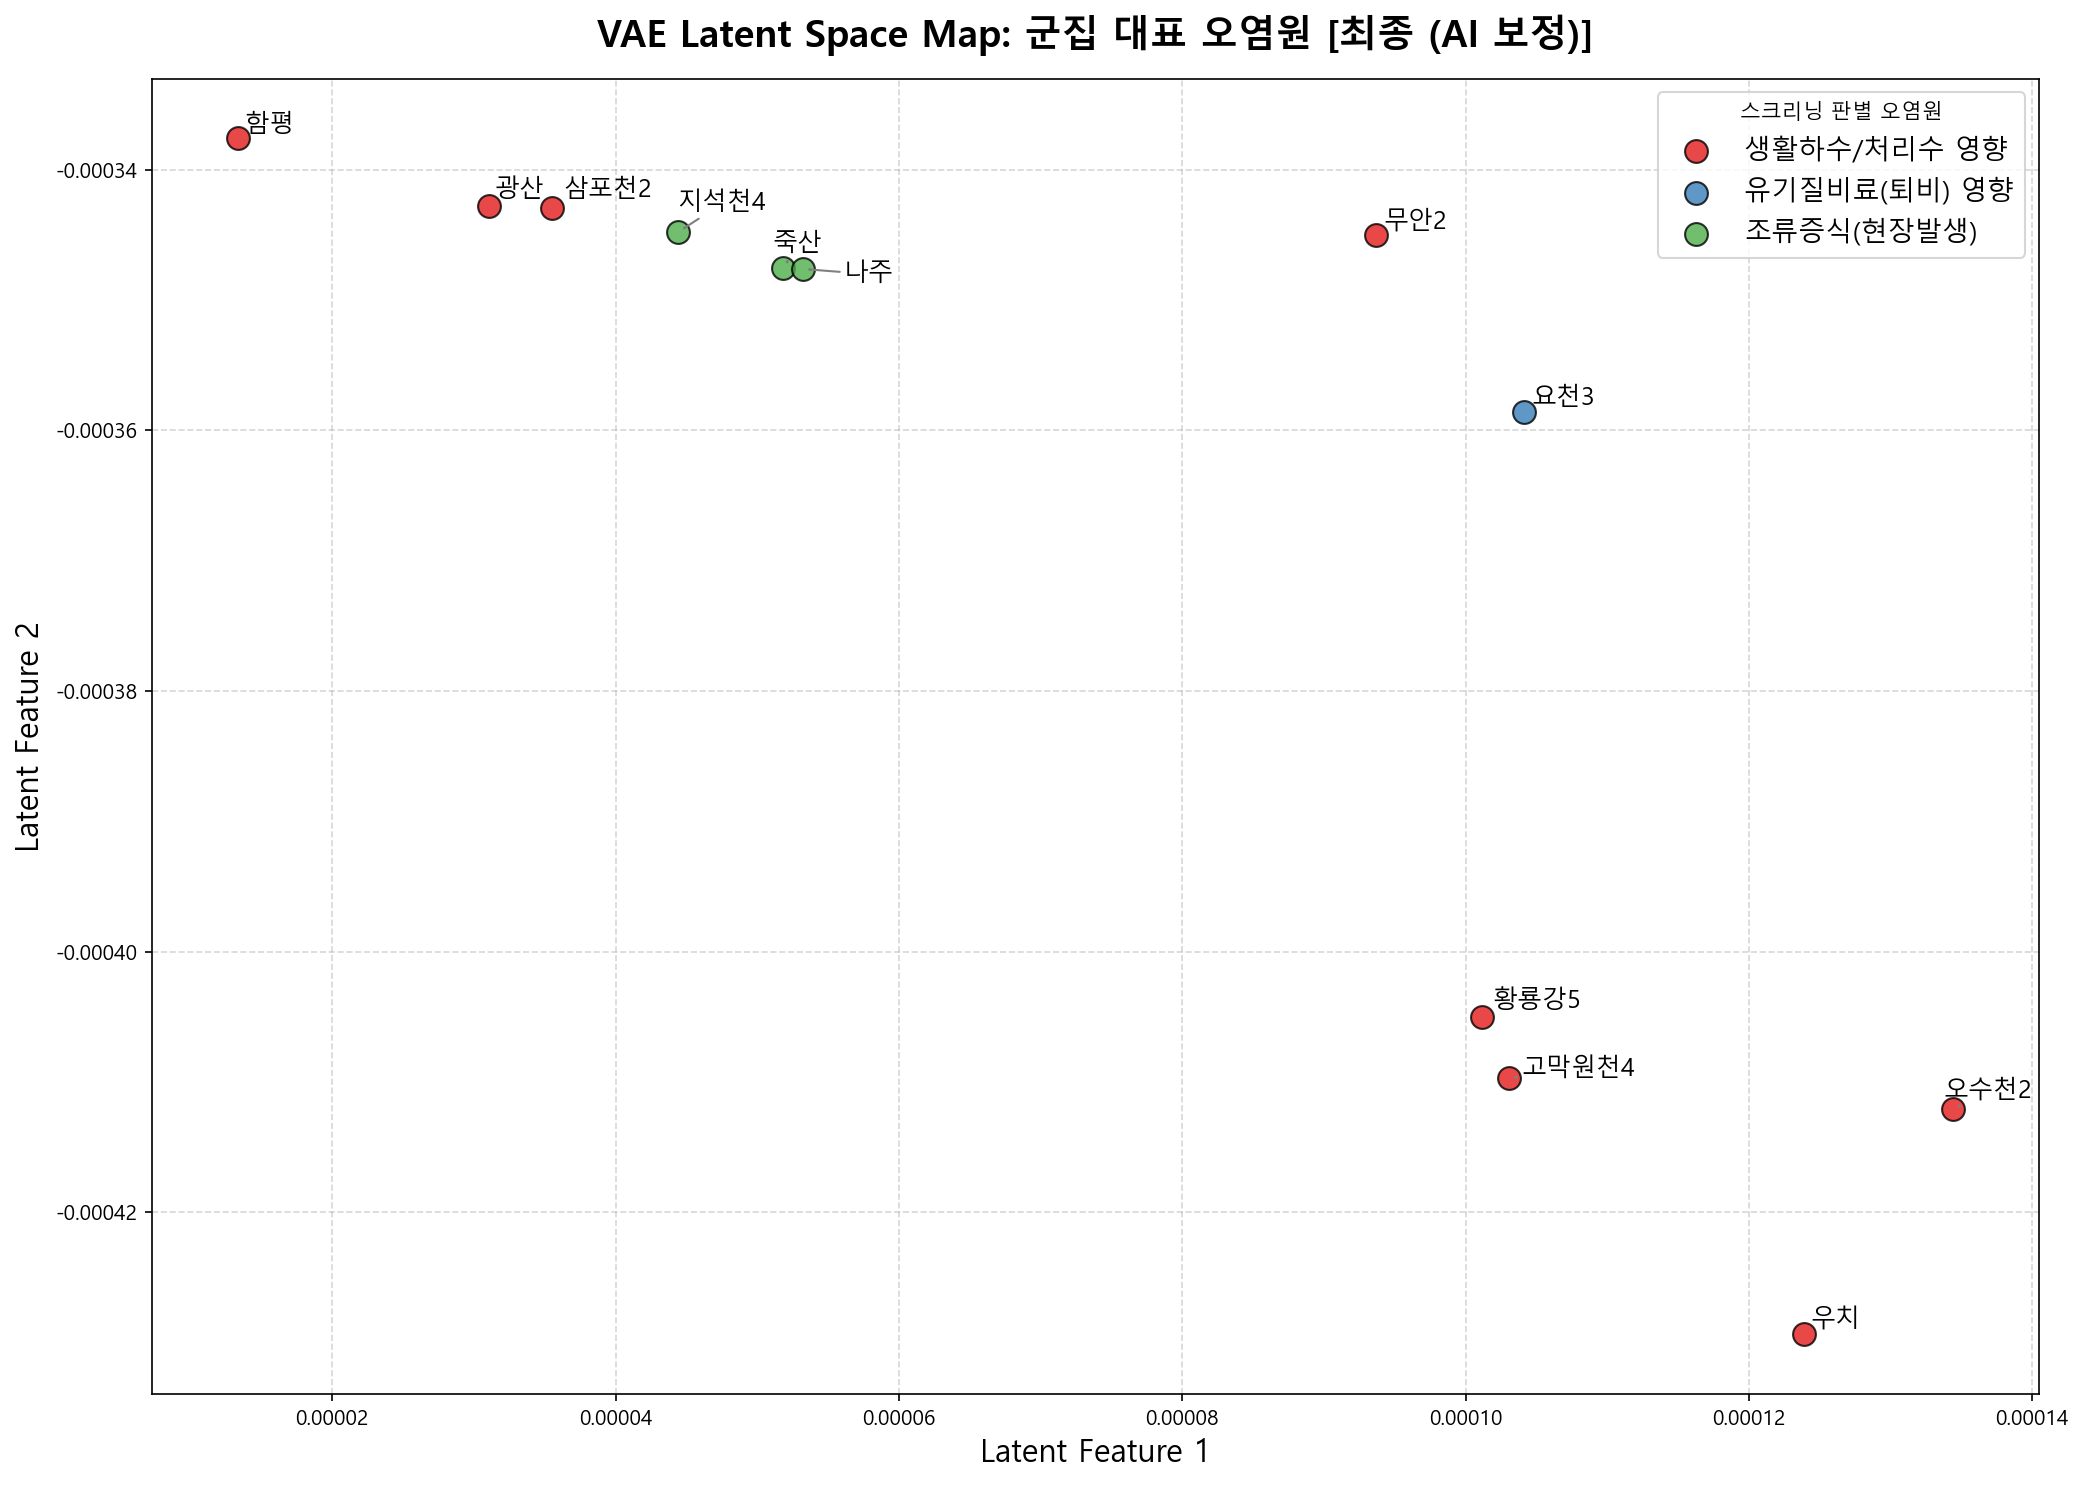

  - 군집 대표 오염원 지도 완료


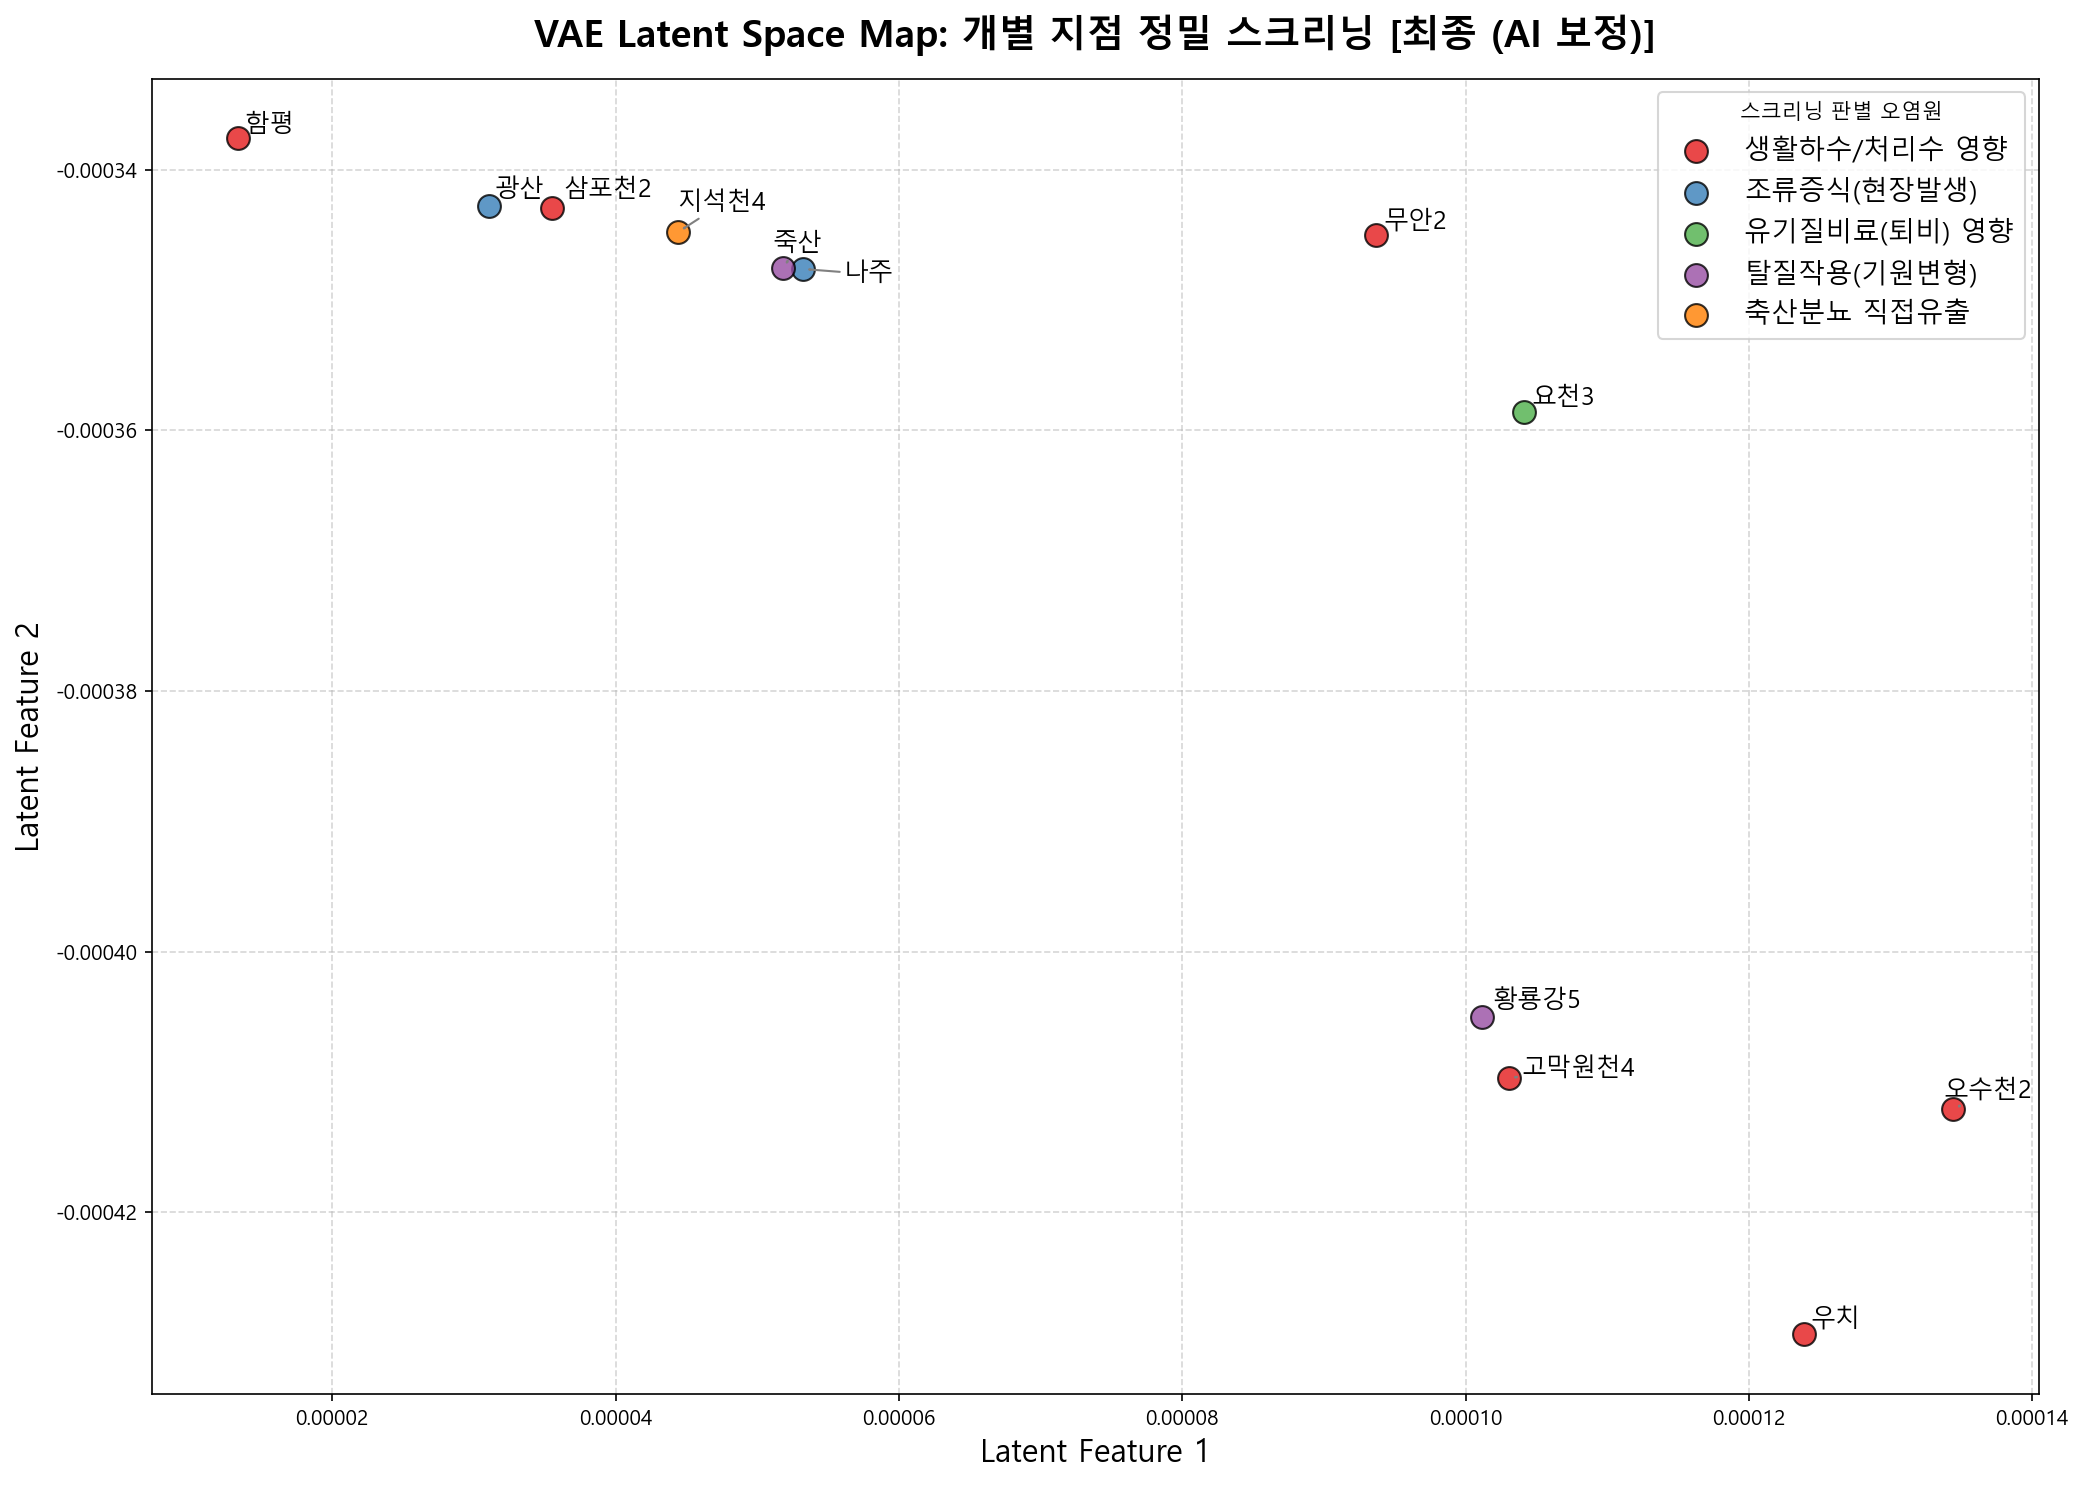

  - 개별 지점 정밀 스크리닝 지도 완료

[*] 모든 케이스에 대한 루프 프로세스가 종료되었습니다.


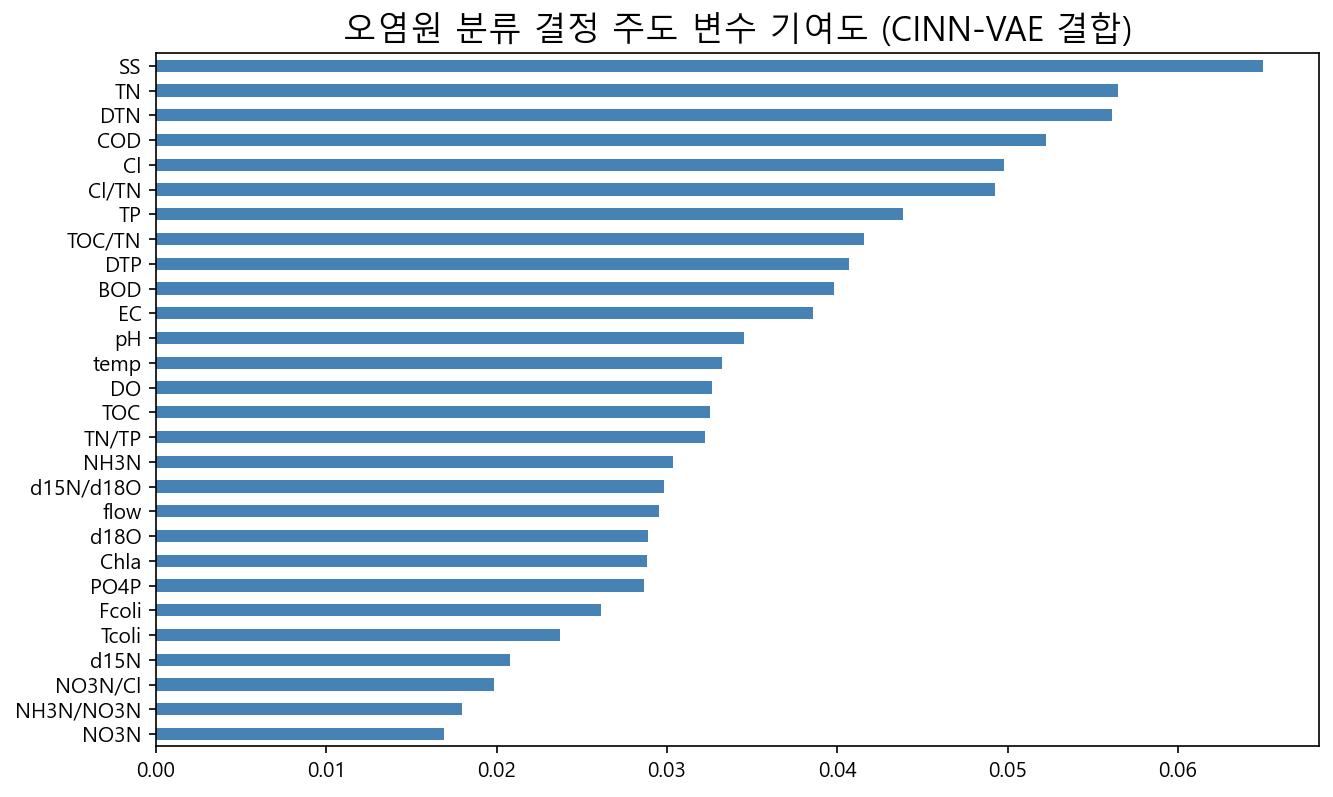

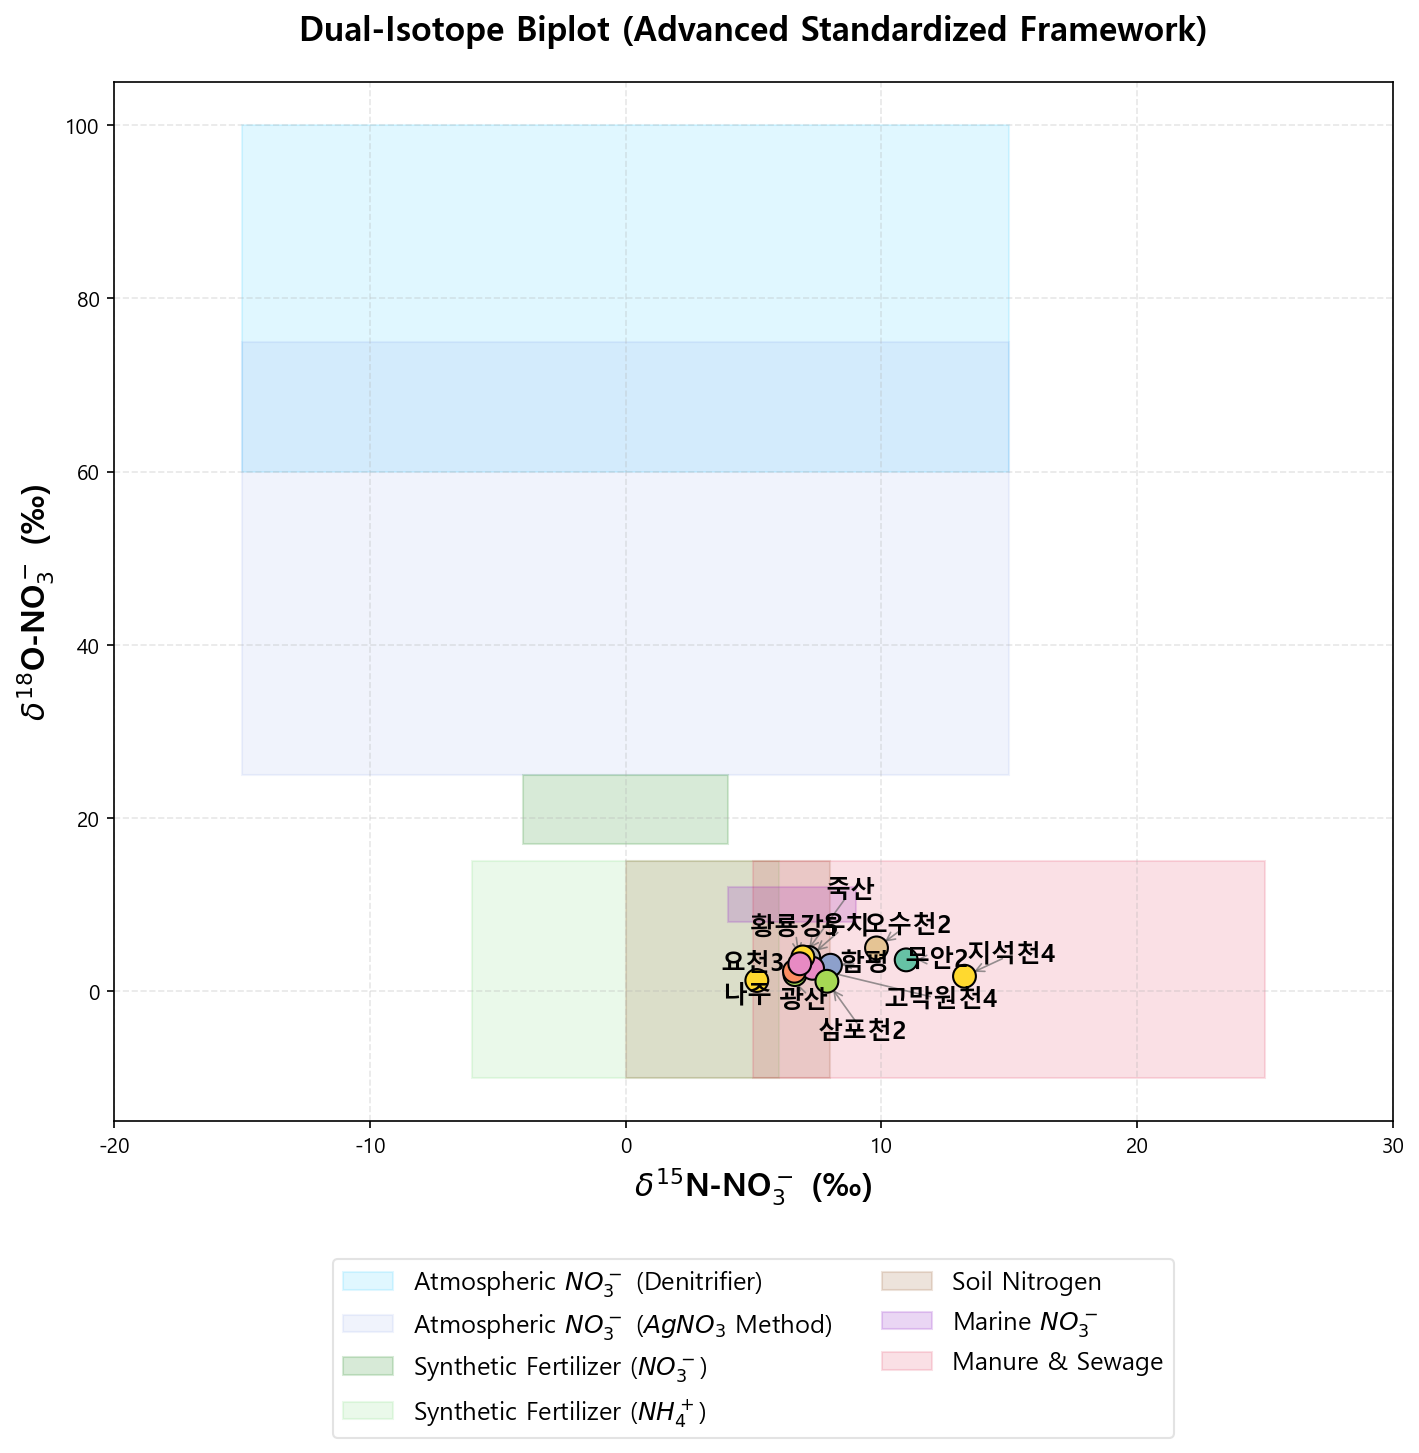

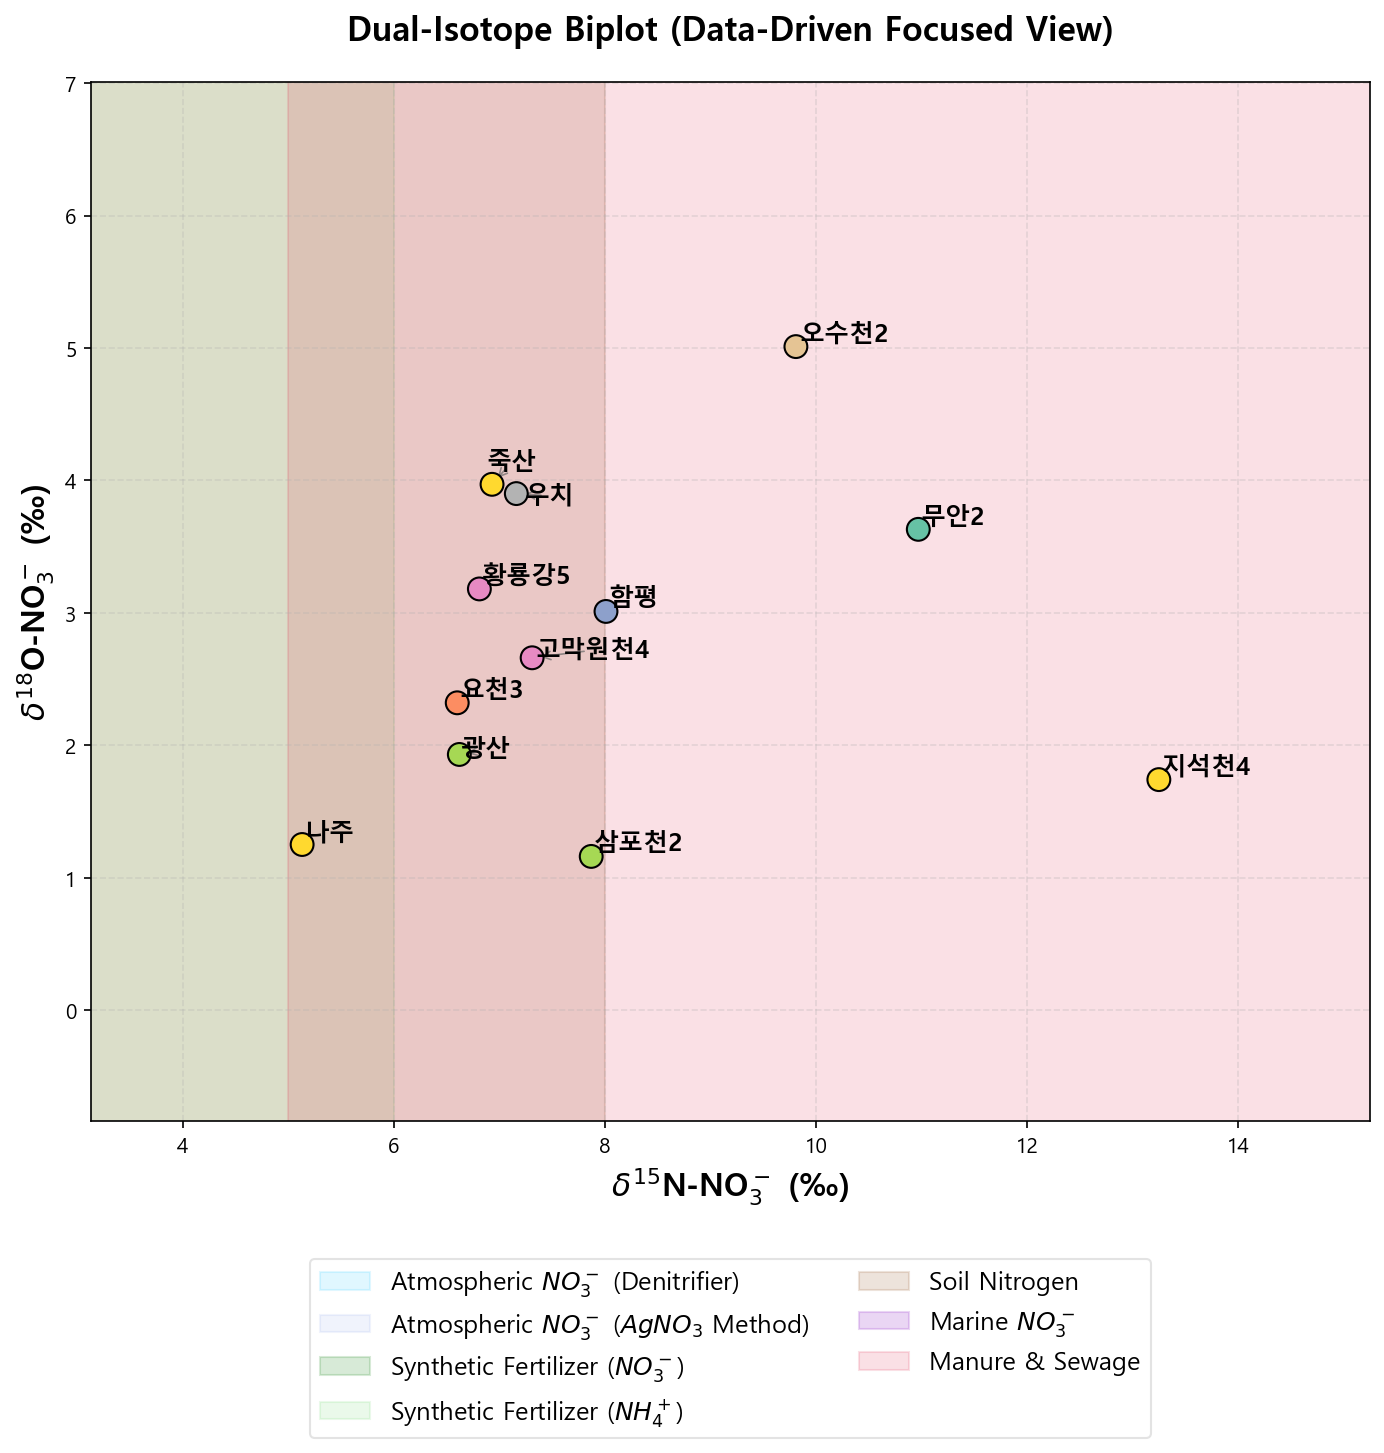

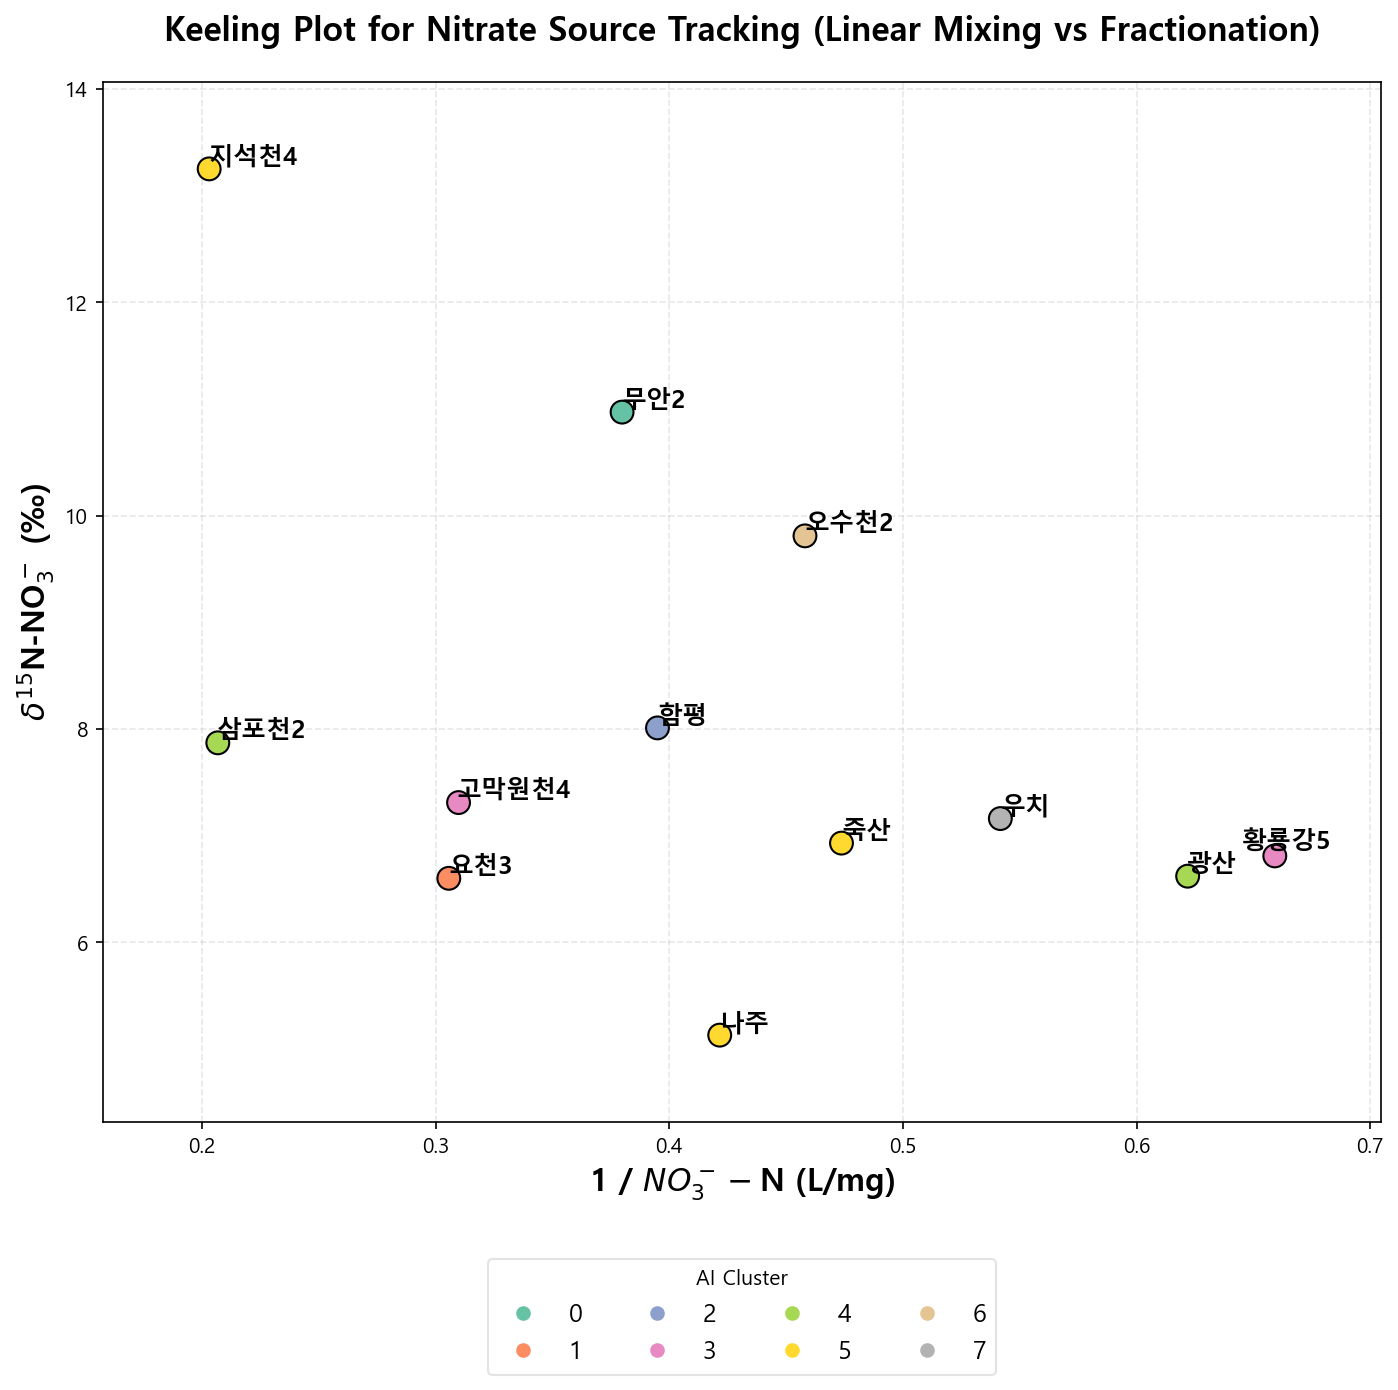

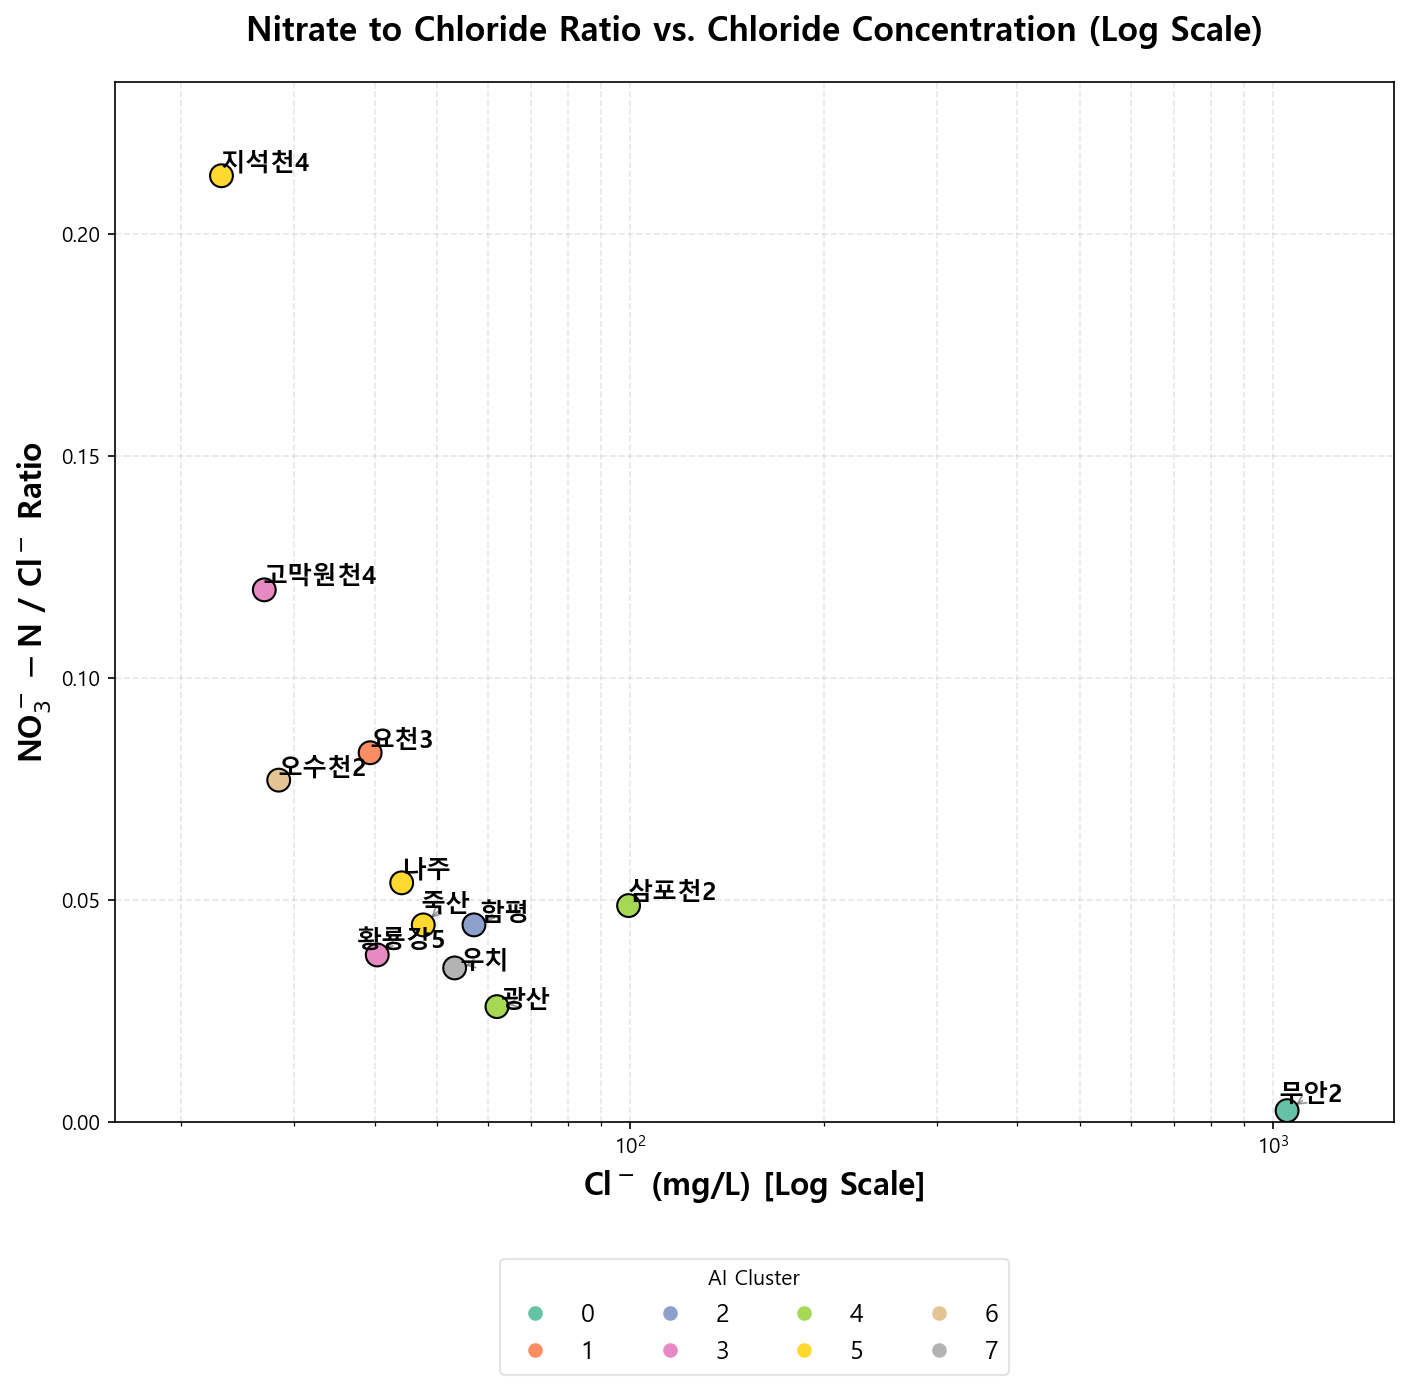

In [19]:
# ------------------------------------------------------------------------------
# 5. 시각화 및 PNG 파일 자동 저장 (XAI)
# 방법론: XAI (Explainable AI) - Decision Tree & Feature Importance (Random Forest)
# 설명: 신경망과 앙상블 군집화는 과정이 투명하지 않은 '블랙박스(Black-box)' 모델입니다. 
#       분석 결과를 연구자와 실무자가 직관적으로 이해할 수 있도록, 의사결정 나무를 통해 
#       어떤 수질 항목의 임계값(Threshold)이 오염원 분류에 결정적이었는지 시각화합니다.
# 참고문헌:
# - Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5-32. (변수 중요도 산출의 근거)
# - Lundberg, S. M., & Lee, S. I. (2017). "A unified approach to interpreting model predictions." Advances in neural information processing systems, 30. (XAI를 통한 모델 해석력 확보)
# ------------------------------------------------------------------------------
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")
print("[*] 4단계: XAI 기반 시각화 및 결과 도출 중...")

# 공통 시각화 함수 정의
def plot_latent_space(target_col, title_suffix, filename):
    plt.figure(figsize=(14, 10))
    unique_vals = df[target_col].dropna().unique()
    colors = sns.color_palette('Set1', len(unique_vals))
    
    for i, val in enumerate(unique_vals):
        mask = df[target_col] == val
        plt.scatter(latent_data[mask, 0], latent_data[mask, 1], 
                    label=val, s=120, color=colors[i], edgecolors='k', alpha=0.8)

    texts = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=12) for i in range(len(df))]
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

    plt.title(f"VAE Latent Space Map: {title_suffix}", fontsize=18, fontweight='bold', pad=15)
    plt.xlabel("Latent Feature 1", fontsize=15)
    plt.ylabel("Latent Feature 2", fontsize=15)
    plt.legend(title="스크리닝 판별 오염원", loc='best', fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{filename}_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()

# 4가지 Case별 반복 처리를 위한 리스트
cases = [
    {'c_col': 'Source_Name1', 'i_col': 'Case1_Source', 'title': 'Case 1 (국내 문헌)', 'fname': 'Case1'},
    {'c_col': 'Source_Name2', 'i_col': 'Case2_Source', 'title': 'Case 2 (국외 문헌)', 'fname': 'Case2'},
    {'c_col': 'Source_Name3', 'i_col': 'Case3_Source', 'title': 'Case 3 (통합 문헌)', 'fname': 'Case3'},
    {'c_col': 'Source_Name',  'i_col': 'Individual_Source', 'title': '최종 (AI 보정)', 'fname': 'Final'}
]

# (1) Decision Tree & (2) Latent Space Map: Case별 반복 시각화
# (1) Decision Tree: 군집별 오염원 결정 논리를 트리 구조로 시각화
# (2) 잠재 공간 지문 지도 (Latent Space Map)
# Autoencoder로 축소한 2차원 또는 3차원 공간(여기서는 앞의 2개 차원 활용)에 투영하여, 
# 오염원 간의 공간적 거리와 분리도를 직관적으로 확인합니다.
# 원본 데이터프레임에서 개별 룰베이스 판별 결과를 가져옵니다.
for case in cases:
    c_name = case['title']
    fname = case['fname']
    c_col = case['c_col']
    i_col = case['i_col']
    
    print(f"\n>>> [{c_name}] 프로세스 시작...")

    # [방어 코드 1] 컬럼 존재 여부 확인
    if c_col not in df.columns or i_col not in df.columns:
        print(f"  [경고] 데이터프레임에 {c_col} 또는 {i_col} 컬럼이 존재하지 않아 건너뜁니다.")
        continue

    try:
        # Decision Tree 생성 및 저장
        dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=2, random_state=SEED)
        
        # 결측/판정보류 데이터 방어를 위해 mask 적용
        valid_mask = (df[c_col] != "결측-판정보류") & (df[c_col].notna())
        
        if valid_mask.sum() > 5:  # 최소한 데이터가 일정 개수 이상 있을 때만 수행
            dt_model.fit(imputed_data[valid_mask], df.loc[valid_mask, c_col]) 
            
            plt.figure(figsize=(20, 10))
            plot_tree(dt_model, feature_names=features_df.columns, 
                      class_names=[str(c) for c in dt_model.classes_],
                      filled=True, rounded=True, fontsize=12)
            plt.title(f"AI 기반 수질 군집 분류 로직 트리 [{c_name}]", fontsize=18, fontweight='bold')
            plt.savefig(os.path.join(out_dir, f"01_Decision_Tree_{fname}_{current_time}.png"), dpi=300, bbox_inches='tight')
            plt.show()
            plt.close() # [메모리 방어] 사용한 그림 객체 닫기
            print(f"  - Decision Tree 시각화 완료")
        else:
            print(f"  [안내] {c_name}의 유효 데이터 수가 부족하여 Decision Tree를 생략합니다. (유효수: {valid_mask.sum()})")
        
        # Latent Space Map 생성 및 저장
        # [방어 코드 2] plot_latent_space 함수 내부에서 에러가 나는 것을 방지하기 위해 try-except 세분화
        try:
            plot_latent_space(c_col, f'군집 대표 오염원 [{c_name}]', f'02_Latent_Space_Cluster_{fname}')
            print(f"  - 군집 대표 오염원 지도 완료")
        except Exception as e:
            print(f"  [오류] 군집 대표 오염원 지도 생성 중 에러 발생 ({fname}): {e}")
            
        try:
            plot_latent_space(i_col, f'개별 지점 정밀 스크리닝 [{c_name}]', f'03_Latent_Space_Individual_{fname}')
            print(f"  - 개별 지점 정밀 스크리닝 지도 완료")
        except Exception as e:
            print(f"  [오류] 개별 지점 정밀 스크리닝 지도 생성 중 에러 발생 ({fname}): {e}")
            
        plt.close('all') # 모든 잔여 Matplotlib 피규어 닫기 (메모리 누수 방지)

    except Exception as main_e:
        # 루프 전체가 터지는 것을 막고 에러 로그를 출력 후 다음 케이스로 이동
        print(f"\n [Fatal Error] {c_name} 처리 중 치명적 오류 발생:")
        traceback.print_exc()
        print(f" {c_name} 프로세스를 건너뛰고 다음 케이스로 진행합니다.\n")
        continue

print("\n=============================================")
print("[*] 모든 케이스에 대한 루프 프로세스가 종료되었습니다.")
print("=============================================")

# (3) Random Forest 변수 중요도 (군집 구조 기반이므로 1번만 구동)
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=SEED).fit(imputed_data, df['Cluster'])
importances = pd.Series(rf.feature_importances_, index=features_df.columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title("오염원 분류 결정 주도 변수 기여도 (CINN-VAE 결합)", fontsize=16)
plt.savefig(os.path.join(out_dir, f"04_Feature_Importance_{current_time}.png"), dpi=300, bbox_inches='tight')
plt.show()

# (4) Dual-Isotope biplot (동위원소 산출값이므로 1번만 구동)
# ==============================================================================
# [최신화 영역] 3대 표준 문헌 기반 오염원 7대 범주 경계 설정
# References:
#   1) Kendall, C., Elliott, E. M., & Wankel, S. D. (2007). Tracing anthropogenic inputs of nitrogen to ecosystems. Stable isotopes in ecology and environmental science, 375-449.
#   2) Xue, D., Botte, J., De Baets, B., Accoe, F., Nestler, A., Taylor, P., ... & Boeckx, P. (2009). Present limitations and future prospects of stable isotope methods for nitrate source identification in surface-and groundwater. Water research, 43(5), 1159-1170.
#   3) International Atomic Energy Commission. (2013). Application of Isotope Techniques for Assessing Nutrient Dynamics in River Basins. IAEA.
#
# Rectangle 인자 구조: (x_min, y_min), width(x_max - x_min), height(y_max - y_min)
# ==============================================================================
# (4-1) 모든 오염원 영역이 드러나도록 그리기
fig, ax = plt.subplots(figsize=(11, 9))  # 범례 공간 확보를 위해 가로/세로 크기 미세 확장

# 1. Atmospheric NO3- (by bacterial denitrification): d15N(-15~15), d18O(60~100)
ax.add_patch(plt.Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', 
                           label='Atmospheric $NO_3^-$ (Denitrifier)'))

# 2. Atmospheric NO3- (by ion exchange / AgNO3): d15N(-15~15), d18O(25~75)
ax.add_patch(plt.Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', 
                           label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)'))

# 3. Synthetic Fertilizer (NO3- Form): d15N(-4~4), d18O(17~25)
ax.add_patch(plt.Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', 
                           label='Synthetic Fertilizer ($NO_3^-$)'))

# 4. Synthetic Fertilizer (NH4+ Form): d15N(-6~6), d18O(-10~15)
ax.add_patch(plt.Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', 
                           label='Synthetic Fertilizer ($NH_4^+$)'))

# 5. Soil Nitrogen (토양 유기태 질소): d15N(0~8), d18O(-10~15)
ax.add_patch(plt.Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', 
                           label='Soil Nitrogen'))

# 6. Marine NO3- (해수 기원 질산염): d15N(4~9), d18O(8~12)
ax.add_patch(plt.Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', 
                           label='Marine $NO_3^-$'))

# 7. Manure & Sewage (축산분뇨 및 생활하수): d15N(5~25), d18O(-10~15)
ax.add_patch(plt.Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', 
                           label='Manure & Sewage'))

# ==============================================================================

# ==============================================================================
# [방어막 보완 영역] 시각화 전용 로컬 데이터프레임 생성 및 결측치 전처리
# 원본 데이터프레임(df)의 구조를 망가뜨리지 않고, 그래프 플로팅에 필요한 핵심 변수인
# 'd15N'과 'd18O'에 결측치(NaN)가 포함된 행만 안전하게 필터링합니다.
# 이를 통해 후속 군집 색상 매핑(Cluster) 및 지점명(spot) 매핑의 인덱스 불일치 오류를 방지합니다.
# ==============================================================================
plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

# 만약 결측치를 제외한 유효 데이터가 존재할 때만 그래프 작성을 수행하도록 제어
if not plot_df.empty:

    # 데이터 플로팅 (원본 df 대신 결측치가 제거된 plot_df 적용)
    scatter = ax.scatter(plot_df['d15N'], plot_df['d18O'], c=plot_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # 지점 라벨링 생성 루틴 수정 (plot_df 기반으로 일치화하여 NaN 좌표에 텍스트가 찍히는 오류 차단)
    texts = [ax.text(plot_df['d15N'].iloc[i], plot_df['d18O'].iloc[i], str(txt), fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(plot_df['spot'])]

    # 라벨 중첩 방지 조절 (유효한 좌표값들만 전달되므로 안정적으로 구동됨)
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=5, shrinkB=5), lim=50)

    # 축 라벨 및 그래프 디자인 고도화
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')

    # [개선] 7대 범주 확장에 따른 범례 가독성 확보 (2열 배열 및 그래프 하단 외부 배치)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=12, 
              frameon=True, shadow=False, ncol=2, facecolor='white', edgecolor='gainsboro')

    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Advanced Standardized Framework)", fontsize=16, fontweight='bold', pad=20)

    # [수정 영역] 7대 범주(Y축 최대 100)가 온전히 표출되도록 경계 최적화
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # 이미지 저장 및 출력 (bbox_inches='tight' 필수: 하단 외부 범례가 잘리지 않도록 함)
    fig.savefig(os.path.join(out_dir, f"05_1_Dual-Isotope_biplot_Standard_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] d15N 또는 d18O의 유효한 데이터가 데이터셋에 존재하지 않아 Dual-Isotope Biplot을 생성하지 못했습니다.")

# (4-2) 동적 축 범위 설정(데이터 자세하게 들여다보기)
fig, ax = plt.subplots(figsize=(11, 9))  # 범례 공간 확보를 위해 가로/세로 크기 미세 확장

# 1. Atmospheric NO3- (by bacterial denitrification): d15N(-15~15), d18O(60~100)
ax.add_patch(plt.Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', 
                           label='Atmospheric $NO_3^-$ (Denitrifier)'))

# 2. Atmospheric NO3- (by ion exchange / AgNO3): d15N(-15~15), d18O(25~75)
ax.add_patch(plt.Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', 
                           label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)'))

# 3. Synthetic Fertilizer (NO3- Form): d15N(-4~4), d18O(17~25)
ax.add_patch(plt.Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', 
                           label='Synthetic Fertilizer ($NO_3^-$)'))

# 4. Synthetic Fertilizer (NH4+ Form): d15N(-6~6), d18O(-10~15)
ax.add_patch(plt.Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', 
                           label='Synthetic Fertilizer ($NH_4^+$)'))

# 5. Soil Nitrogen (토양 유기태 질소): d15N(0~8), d18O(-10~15)
ax.add_patch(plt.Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', 
                           label='Soil Nitrogen'))

# 6. Marine NO3- (해수 기원 질산염): d15N(4~9), d18O(8~12)
ax.add_patch(plt.Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', 
                           label='Marine $NO_3^-$'))

# 7. Manure & Sewage (축산분뇨 및 생활하수): d15N(5~25), d18O(-10~15)
ax.add_patch(plt.Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', 
                           label='Manure & Sewage'))

# ==============================================================================

# ==============================================================================
# [방어막 보완 영역] 시각화 전용 로컬 데이터프레임 생성 및 결측치 전처리
# 원본 데이터프레임(df)의 구조를 망가뜨리지 않고, 그래프 플로팅에 필요한 핵심 변수인
# 'd15N'과 'd18O'에 결측치(NaN)가 포함된 행만 안전하게 필터링합니다.
# 이를 통해 후속 군집 색상 매핑(Cluster) 및 지점명(spot) 매핑의 인덱스 불일치 오류를 방지합니다.
# ==============================================================================
plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

# 만약 결측치를 제외한 유효 데이터가 존재할 때만 그래프 작성을 수행하도록 제어
if not plot_df.empty:

    # ==========================================================================
    # [핵심 고도화] 조사 지점 실제 데이터 맞춤형 동적 마진(Padding) 연산
    x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
    y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()

    # 데이터 분포 폭의 15% 만큼 여백(Buffer) 산정 (단일 지점일 경우를 대비해 최소 여백 2.0 보장)
    x_buffer = max((x_max - x_min) * 0.15, 2.0) if x_max != x_min else 3.0
    y_buffer = max((y_max - y_min) * 0.15, 2.0) if y_max != y_min else 3.0

    # 최종 동적 축 범위 지정
    ax.set_xlim(x_min - x_buffer, x_max + x_buffer)
    ax.set_ylim(y_min - y_buffer, y_max + y_buffer)
    # ==========================================================================

    # 데이터 플로팅 (원본 df 대신 결측치가 제거된 plot_df 적용)
    scatter = ax.scatter(plot_df['d15N'], plot_df['d18O'], c=plot_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # 지점 라벨링 생성 루틴 수정 (plot_df 기반으로 일치화하여 NaN 좌표에 텍스트가 찍히는 오류 차단)
    texts = [ax.text(plot_df['d15N'].iloc[i], plot_df['d18O'].iloc[i], str(txt), 
                     fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(plot_df['spot'])]

    # 라벨 중첩 방지 조절 (화살표 길이를 짧고 정밀하게 제어하기 위한 매개변수 튜닝)
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=4, shrinkB=4), 
                lim=40)

    # 축 라벨 및 그래프 디자인 고도화
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')

    # [개선] 7대 범주 확장에 따른 범례 가독성 확보 (2열 배열 및 그래프 하단 외부 배치)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=12, 
              frameon=True, shadow=False, ncol=2, facecolor='white', edgecolor='gainsboro')

    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Data-Driven Focused View)", fontsize=16, fontweight='bold', pad=20)

    # 이미지 저장 및 출력 (bbox_inches='tight' 필수: 하단 외부 범례가 잘리지 않도록 함)
    fig.savefig(os.path.join(out_dir, f"05_2_Dual-Isotope_biplot_Dynamic_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] d15N 또는 d18O의 유효한 데이터가 데이터셋에 존재하지 않아 Dual-Isotope Biplot을 생성하지 못했습니다.")    

# (5) Keeling plot: d15N (y축) vs 1/NO3N (x축) (오염원 혼합 및 정량적 거동 해석)
fig, ax = plt.subplots(figsize=(11, 9))  # 기존 프레임워크의 범례 및 시각적 일관성을 위해 동일 크기 유지

# ==============================================================================
# [학술적 배경 및 오염원 해석 원리 - 주석 상세 기술]
# 본 산점도는 지화학(Geochemistry) 분야에서 전통적으로 널리 쓰이는 'Keeling Plot' 분석법입니다.
# 수계 내 질산성질소(NO3-N)의 농도 변화와 질소 안정동위원소비(d15N)의 관계를 선형화하여 
# 다음과 같은 두 가지 핵심 환경 프로세스를 정량적으로 판별할 수 있습니다.
#
# 1) 이성분 혼합 모형 (Binary Mixing Processes):
#    만약 데이터 포인트들이 이 그래프 상에서 직선(Linear Trend)을 그리며 정렬된다면, 
#    이는 수계 내에서 기원이 다른 '두 개의 독립된 오염원'이 단순히 물리적으로 혼합(Dilution 또는 Mixing)
#    되고 있음을 의미합니다. 이때 회귀직선의 y절편(1/NO3N -> 0, 즉 농도가 무한대인 시점) 값은 
#    외부에서 유입된 주 오염원(End-member)의 고유한 d15N 동위원소 초깃값을 나타냅니다.
#
# 2) 생물학적 탈질 작용 (Denitrification):
#    만약 데이터가 직선을 따르지 않고, NO3N 농도가 감소함에 따라(즉, 1/NO3N 값이 커짐에 따라) 
#    d15N 값이 지수함수적으로 상승하는 형태를 보인다면, 이는 단순 혼합이 아니라 
#    미생물에 의한 '탈질 작용(Denitrification)'이 강하게 일어나 동위원소 분별 효과(Fractionation)가 
#    발생했음을 지화학적으로 증명합니다.
#
# [검증 완료] References (Google Scholar 검색 최적화 표준 서지 정보):
#   1) Keeling, C. D. (1958). The concentration and isotopic abundances of atmospheric carbon dioxide in rural areas. Geochimica et cosmochimica acta, 13(4), 322-334.
#   2) Kendall, C. (1998). Tracing nitrogen sources and cycling in catchments. In Isotope tracers in catchment hydrology (pp. 519-576). Elsevier.
#   3) Xue, D., Botte, J., De Baets, B., Accoe, F., Nestler, A., Taylor, P., ... & Boeckx, P. (2009). Present limitations and future prospects of stable isotope methods for nitrate source identification in surface-and groundwater. Water research, 43(5), 1159-1170.
# ==============================================================================

# ==============================================================================
# [방어막 영역] 결측치 데이터 및 분모 0 (ZeroDivisionError) 발생 행 제거
# 원본 df의 무결성을 지키기 위해 .copy()를 사용하며, x축의 분모가 되는 NO3N이 
# 결측치이거나 정밀도가 낮아 0(또는 음수)으로 측정된 행을 완벽히 필터링합니다.
# ==============================================================================
keeling_df = df.dropna(subset=['d15N', 'NO3N']).copy()
keeling_df = keeling_df[keeling_df['NO3N'] > 0]  # 분모가 0이 되는 원천적 오류 방지

if not keeling_df.empty:
    # 1/NO3N 역수(Inverse) 컬럼 생성
    keeling_df['1/NO3N'] = 1.0 / keeling_df['NO3N']

    # 데이터 플로팅 (기존 프레임워크의 군집 색상, 크기, 테두리 스타일 일치화)
    scatter = ax.scatter(keeling_df['1/NO3N'], keeling_df['d15N'], 
                         c=keeling_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # 지점 라벨링 생성 루틴 (결측치가 제거된 keeling_df 인덱스에 맞추어 1:1 매핑)
    texts = [ax.text(keeling_df['1/NO3N'].iloc[i], keeling_df['d15N'].iloc[i], str(txt), 
                     fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(keeling_df['spot'])]

    # 라벨 중첩 방지 조절 (adjust_text 라이브러리 연계 유지)
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=5, shrinkB=5), lim=50)

    # 축 라벨 및 그래프 디자인 고도화 (수학적 표현식 적용)
    ax.set_xlabel(r'1 / $NO_3^--$N (L/mg)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')

    # 군집(Cluster) 구분을 위한 범례 표시 (기존 프레임워크 디자인과 톤앤매너 매치)
    legend_elements = ax.legend(*scatter.legend_elements(), loc='upper center', bbox_to_anchor=(0.5, -0.12), 
                                fontsize=12, frameon=True, shadow=False, ncol=4, facecolor='white', edgecolor='gainsboro', title="AI Cluster")

    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Keeling Plot for Nitrate Source Tracking (Linear Mixing vs Fractionation)", fontsize=16, fontweight='bold', pad=20)

    # 역수 플롯의 특성상 데이터의 가독성을 높이기 위해 여백을 고려한 동적 축 범위 설정
    x_margin = (keeling_df['1/NO3N'].max() - keeling_df['1/NO3N'].min()) * 0.1 if len(keeling_df) > 1 else 0.5
    y_margin = (keeling_df['d15N'].max() - keeling_df['d15N'].min()) * 0.1 if len(keeling_df) > 1 else 2.0
    
    ax.set_xlim(max(0, keeling_df['1/NO3N'].min() - x_margin), keeling_df['1/NO3N'].max() + x_margin)
    ax.set_ylim(keeling_df['d15N'].min() - y_margin, keeling_df['d15N'].max() + y_margin)

    # 이미지 저장 및 출력 (기존 파일명 형식 및 bbox_inches 규칙 준수)
    fig.savefig(os.path.join(out_dir, f"06_Keeling_plot_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] d15N 또는 NO3N의 유효 관측치(>0)가 부족하여 Keeling Plot을 생성하지 못했습니다.")  

# (6) Chemical Tracer Plot: NO3N/Cl (y축) vs log(Cl) (x축) (보존성 추적자 기반 오염원 거동 해석 - 로그스케일 고도화 버전)
fig, ax = plt.subplots(figsize=(11, 9))  # 프레임워크의 시각적 일관성 및 범례 가독성을 위해 동일 크기 유지

# ==============================================================================
# [학술적 배경 및 오염원 해석 원리 - 주석 상세 기술]
# 본 산점도는 동위원소 분석 결과와 수질 화학 인자를 연계하여 오염원의 기원과 수동적/능동적 거동을 
# 판별하는 데 가장 신뢰성 높은 '화학적 추적자 비(Tracer Ratio)' 분석 기법입니다.
# 
# 1) 보존성 추적자(Conservative Tracer)로서의 염소이온(Cl-):
#    Cl-은 수계 내에서 미생물 흡수, 휘발, 침전 등의 생물화학적 반응에 의해 거의 소모되지 않고, 
#    오직 물의 흐름에 따른 '물리적 희석 및 혼합(Dilution & Mixing)'에 의해서만 농도가 변화합니다.
# 
# 2) 오염원별 End-member 판별 원리:
#    - 축산분뇨 및 생활하수 기원 (Manure & Sewage): 고농도의 질소와 함께 식생활/사료 기원의 고농도 Cl-이 
#      동시 유입되므로, x축(Cl-)과 y축(NO3N/Cl)이 모두 높은 영역 또는 독자적인 선형 궤적을 형성합니다.
#    - 화학비료 기원 (Synthetic Fertilizer): 농경지 질소 비료는 Cl- 함량이 상대적으로 매우 낮기 때문에, 
#      x축(Cl-) 농도는 낮고 y축(NO3N/Cl) 비율은 극단적으로 높은 좌상단 영역에 플로팅됩니다.
#    - 배경 지하수/자연수 (Background Water): Cl-과 NO3-N 농도가 모두 낮아 좌하단 영역에 위치합니다.
# 
# 3) 생물학적 탈질 작용(Denitrification)의 진단:
#    특정 지점에서 시간이 지남에 따라 Cl- 농도(x축)는 일정한 수준을 유지하는데, NO3N/Cl 비율(y축)만 
#    수직으로 급격히 감소하는 경향(Vertical Downward Trend)을 보인다면, 이는 오염원의 변경이 아니라 
#    수계 내에서 질산염이 '탈질 작용'에 의해 생물학적으로 소모(자연 정화)되었음을 완벽하게 입증합니다.
#
# [* 핵심 피칭 포인트: 왜 로그 스케일(Log Scale)인가?]
# 1) 데이터 압축(Compression) 해소 및 저농도 구간 해상도 극대화:
#    본 유역 내 '무안2' 지점과 같이 해수 침투 또는 특이 폐수의 영향으로 Cl- 농도가 극단적으로 높은
#    이상치(Outlier, >1,000 mg/L)가 존재할 경우, 선형 축에서는 하수와 분뇨가 분리되어야 할 
#    핵심 저농도 구간(0 ~ 150 mg/L)이 좌측 벽면에 압축되어 식별이 불가능해집니다.
#    X축을 로그 스케일로 변환함으로써, 고농도 이상치를 한 화면에 표출하면서도 저농도 구간을 기하학적으로
#    확장(Decompression)하여 미세한 거동 차이를 명확하게 시각화할 수 있습니다.
# 
# 2) 보존성 추적자(Cl-) 기반 하수(Sewage)와 분뇨(Manure)의 타당한 경계선 분리 원리:
#    - 가축 분뇨(Manure): 암모니아성 질소의 극단적 유입 후 질산화가 진행되므로, Cl- 농도는 상대적으로 
#      낮은 대역(10 ~ 40 mg/L)에 머물면서 NO3N/Cl 비율이 0.12 이상으로 급격히 수직 상승하는 거동을 보입니다.
#    - 생활 하수(Sewage): 인간 활동으로 인해 Cl-과 질산염이 동시에 일정 비율로 유입되므로, Cl- 농도가 
#      중-고농도 대역(40 ~ 150 mg/L)을 형성하며 NO3N/Cl 비율이 0.03 ~ 0.08 박스권 내에 수렴하는 경향을 보입니다.
#
# 3) 생물학적 탈질 작용(Denitrification)의 진단:
#    특정 지점에서 시간이 지남에 따라 Cl- 농도(x축)는 일정한 수준을 유지하는데, NO3N/Cl 비율(y축)만 
#    수직으로 급격히 감소하는 경향(Vertical Downward Trend)을 보인다면, 이는 오염원의 변경이 아니라 
#    수계 내에서 질산염이 '탈질 작용'에 의해 생물학적으로 소모(자연 정화)되었음을 완벽하게 입증합니다.
#
# [검증 완료] References (Google Scholar 검색 최적화 표준 서지 정보):
#   1) Panno, S. V., Kelly, W. R., Martinsek, A. T., & Hackley, K. C. (2006). Estimating background and threshold nitrate concentrations using probability graphs. Groundwater, 44(5), 697-709.
#   2) Widory, D., Petelet-Giraud, E., Négrel, P., & Ladouche, B. (2005). Tracking the sources of nitrate in groundwater using coupled nitrogen and boron isotopes: a synthesis. Environmental Science & Technology, 39(2), 539-548.
#   3) Liu, C. Q., Li, S. L., Lang, Y. C., & Xiao, H. Y. (2006). Using δ15N-and δ18O-values to identify nitrate sources in karst ground water, Guiyang, Southwest China. Environmental Science & Technology, 40(22), 6928-6933.
# ==============================================================================

# ==============================================================================
# [방어막 영역] 결측치 데이터 및 분모 0 (ZeroDivisionError) 발생 행 원천 제거
# 원본 데이터프레임(df)을 보존하기 위해 .copy()를 적용하며, x축 변수이자 y축의 분모가 되는
# 'Cl' 항목이 결측치이거나 기기 분석 한계치 이하인 0(또는 음수)인 행을 완벽히 도려냅니다.
# (※ 로그 스케일 변환을 위해서도 Cl > 0 조건은 수학적으로 필수적인 방어막입니다.)
# ==============================================================================
ratio_df = df.dropna(subset=['NO3N', 'Cl']).copy()
ratio_df = ratio_df[ratio_df['Cl'] > 0]  # 분모 0 방지 및 로그 변환 에러(log(0)) 방지

if not ratio_df.empty:
    # y축에 매핑할 NO3N / Cl 비율 변수 생성
    ratio_df['NO3N/Cl'] = ratio_df['NO3N'] / ratio_df['Cl']

    # 데이터 플로팅 (기존 프레임워크의 군집별 색상, 크기, 마커 스타일과 100% 일치화)
    scatter = ax.scatter(ratio_df['Cl'], ratio_df['NO3N/Cl'], 
                         c=ratio_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # [수정 사항 1] X축을 로그 스케일(Logarithmic Scale)로 지정
    # 데이터 값을 강제로 log10 변환하여 플로팅하는 대신, matplotlib 공식 기능인 set_xscale('log')를 사용하여
    # 실제 물리적 농도 값(mg/L)을 틱 라벨에 유지하면서 기하학적 거리만 로그 배율로 조정합니다.
    ax.set_xscale('log')
    
    # 지점 라벨링 생성 루틴 (결측치가 제거된 ratio_df 인덱스와 1:1 대응하여 NaN 좌표 생성 에러 차단)
    texts = [ax.text(ratio_df['Cl'].iloc[i], ratio_df['NO3N/Cl'].iloc[i], str(txt), 
                     fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(ratio_df['spot'])]

    # 라벨 중첩 방지 조절 (adjust_text 엔진 연계 유지)
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=5, shrinkB=5), lim=50)

    # [수정 사항 2] 축 라벨 명칭에 로그 스케일 정보 반영 (하첨자 및 이온 기호 표준화)
    ax.set_xlabel(r'Cl$^-$ (mg/L) [Log Scale]', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'NO$_3^--$N / Cl$^-$ Ratio', fontsize=15, fontweight='semibold')

    # 군집(Cluster) 구분을 위한 하단 범례 구성 (기존 프레임워크 디자인 톤앤매너 계승)
    legend_elements = ax.legend(*scatter.legend_elements(), loc='upper center', bbox_to_anchor=(0.5, -0.12), 
                                fontsize=12, frameon=True, shadow=False, ncol=4, facecolor='white', edgecolor='gainsboro', title="AI Cluster")

    # [수정 사항 3] 로그 스케일에 최적화된 주격자/보조격자(Minor Grid) 표출 설정
    # 로그 축에서는 주격자(10, 100, 1000)뿐만 아니라 그 사이의 보조격자가 보여야 데이터의 왜곡 없는 가독성이 확보됩니다.
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.set_title("Nitrate to Chloride Ratio vs. Chloride Concentration (Log Scale)", fontsize=16, fontweight='bold', pad=20)

    # [수정 사항 4] 로그 스케일에 대응하는 동적 축 여백(Margin) 계산 수식 적용
    # 선형 스케일 기준의 (max - min) * 0.1 마진 수식은 로그 축에서 플롯을 왜곡시키거나 에러를 유발합니다.
    # 따라서, 로그 공간(Log Space) 상에서 최적의 10% 마진을 계산한 뒤, 다시 지수화(10^x)하여 축 범위를 지정합니다.
    log_cl = np.log10(ratio_df['Cl'])
    log_x_min, log_x_max = log_cl.min(), log_cl.max()
    log_x_margin = (log_x_max - log_x_min) * 0.1 if log_x_max > log_x_min else 0.5
    
    # Y축(선형 스케일) 마진 계산은 기존 프레임워크 수식을 그대로 유지
    y_margin = (ratio_df['NO3N/Cl'].max() - ratio_df['NO3N/Cl'].min()) * 0.1 if len(ratio_df) > 1 else 0.5
    
    # 최종 안전 축 범위 대입 (X축은 로그 스케일 하한선 방어, Y축은 0 이하로 떨어지지 않도록 방어)
    ax.set_xlim(10**(log_x_min - log_x_margin), 10**(log_x_max + log_x_margin))
    ax.set_ylim(max(0, ratio_df['NO3N/Cl'].min() - y_margin), ratio_df['NO3N/Cl'].max() + y_margin)

    # 이미지 저장 및 출력 (기존 파일명 명명 규칙 및 일관성 유지, 파일명에 log 명시하여 식별성 강화)
    fig.savefig(os.path.join(out_dir, f"07_NO3N_Cl_ratio_log_plot_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] NO3N 또는 Cl의 유효 관측치(>0)가 부족하여 NO3N/Cl vs Cl 산점도를 생성하지 못했습니다.")    

In [20]:
# ------------------------------------------------------------------------------
# 6. 최종 분석 결과 출력 및 CSV 내보내기
# ------------------------------------------------------------------------------
print("\n=========================================================")
print(" [오염원 자동 스크리닝 최종 레포트 - 고도화 버전]")
print("=========================================================")
# [수정됨] 최종 CSV 출력물에 Source_Name1, 2, 3 및 개별 판별 결과 모두 포함
report_cols = ['spot', 'Source_Name', 'Source_Name1', 'Source_Name2', 'Source_Name3', 
               'Individual_Source', 'Case1_Source', 'Case2_Source', 'Case3_Source', 
               'd15N', 'd18O', 'TN', 'NH3N', 'NO3N', 'TP', 'TOC', 'EC', 'Chla', 'Cl']
               
final_report = df[report_cols].sort_values('Source_Name')

print(final_report.to_string(index=False))

csv_path = os.path.join(out_dir, f"00_Screening_Result_{current_time}.csv")
final_report.to_csv(csv_path, index=False, encoding='euc-kr')

print(f"\n[*] 시스템 프로세스 완료. 모든 산출물(CSV 및 PNG)이 '{out_dir}' 폴더에 정상 저장되었습니다.")


 [오염원 자동 스크리닝 최종 레포트 - 고도화 버전]
 spot  Source_Name   Source_Name1      Source_Name2 Source_Name3 Individual_Source   Case1_Source      Case2_Source Case3_Source  d15N  d18O    TN  NH3N  NO3N    TP  TOC   EC  Chla       Cl
   우치  생활하수/처리수 영향    생활하수/처리수 영향        탈질작용(기원변형)  생활하수/처리수 영향       생활하수/처리수 영향    생활하수/처리수 영향        탈질작용(기원변형)  생활하수/처리수 영향  7.16  3.90 2.773 0.150 1.846 0.089  5.7  354  39.4   53.288
   광산  생활하수/처리수 영향    생활하수/처리수 영향        산업/인위적 점오염  생활하수/처리수 영향        조류증식(현장발생)     조류증식(현장발생)        조류증식(현장발생)   조류증식(현장발생)  6.62  1.93 7.712 4.997 1.608 0.251  9.7  417  93.7   62.006
   함평  생활하수/처리수 영향    생활하수/처리수 영향       생활하수/처리수 영향  생활하수/처리수 영향       생활하수/처리수 영향    생활하수/처리수 영향       생활하수/처리수 영향  생활하수/처리수 영향  8.01  3.01 7.358 4.507 2.532 0.173  7.9  396  12.9   57.103
  무안2  생활하수/처리수 영향    생활하수/처리수 영향        산업/인위적 점오염  생활하수/처리수 영향       생활하수/처리수 영향    생활하수/처리수 영향        산업/인위적 점오염  생활하수/처리수 영향 10.97  3.63 3.715 0.788 2.633 0.045  5.2 4180  19.8 1050.809
고막원천4  생활하수/처리수 영향